<h1 style="text-align: center;">Data Exploratory Analysis and Processing<h1>

In [1]:
import warnings
warnings.simplefilter("ignore")

import pandas as pd
import re
import numpy as np
from collections import Counter

import geohash_hilbert as ghh
import geopandas as gpd
from shapely.geometry import Point
from shapely import wkt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import plotly.graph_objects as go
from IPython.display import Image, display
import plotly.express as px
import plotly.io as pio
from scipy.stats import chi2_contingency
import math
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


# pd.reset_option('display.max_columns')
# pd.reset_option('display.width')
# pd.reset_option('display.max_colwidth')

## Loading Data

In [ ]:
DATASET_DIR = 'datasets'

df_crashes_org = pd.read_csv(f'{DATASET_DIR}/traffic-crashes.csv')
df_people_org = pd.read_csv(f'{DATASET_DIR}/traffic-crashes-people.csv')
df_vehicles_org = pd.read_csv(f'{DATASET_DIR}/traffic-crashes-vehicles.csv')
df_CBD_org = pd.read_csv(f'{DATASET_DIR}/chicago-CBD-boundary.csv')
df_police_org = pd.read_csv(f'{DATASET_DIR}/chicago-police-beat-boundries.csv')
df_street_org = pd.read_csv(f'{DATASET_DIR}/chicago-street-center-lines.csv')

In [3]:
df_crashes = df_crashes_org.copy()
df_people = df_people_org.copy()
df_vehicles = df_vehicles_org.copy()
df_street = df_street_org.copy()
df_CBD = df_CBD_org.copy()
df_police = df_police_org.copy()

# Question [1]: Data Cleaning & Integration


## [a] Fill Gaps

In [4]:
def calc_null(df):
    
    missing_counts = df.isnull().sum()
    missing_ratio = df.isnull().mean()

    missing_data = pd.DataFrame({
        'num_missing': missing_counts,
        'missing_ratio': missing_ratio
    })

    print(missing_data.to_string())

### [1]

## Traffic Crashes

In [5]:
df_crashes.shape

(823957, 47)

In [6]:
calc_null(df_crashes)

                               num_missing  missing_ratio
CRASH_RECORD_ID                          0       0.000000
CRASH_DATE_EST_I                    762398       0.925289
CRASH_DATE                               0       0.000000
POSTED_SPEED_LIMIT                       0       0.000000
TRAFFIC_CONTROL_DEVICE                   0       0.000000
DEVICE_CONDITION                         0       0.000000
WEATHER_CONDITION                        0       0.000000
LIGHTING_CONDITION                       0       0.000000
FIRST_CRASH_TYPE                         0       0.000000
TRAFFICWAY_TYPE                          0       0.000000
LANE_CNT                            624947       0.758470
ALIGNMENT                                0       0.000000
ROADWAY_SURFACE_COND                     0       0.000000
ROAD_DEFECT                              0       0.000000
REPORT_TYPE                          24578       0.029829
CRASH_TYPE                               0       0.000000
INTERSECTION_R

<div style="direction: rtl; text-align: right;">
<span style="font-size: 24px;">الأعمدة التي سنقوم بحذفها:</span><br>
- <b>ROADWAY_SURFACE_COND</b> لان قيمه تشبه قيم عمود الطقس وغالباً الطقس هو مايحدد حالة الشارع ورأينا أن الطقس أعم في التحديد <br>
- <b>SEC_CONTRIBUTORY_CAUSE</b> ولكنه سيفيدينا في تعبئة القيم الفارغة في عمود PRIM_CONTRIBUTORY_CAUSE <br>
- <b>REPORT_TYPE, INJURIES_UNKNOWN</b> لم نجد لهم فائدة<br>
- <b>DATE_POLICE_NOTIFIED</b>  أهملنا تاريخ إخبار الشرطة الذي كان من الممكن أن يدلنا على تواجد دوريات الشرطة وأدائها لعملها ولكن وجدنا أن عمود رقم الدورية موثوق أكثر <br>
- <b>STREET_DIRECTION</b> يمكن الاستفادة منه في جدول الشوارع <br>
- الاعمدة <b>INJURIES_FATAL, INJURIES_INCAPACITATING, INJURIES_NON_INCAPACITATING, INJURIES_REPORTED_NOT_EVIDENT, INJURIES_NO_INDICATION نستفيد منها في تعبئة عمود MOST_SEVERE_INJURY</b> <br>
- <b>LOCATION</b> لوجود عمودي LATITUDE و LONGITUDE اللذان يعبران عنه والتعامل معهما أسهل ويقلل من عمليات المعالجة <br>
- أعمدة التي تحوي الكثير من القيم الفارغة:<br> 
<b>CRASH_DATE_EST_I, LANE_CNT<br>
INTERSECTION_RELATED_I, <br>
NOT_RIGHT_OF_WAY_I, HIT_AND_RUN_I,<br> 
PHOTOS_TAKEN_I, STATEMENTS_TAKEN_I,<br> 
DOORING_I, WORK_ZONE_I,<br>
WORK_ZONE_TYPE, WORKERS_PRESENT_I<br>

In [7]:
df_crashes = df_crashes[['CRASH_RECORD_ID', 'CRASH_DATE','LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 
                         'CRASH_TYPE', 'DAMAGE', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'CRASH_HOUR',
                        'LATITUDE', 'LONGITUDE','STREET_NO','STREET_DIRECTION','STREET_NAME', 'BEAT_OF_OCCURRENCE',
                          'POSTED_SPEED_LIMIT','TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION',
                       'ALIGNMENT', 'ROAD_DEFECT', 'MOST_SEVERE_INJURY','INJURIES_TOTAL', 'HIT_AND_RUN_I', 'NOT_RIGHT_OF_WAY_I', 'DOORING_I']]

In [8]:
# delete later
# DOORING_I, NOT_RIGHT_OF_WAY_I, HIT_AND_RUN_I, STREET_DIRECTION, SEC_CONTRIBUTORY_CAUSE

## Traffic Crashes Vehicles

In [9]:
df_vehicles.shape

(1680892, 70)

In [10]:
calc_null(df_vehicles)

                          num_missing  missing_ratio
CRASH_UNIT_ID                       0       0.000000
CRASH_RECORD_ID                     0       0.000000
CRASH_DATE                          0       0.000000
UNIT_NO                             0       0.000000
UNIT_TYPE                        2150       0.001279
VEHICLE_ID                      38473       0.022888
CMRC_VEH_I                    1649615       0.981393
MAKE                            38478       0.022891
MODEL                           38623       0.022978
LIC_PLATE_STATE                188917       0.112391
VEHICLE_YEAR                   301958       0.179642
VEHICLE_DEFECT                  38473       0.022888
VEHICLE_TYPE                    38473       0.022888
VEHICLE_USE                     38473       0.022888
TRAVEL_DIRECTION                38473       0.022888
MANEUVER                        38473       0.022888
TOWED_I                       1472365       0.875943
FIRE_I                        1679517       0.

<div style="direction: rtl; text-align: right;">
<span style="font-size: 24px;">الاعمدة التي سنقوم بحذفها:</span><br>
- <b>CRASH_UNIT_ID, UNIT_NO, LIC_PLATE_STATE, VEHICLE_USE, MANEUVER, FIRST_CONTACT_POINT</b> لم نجد لهم فائدة<br>
- أعمدة التي تحوي الكثير من القيم الفارغة:<br>
<b>CMRC_VEH_I, TOWED_I, FIRE_I, TOWED_BY, TOWED_TO,<br>
AREA_00_I, AREA_01_I, AREA_02_I, AREA_03_I, AREA_04_I,<br>
AREA_05_I, AREA_06_I, AREA_07_I, 'AREA_08_I, AREA_09_I,<br>
AREA_10_I, AREA_11_I, AREA_12_I, 'AREA_99_I, CMV_ID, USDOT_NO, CCMC_NO, ILCC_NO,<br>
COMMERCIAL_SRC, GVWR, CARRIER_NAME, CARRIER_STATE,<br>
CARRIER_CITY, HAZMAT_PLACARDS_I, HAZMAT_NAME, UN_NO,<br>
HAZMAT_PRESENT_I, HAZMAT_REPORT_I, HAZMAT_REPORT_NO,<br>
MCS_REPORT_I, MCS_REPORT_NO, HAZMAT_VIO_CAUSE_CRASH_I,<br>
MCS_VIO_CAUSE_CRASH_I, IDOT_PERMIT_NO, WIDE_LOAD_I,<br>
TRAILER1_WIDTH, TRAILER2_WIDTH, TRAILER1_LENGTH,<br>
TRAILER2_LENGTH, TOTAL_VEHICLE_LENGTH, AXLE_CNT, VEHICLE_CONFIG,<br>
CARGO_BODY_TYPE, LOAD_TYPE, HAZMAT_OUT_OF_SERVICE_I,<br>
MCS_OUT_OF_SERVICE_I', 'HAZMAT_CLASS'</b>

In [11]:
df_vehicles = df_vehicles[['CRASH_RECORD_ID', 'CRASH_DATE', 'UNIT_TYPE', 'VEHICLE_ID', 'VEHICLE_YEAR',
                           'MAKE', 'MODEL', 'VEHICLE_DEFECT', 'VEHICLE_TYPE','TRAVEL_DIRECTION', 'OCCUPANT_CNT']]

## Trrafic Crashes People

In [12]:
df_people.shape

(1808605, 29)

In [13]:
calc_null(df_people)

                       num_missing  missing_ratio
PERSON_ID                        0       0.000000
PERSON_TYPE                      0       0.000000
CRASH_RECORD_ID                  0       0.000000
VEHICLE_ID                   36177       0.020003
CRASH_DATE                       0       0.000000
SEAT_NO                    1443028       0.797868
CITY                        492062       0.272067
STATE                       472632       0.261324
ZIPCODE                     600317       0.331923
SEX                          29978       0.016575
AGE                         527939       0.291904
DRIVERS_LICENSE_STATE       748686       0.413958
DRIVERS_LICENSE_CLASS       922585       0.510109
SAFETY_EQUIPMENT              5061       0.002798
AIRBAG_DEPLOYED              34799       0.019241
EJECTION                     22453       0.012415
INJURY_CLASSIFICATION          729       0.000403
HOSPITAL                   1509447       0.834592
EMS_AGENCY                 1623522       0.897665


<div style="direction: rtl; text-align: right;">
<span style="font-size: 24px;">الأعمدة التي سنقوم بحذفها:</span><br>
- أعمدة تحوي الكثير من القيم الفارغة:<br>
<b>SEAT_NO, SAFETY_EQUIPMENT, EMS_AGENCY, EMS_RUN_NO, PEDPEDAL_ACTION, PEDPEDAL_VISIBILITY, 
PEDPEDAL_LOCATION, BAC_RESULT VALUE , CELL_PHONE_USE, DRIVER_VISION</b>  <br>
- <b>CITY, STATE, ZIPCODE, DRIVERS_LICENSE_STATE, DRIVERS_LICENSE_CLASS, AIRBAG_DEPLOYED, EJECTION, BAC_RESULT</b> لم نجد لها فائدة<br>
- <b>INJURY_CLASSIFICATION</b> لكن يمكن الاستفادة منه في تعبئة عمود MOST_SEVERE_INJURY في جدول الحوادث<br>
- <b>HOSPITAL</b> حيث كانت فكرتنا في البداية معرفة قرب المشفى عن موقع الحادث لكن لا يتوفر لدينا معلومة عن موقع المشفى<br>
- <b>DRIVER_ACTION</b> ونستخدمه لتعبئة القيم الفارغة في عمود PRIM_CONTRIBUTORY_CAUSE في جدول الحوادث<br>
- <b>PHYSICAL_CONDITION</b> ونستخدمه لتعبئة القيم الفارغة في عمود PRIM_CONTRIBUTORY_CAUSE في جدول الحوادث<br>
- <b>CRASH_DATE</b> يمكن التحقق من صحة التاريخ منه في جدول الحوادث

In [14]:
df_people = df_people[['PERSON_ID', 'PERSON_TYPE', 'CRASH_RECORD_ID', 'VEHICLE_ID', 'SEX', 'AGE', 'INJURY_CLASSIFICATION', 'PHYSICAL_CONDITION', 'DRIVER_ACTION', 'DRIVER_VISION']]

In [15]:
# delete later
# INJURY_CLASSIFICATION, PHYSICAL_CONDITION, DRIVER_ACTION, DRIVER_VISION

## Streets

In [16]:
df_street.shape

(55747, 49)

In [17]:
calc_null(df_street)

            num_missing  missing_ratio
the_geom              0       0.000000
FNODE_ID              0       0.000000
TNODE_ID              0       0.000000
TRANS_ID              0       0.000000
PRE_DIR             454       0.008144
STREET_NAM          454       0.008144
STREET_TYP         1254       0.022494
SUF_DIR           53485       0.959424
STREETNAME            0       0.000000
L_F_ADD               0       0.000000
L_T_ADD               0       0.000000
R_F_ADD               0       0.000000
R_T_ADD               0       0.000000
LOGICLF               0       0.000000
LOGICLT               0       0.000000
LOGICRF               0       0.000000
LOGICRT               0       0.000000
CLASS                 0       0.000000
STATUS                6       0.000108
STATUS_DAT            0       0.000000
TIERED                0       0.000000
ONEWAY_DIR        36452       0.653883
DIR_TRAVEL            0       0.000000
EWNS                  0       0.000000
L_PARITY            404  

<div style="direction: rtl; text-align: right;">
<span style="font-size: 24px;">الأعمدة التي سنقوم بحذفها:</span><br>
- <b>FNODE_ID, TNODE_ID, TRANS_ID, L_F_ADD, L_T_ADD, R_F_ADD, R_T_ADD, LOGICLF, LOGICLT, LOGICRF, LOGICRT, L_PARITY,
    R_PARITY, F_ZLEV, T_ZLEV, L_FIPS, R_FIPS, R_ZIP, L_ZIP, TIERED, EWNS, R_CENSUSBL, 
    L_CENSUSBL, R_CENSUSBL, F_CROSS, F_CROSS_ST, T_CROSS, T_CROSS_ST, FLAG_STRIN, EWNS_DIR, EWNS_COORD,
    CREATE_USE, CREATE_TIM, UPDATE_USE, UPDATE_TIM, SHAPE_LEN</b> لم نجد لهم فائدة<br>
- <b>PRE_DIR, SUF_DIR</b> يمكن أن يفيد بالتنظيف عند الربط بين جدول الحوادث والشوارع<br>
- <b>STATUS_DAT</b> يمكن أن يفيد في تنظيف عمود STATUS حيث يدل أحدث تاريخ على قيمة الحالة الصحيحة<br>
- <b>ONEWAY_DIR</b> وجود القيمة تدل على أنه فعلاً باتجاه واحد ويمكن أن يفيدنا في تعبئة جهة الشارع<br>
- <b>DIR_TRAVEL</b> يمكن أن يحدد إن كانت السيارة تسير في الجهة الصحيحة أم لا وذلك مع الربط مع عمود PRE_DIR<br>
- <b>EDIT_DATE, EDIT_TYPE</b> يمكن الاستفادة منهما في حل التناقض<br>

In [18]:
df_street = df_street[['STREETNAME', 'LENGTH', 'STREET_TYP', 'CLASS', 'STATUS', 'the_geom', 'STREET_NAM','ONEWAY_DIR','DIR_TRAVEL']]

In [19]:
# delete later
# ONEWAY_DIR, DIR_TRAVEL

## Police

In [20]:
df_police.shape

(277, 5)

In [21]:
calc_null(df_police)

          num_missing  missing_ratio
the_geom            0            0.0
DISTRICT            0            0.0
SECTOR              0            0.0
BEAT                0            0.0
BEAT_NUM            0            0.0


<div style="direction: rtl; text-align: right;">
<span style="font-size: 24px;">الأعمدة التي سنقوم بحذفها:</span><br>
- <b>SECTOR, BEAT</b> لم نجد لها فائدة

In [22]:
df_police = df_police[['DISTRICT', 'BEAT_NUM', 'the_geom']]

## CBD

In [23]:
df_CBD.shape

(1, 8)

In [24]:
df_CBD.columns

Index(['the_geom', 'OBJECTID', 'SUM_AREA', 'NAME', 'AREA', 'LEN', 'SHAPE_AREA',
       'SHAPE_LEN'],
      dtype='object')

<div style="direction: rtl; text-align: right;">
تصحيح أنماط العواميد

In [25]:
def convert_type(df, ftype, ttype, columns): 
    if ttype == 'datetime':
        df['CRASH_DATE'] = pd.to_datetime(df['CRASH_DATE'], format='%m/%d/%Y %I:%M:%S %p')
    else:
        df_cat = df.select_dtypes(include=[ftype])
        cat_columns = df_cat.columns.drop(columns).tolist()
        types = {col: ttype for col in cat_columns} 
        df = df.astype(types)
    return df

## Traffic Crashes

<div style="direction: rtl; text-align: right;">
حولنا النمط وبنفس الوقت تأكدنا من صحة قيم التاريخ

In [26]:
df_crashes = convert_type(df_crashes, None, 'datetime', None)
df_crashes = convert_type(df_crashes, 'object', 'category', ['CRASH_RECORD_ID'])
df_crashes.dtypes

CRASH_RECORD_ID                    object
CRASH_DATE                 datetime64[ns]
LIGHTING_CONDITION               category
FIRST_CRASH_TYPE                 category
TRAFFICWAY_TYPE                  category
CRASH_TYPE                       category
DAMAGE                           category
PRIM_CONTRIBUTORY_CAUSE          category
SEC_CONTRIBUTORY_CAUSE           category
CRASH_DAY_OF_WEEK                   int64
CRASH_MONTH                         int64
CRASH_HOUR                          int64
LATITUDE                          float64
LONGITUDE                         float64
STREET_NO                           int64
STREET_DIRECTION                 category
STREET_NAME                      category
BEAT_OF_OCCURRENCE                float64
POSTED_SPEED_LIMIT                  int64
TRAFFIC_CONTROL_DEVICE           category
DEVICE_CONDITION                 category
WEATHER_CONDITION                category
ALIGNMENT                        category
ROAD_DEFECT                      c

## Traffic Crashes Vehicles

In [27]:
df_vehicles.dtypes

CRASH_RECORD_ID      object
CRASH_DATE           object
UNIT_TYPE            object
VEHICLE_ID          float64
VEHICLE_YEAR        float64
MAKE                 object
MODEL                object
VEHICLE_DEFECT       object
VEHICLE_TYPE         object
TRAVEL_DIRECTION     object
OCCUPANT_CNT        float64
dtype: object

In [28]:
df_vehicles = convert_type(df_vehicles, None, 'datetime', None)
df_vehicles = convert_type(df_vehicles, 'object', 'category', ['CRASH_RECORD_ID'])
df_vehicles.dtypes

CRASH_RECORD_ID             object
CRASH_DATE          datetime64[ns]
UNIT_TYPE                 category
VEHICLE_ID                 float64
VEHICLE_YEAR               float64
MAKE                      category
MODEL                     category
VEHICLE_DEFECT            category
VEHICLE_TYPE              category
TRAVEL_DIRECTION          category
OCCUPANT_CNT               float64
dtype: object

## Trrafic Crashes People

In [29]:
df_people.dtypes

PERSON_ID                 object
PERSON_TYPE               object
CRASH_RECORD_ID           object
VEHICLE_ID               float64
SEX                       object
AGE                      float64
INJURY_CLASSIFICATION     object
PHYSICAL_CONDITION        object
DRIVER_ACTION             object
DRIVER_VISION             object
dtype: object

In [30]:
df_people = convert_type(df_people, 'object', 'category', ['CRASH_RECORD_ID', 'PERSON_ID'])
df_people.dtypes

PERSON_ID                  object
PERSON_TYPE              category
CRASH_RECORD_ID            object
VEHICLE_ID                float64
SEX                      category
AGE                       float64
INJURY_CLASSIFICATION    category
PHYSICAL_CONDITION       category
DRIVER_ACTION            category
DRIVER_VISION            category
dtype: object

## Streets

In [31]:
df_street.dtypes

STREETNAME      int64
LENGTH        float64
STREET_TYP     object
CLASS          object
STATUS         object
the_geom       object
STREET_NAM     object
ONEWAY_DIR     object
DIR_TRAVEL     object
dtype: object

In [32]:
df_street = convert_type(df_street, 'object', 'category', ['the_geom'])
df_street.dtypes

STREETNAME       int64
LENGTH         float64
STREET_TYP    category
CLASS         category
STATUS        category
the_geom        object
STREET_NAM    category
ONEWAY_DIR    category
DIR_TRAVEL    category
dtype: object

In [33]:
df_street = df_street.rename(columns={'STREETNAME': 'STREET_NO', 'STREET_NAM': 'STREET_NAME'})

## Police

In [34]:
df_police.dtypes

DISTRICT     int64
BEAT_NUM     int64
the_geom    object
dtype: object

### [2]

<div style="direction: rtl; text-align: right;">
مرحلة التنظيف

**1- CRASH_RECORD_ID**

<div style="direction: rtl; text-align: right;">
التحقق من كون كل الid في جدولي المركبات والأشخاص موجودة في جدول الحوادث

In [35]:
unique_crash_ids_crashes = set(df_crashes['CRASH_RECORD_ID'])
unique_crash_ids_vehicles = set(df_vehicles['CRASH_RECORD_ID'])
unique_crash_ids_people = set(df_people['CRASH_RECORD_ID'])

result1 = unique_crash_ids_vehicles.issubset(unique_crash_ids_crashes)
x = 'all CRASH_RECORD_ID from vehicles exist in crashes' if result1 else 'Not all CRASH_RECORD_ID from vehicles exist in crashes'
print(x)

result2 = unique_crash_ids_people.issubset(unique_crash_ids_crashes)
x = 'all CRASH_RECORD_ID from people exist in crashes' if result2 else 'Not all CRASH_RECORD_ID from people exist in crashes'
print(x)

all CRASH_RECORD_ID from vehicles exist in crashes
all CRASH_RECORD_ID from people exist in crashes


In [36]:
print(df_crashes['CRASH_RECORD_ID'].nunique() - df_vehicles['CRASH_RECORD_ID'].nunique())
print(df_crashes['CRASH_RECORD_ID'].nunique() - df_people['CRASH_RECORD_ID'].nunique())

0
1799


<div style="direction: rtl; text-align: right;">
<b> نجد أن هناك 1799 id موجود في جدول الحوادث وغير موجود في جدول الأشخاص أما المركبات فلا يوجد نقص فسنقوم بمعرفة سبب النقص</b>

In [37]:
ids_crashes_no_people = list(unique_crash_ids_crashes - unique_crash_ids_people)

In [38]:
df_vehicles[df_vehicles['CRASH_RECORD_ID'].isin(ids_crashes_no_people)].head()

,CRASH_RECORD_ID,CRASH_DATE,UNIT_TYPE,VEHICLE_ID,VEHICLE_YEAR,MAKE,MODEL,VEHICLE_DEFECT,VEHICLE_TYPE,TRAVEL_DIRECTION,OCCUPANT_CNT
993,cafed8664b3ce2e5e1ae1beefe12f91b29c66490d06c915342b26483afd1ffa3c4060452fbc462b6919a29d08a58f0294b8316b3bc3c5f733cdc8ce24ac82b37,2020-11-27 22:47:00,DRIVERLESS,948476.0,2015.0,JEEP,CHEROKEE,UNKNOWN,PASSENGER,S,0.0
1029,5225da4fd1c8bb888e174c3a799f659794859373f320d015b180a85ede7a4f547ad7337a93437822a76999865c13e3cd10023b7d07fc0e6291fd91e23d83f149,2020-11-28 04:00:00,DRIVERLESS,948512.0,2005.0,CADILLAC,CTS,BRAKES,UNKNOWN/NA,N,0.0
1030,5225da4fd1c8bb888e174c3a799f659794859373f320d015b180a85ede7a4f547ad7337a93437822a76999865c13e3cd10023b7d07fc0e6291fd91e23d83f149,2020-11-28 04:00:00,PARKED,948513.0,2018.0,CHEVROLET,EQUINOX,UNKNOWN,UNKNOWN/NA,N,0.0
1031,5225da4fd1c8bb888e174c3a799f659794859373f320d015b180a85ede7a4f547ad7337a93437822a76999865c13e3cd10023b7d07fc0e6291fd91e23d83f149,2020-11-28 04:00:00,PARKED,948515.0,2011.0,CHEVROLET,CRUZE,NONE,UNKNOWN/NA,N,0.0
1444,f4e25712e4bfc1b09e5f9ff95d60370162fc334970338017d0fa96cb9479590a8971d3a84d818198f1b9f0ae0a42c0224b44519bb5a02ee450033da1eb77c60e,2020-11-28 20:30:00,DRIVERLESS,948894.0,2015.0,CHRYSLER,200,UNKNOWN,PASSENGER,N,0.0


In [39]:
df_vehicles[df_vehicles['CRASH_RECORD_ID'].isin(ids_crashes_no_people)]['UNIT_TYPE'].unique()

['DRIVERLESS', 'PARKED', 'DISABLED VEHICLE', NaN]
Categories (9, object): ['BICYCLE', 'DISABLED VEHICLE', 'DRIVER', 'DRIVERLESS', ..., 'NON-CONTACT VEHICLE', 'NON-MOTOR VEHICLE', 'PARKED', 'PEDESTRIAN']

<div style="direction: rtl; text-align: right;">
    <b>    نلاحظ أن الحوادث الناقصة في جدول الأشخاص هي حوادث سيارات من نوع parked - driverless - disabled vehicle وبالتالي لا تحتاج إلى أشخاص وبالتالي لا يوجد نقص في المعلومات أي لا تحتاج إلى حذف</b>

<div style="direction: rtl; text-align: right;">
التأكد من صحة القيم

In [40]:
def check_id(crash_id):
    if re.match(r'[a-z0-9]{128}', crash_id):
        return True
    return False

In [41]:
df_crashes['check_id'] = df_crashes['CRASH_RECORD_ID'].apply(check_id)
print(df_crashes[df_crashes['check_id'] == False].shape)
df_crashes.drop(['check_id'], axis=1, inplace=True)

(0, 30)


In [42]:
df_crashes['CRASH_RECORD_ID'].nunique() == df_crashes.shape[0]

True

<div style="direction: rtl; text-align: right;">
<b> نجد أن قيم العمود غير متكررة </b>

In [43]:
df_vehicles['check_id'] = df_vehicles['CRASH_RECORD_ID'].apply(check_id)
print(df_vehicles[df_vehicles['check_id'] == False].shape)
df_vehicles.drop(['check_id'], axis=1, inplace=True)

(0, 12)


In [44]:
df_people['check_id'] = df_people['CRASH_RECORD_ID'].apply(check_id)
print(df_people[df_people['check_id'] == False].shape)
df_people.drop(['check_id'], axis=1, inplace=True)

(0, 11)


<div style="direction: rtl; text-align: right;">
<b>  نجد أن القيم في هذا العمود صحيحة </b>

**2- CRASH_DATE**

In [45]:
df_crashes[df_crashes['CRASH_DATE'].dt.hour != df_crashes['CRASH_HOUR']].head()

,CRASH_RECORD_ID,CRASH_DATE,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,CRASH_TYPE,DAMAGE,PRIM_CONTRIBUTORY_CAUSE,SEC_CONTRIBUTORY_CAUSE,CRASH_DAY_OF_WEEK,...,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,ALIGNMENT,ROAD_DEFECT,MOST_SEVERE_INJURY,INJURIES_TOTAL,HIT_AND_RUN_I,NOT_RIGHT_OF_WAY_I,DOORING_I


In [46]:
print('crashes')
print(df_crashes['CRASH_DATE'].min())
print(df_crashes['CRASH_DATE'].max())
print('vehicles')
print(df_vehicles['CRASH_DATE'].min())
print(df_vehicles['CRASH_DATE'].max())
print('people')
df_people['CRASH_DATE'] = df_people_org['CRASH_DATE']
df_people = convert_type(df_people, None, 'datetime', None)
print(df_people['CRASH_DATE'].min())
print(df_people['CRASH_DATE'].max())

crashes
2013-03-03 16:48:00
2024-04-16 01:11:00
vehicles
2013-03-03 16:48:00
2024-04-16 01:11:00
people
2013-03-03 16:48:00
2024-04-16 01:11:00


<div style="direction: rtl; text-align: right;">
<b> نجد أن القيم منطقية ولها نفس المجال</b>

<div style="direction: rtl; text-align: right;">
سنتأكد أن قيم التواريخ لنفس الid غير متناقضة أي لا يوجد تاريخين لحادث واحد في كل الجداول

In [47]:
df_vehicles_date = df_vehicles.groupby('CRASH_RECORD_ID')['CRASH_DATE'].apply(set).reset_index()

In [48]:
df_vehicles_date[df_vehicles_date['CRASH_DATE'].apply(lambda x: len(x) > 1)].head()

,CRASH_RECORD_ID,CRASH_DATE
7180,023f7de8d0f7e90dc072b7b88b62502f306469597481dabc2469aecc67a1026d485ba885476a3ea258a0df3cf6543b77b69cdbfabca44ab64b0fc64c00c808ef,"{2019-10-05 22:08:00, 2019-10-05 10:00:00}"
9853,0312600c72fc19d889abbf0673bdd50795986ddc74fb4feb86d9cd129fce3783fb0e2fc0f65c7ce961587796dcd6681ed27bef9b5b18ec4477c56b1221ec53ec,"{2020-02-03 17:15:00, 2020-01-27 17:15:00}"
11353,0386ef145c229cc3cb409c51d647b6496ab660104f16c76ba5e3cd00160b32049435ef28e6cc7ec401e0ab5e1aa9226deb1830757f3bb106eab544d01e68de65,"{2023-06-26 13:54:00, 2023-06-26 14:30:00}"
13614,0438986cdd575e366af0d9ba649baf93a16b1f802a0dcfac39b029badeb32e86d740802eedba62066b2d959e25a3b7d7533c4268680fb3932f0d15817bad6538,"{2019-10-29 11:15:00, 2019-10-30 11:15:00}"
15985,04eea9505ca2bc22b7ab58763c4efedd0138c681b3464419afc3c2f41d1ae5fb62ce12f2d091a17b7b051f7a7e970f88d531c5289714b2251570e93cfe19ed77,"{2019-09-22 19:40:00, 2019-09-22 19:43:00}"


In [49]:
print('number of crashes that have more than one datetime (contradictions) in vechicles = ', df_vehicles_date[df_vehicles_date['CRASH_DATE'].apply(lambda x: len(x) > 1)].shape[0])

number of crashes that have more than one datetime (contradictions) in vechicles =  69


In [50]:
df_people_date = df_people.groupby('CRASH_RECORD_ID')['CRASH_DATE'].apply(set).reset_index()

In [51]:
print('number of crashes that have more than one datetime (contradictions) in people = ', df_people_date[df_people_date['CRASH_DATE'].apply(lambda x: len(x) > 1)].shape[0])

number of crashes that have more than one datetime (contradictions) in people =  69


In [52]:
all_contradicted_id = np.union1d(df_vehicles_date[df_vehicles_date['CRASH_DATE'].apply(lambda x: len(x) > 1)]['CRASH_RECORD_ID'], df_people_date[df_people_date['CRASH_DATE'].apply(lambda x: len(x) > 1)]['CRASH_RECORD_ID'])

In [53]:
len(all_contradicted_id)

69

<div style="direction: rtl; text-align: right;">
<b> نستنتج أن التواريخ المتناقضة هي نفسها في الجدولين VEHICLES, PEOPLE</b>

<div style="direction: rtl; text-align: right;">
سنقوم بمعالجة التناقض بأخذ التاريخ الأكثر تكراراً بين الثلاثة جداول لحل التناقض في جدول المركبات والأشخاص كلاً على حدى<br>
وفي حالة اختلاف التواريخ بين الجداول الثلاثة فسنعتمد على تاريخ جدول الحوادث وإلا نأخذ الأكثر تكراراً

In [54]:
df_crashes_vehicles = df_crashes[['CRASH_RECORD_ID', 'CRASH_DATE']].rename({'CRASH_DATE': 'CRASHES'}, axis=1).merge(df_vehicles_date.rename({'CRASH_DATE': 'VEHCILES'}, axis=1), on=['CRASH_RECORD_ID'], how='left')
df_all = df_crashes_vehicles.merge(df_people_date.rename({'CRASH_DATE': 'PEOPLE'},axis=1), on=['CRASH_RECORD_ID'], how='left' )
df_all['CRASHES'] = df_all['CRASHES'].apply(lambda x: [x])
df_all['VEHCILES'] = df_all['VEHCILES'].apply(list)
df_all['PEOPLE'] = df_all['PEOPLE'].fillna('0')
df_all['PEOPLE'] = df_all['PEOPLE'].apply(list)
df_all.head()

,CRASH_RECORD_ID,CRASHES,VEHCILES,PEOPLE
0,6c1659069e9c6285a650e70d6f9b574ed5f64c12888479093dfeef179c0344ec6d2057eae224b5c0d5dfc278c0a237f8c22543f07fdef2e4a95a3849871c9345,[2023-08-18 12:50:00],[2023-08-18 12:50:00],[2023-08-18 12:50:00]
1,5f54a59fcb087b12ae5b1acff96a3caf4f2d37e79f8db4106558b34b8a6d2b81af02cf91b576ecd7ced08ffd10fcfd940a84f7613125b89d33636e6075064e22,[2023-07-29 14:45:00],[2023-07-29 14:45:00],[2023-07-29 14:45:00]
2,61fcb8c1eb522a6469b460e2134df3d15f82e81fd93e9cafd3dc7e631b9e1ba8b450a63af12bd90d1d2d9b127ea287f88d32e138a4eeba17799f536c08048934,[2023-08-18 17:58:00],[2023-08-18 17:58:00],[2023-08-18 17:58:00]
3,004cd14d0303a9163aad69a2d7f341b7da2a8572b2ab3378594bfae8ac53dcb604dd8d414f93c290b55862f9f2517ad32e6209cbc8034c2e26eb3c2bc9724390,[2019-11-26 08:38:00],[2019-11-26 08:38:00],[2019-11-26 08:38:00]
4,a1d5f0ea90897745365a4cbb06cc60329a120d89753fac2b02d69c9685d9cf7c763870a60abd01484a39ed1e6c09b1ba59f38214c03a83cccde1247f794e0287,[2023-08-18 10:45:00],[2023-08-18 10:45:00],[2023-08-18 10:45:00]


In [55]:
df_all['right_datetime'] = df_all.apply(lambda row: Counter(row['CRASHES'] + row['VEHCILES'] + row['PEOPLE']).most_common(1)[0][0], axis=1)

In [56]:
df_crashes = df_crashes.merge(df_all[['CRASH_RECORD_ID', 'right_datetime']], on='CRASH_RECORD_ID', how='left')
df_crashes['CRASH_DATE'] = df_crashes['right_datetime']
df_crashes = df_crashes.drop(['right_datetime'], axis=1)

df_vehicles = df_vehicles.merge(df_all[['CRASH_RECORD_ID', 'right_datetime']], on='CRASH_RECORD_ID', how='left')
df_vehicles['CRASH_DATE'] = df_vehicles['right_datetime']
df_vehicles = df_vehicles.drop(['right_datetime'], axis=1)

df_people = df_people.drop(['CRASH_DATE'], axis=1)

In [57]:
df_vehicles_date = df_vehicles.groupby('CRASH_RECORD_ID')['CRASH_DATE'].apply(set).reset_index()
print('number of crashes that have more than one datetime (contradictions) in vechicles = ', df_vehicles_date[df_vehicles_date['CRASH_DATE'].apply(lambda x: len(x) > 1)].shape[0])

number of crashes that have more than one datetime (contradictions) in vechicles =  0


<div style="direction: rtl; text-align: right;">
<b> نجد أنه تم إزالة التناقض</b>

**CRASH_RECORD_ID and VEHICLE_ID are repeated together**

In [58]:
df_people_copy = df_people.copy()

In [59]:
df_people_copy = df_people_copy[(df_people_copy['PERSON_TYPE'] == 'DRIVER')]

In [60]:
duplicates = df_people_copy.duplicated(subset=['CRASH_RECORD_ID', 'VEHICLE_ID'], keep=False)

num_duplicates = duplicates.sum()
print(f"Number of duplicate rows: {num_duplicates}")

num_duplicate_groups = df_people_copy[duplicates].drop_duplicates(subset=['CRASH_RECORD_ID', 'VEHICLE_ID']).shape[0]
print(f"Number of duplicate groups: {num_duplicate_groups}")

Number of duplicate rows: 287
Number of duplicate groups: 133


In [61]:
duplicated_rows = df_people_copy[duplicates]
print("Duplicate rows:")
duplicated_rows.head()

Duplicate rows:


,PERSON_ID,PERSON_TYPE,CRASH_RECORD_ID,VEHICLE_ID,SEX,AGE,INJURY_CLASSIFICATION,PHYSICAL_CONDITION,DRIVER_ACTION,DRIVER_VISION
32076,O858862,DRIVER,61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997,NaN,M,63.0,NO INDICATION OF INJURY,NORMAL,UNKNOWN,UNKNOWN
32077,O858863,DRIVER,61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997,NaN,M,17.0,NO INDICATION OF INJURY,NORMAL,UNKNOWN,UNKNOWN
32105,O868208,DRIVER,718308aed6c7406b1048e9c5bf25e88505e5bbd975663b072988bf084b5b83c5aab255362b587816ad2f55df8cd48bc2762fb368bc7fb4e277a5d396ef55e60f,NaN,F,26.0,NONINCAPACITATING INJURY,UNKNOWN,WRONG WAY/SIDE,UNKNOWN
32106,O868209,DRIVER,718308aed6c7406b1048e9c5bf25e88505e5bbd975663b072988bf084b5b83c5aab255362b587816ad2f55df8cd48bc2762fb368bc7fb4e277a5d396ef55e60f,NaN,M,NaN,NONINCAPACITATING INJURY,NORMAL,NONE,NOT OBSCURED
56960,O248490,DRIVER,7542e4f57c08c887b5b68d3d7ea913059c15d44e59d8fe6cd4fecb5febc586bb67379193e8051d54d9d652e5e0659dfeabba3951d91a2ba3bedb2000ac7994b5,NaN,X,NaN,NO INDICATION OF INJURY,UNKNOWN,IMPROPER TURN,UNKNOWN


In [62]:
df_people_copy[(df_people_copy['CRASH_RECORD_ID'] == 'eb3bb1fb9be9b6283b7079dcbe291df9080da04edcf79a5545f914ca92a91b03cac24e5c9b267969116fa34d40c973240e81ebb1a8e874bc7615bc12b373e898')]

,PERSON_ID,PERSON_TYPE,CRASH_RECORD_ID,VEHICLE_ID,SEX,AGE,INJURY_CLASSIFICATION,PHYSICAL_CONDITION,DRIVER_ACTION,DRIVER_VISION
1577050,O1755143,DRIVER,eb3bb1fb9be9b6283b7079dcbe291df9080da04edcf79a5545f914ca92a91b03cac24e5c9b267969116fa34d40c973240e81ebb1a8e874bc7615bc12b373e898,NaN,M,23.0,NO INDICATION OF INJURY,NORMAL,FOLLOWED TOO CLOSELY,NOT OBSCURED
1577051,O1755144,DRIVER,eb3bb1fb9be9b6283b7079dcbe291df9080da04edcf79a5545f914ca92a91b03cac24e5c9b267969116fa34d40c973240e81ebb1a8e874bc7615bc12b373e898,NaN,X,NaN,NO INDICATION OF INJURY,UNKNOWN,UNKNOWN,UNKNOWN


In [63]:
all_null_vehicle_id = duplicated_rows['VEHICLE_ID'].isna().all()
print(f"All duplicates have null VEHICLE_ID: {all_null_vehicle_id}")

All duplicates have null VEHICLE_ID: True


<div style="direction: rtl; text-align: right;">
<b> نلاحظ أنه ليس تكراراً فعلاً بل المشكلة أن VEHICLE_ID مفقودة لذلك سنقوم بالنظر إلى VEHICLE_ID </b>

**3- VEHICLE_ID**

<div style="direction: rtl; text-align: right;">
وجدنا أنه في جدول المركبات عندما يكون UNIT_TYPE من بين DRIVER, DRIVERLESS, PARKED, NON-CONTACT VEHICLE, DISABLED VEHICLE يجب أن يكون لهم VEHICLE_ID لكن يوجد بعض الأسطر تكون قيمة VEHILCE_ID لها فارغة

In [64]:
vehicles_no_vid = df_vehicles[((df_vehicles['UNIT_TYPE'] == 'DRIVER') | (df_vehicles['UNIT_TYPE'] == 'DRIVERLESS')| (df_vehicles['UNIT_TYPE'] == 'PARKED') | (df_vehicles['UNIT_TYPE'] == 'NON-CONTACT VEHICLE') | (df_vehicles['UNIT_TYPE'] == 'DISABLED VEHICLE')) & (df_vehicles['VEHICLE_ID'].isna())]

In [65]:
vehicles_no_vid.head()

,CRASH_RECORD_ID,CRASH_DATE,UNIT_TYPE,VEHICLE_ID,VEHICLE_YEAR,MAKE,MODEL,VEHICLE_DEFECT,VEHICLE_TYPE,TRAVEL_DIRECTION,OCCUPANT_CNT
765,43f2a4c4e2cc0ae0d4711df8c6eba863f9e4157df444d9d830d59eb7ef3fd68065e668b89dbfa3c2ab1c9f650c5677d6cbb3c27842181ec6be5cd14422e370db,2020-02-27 23:00:00,DRIVER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1065,ec92f660362c8fe5695b627b5149642798022b4f9de935a03a18df0b8d9c94fd7b0c567420ba81a60a6782e84497875ee049b448b63dc9d3ec08bd232a9cd7c0,2020-11-22 08:52:00,DRIVER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1078,36bf9c1bb14f2b1853b289c8f8c5eb319bce66608d6d8a686aab9d863fb92b564b4db756d4f1ecbb0b5eff3611752d2cce1ac832efc379bc5d7ac0360c1f2f98,2020-11-05 21:01:00,DRIVER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1079,36bf9c1bb14f2b1853b289c8f8c5eb319bce66608d6d8a686aab9d863fb92b564b4db756d4f1ecbb0b5eff3611752d2cce1ac832efc379bc5d7ac0360c1f2f98,2020-11-05 21:01:00,PARKED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1667,ac3268f55b7a93c114b3378c1d50d037bf83db96b5bef017107694a84d2ee445c53dfbce2538ef3221a1bb9b9d3d0bf383d738e1ff93b7d2be15a062f6dd512d,2020-11-29 12:42:00,DRIVER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
cleaned_vehicles_no_vid = vehicles_no_vid.dropna(subset=['VEHICLE_ID','VEHICLE_YEAR', 'MAKE', 'MODEL', 'VEHICLE_DEFECT', 'VEHICLE_TYPE','TRAVEL_DIRECTION', 'OCCUPANT_CNT'], how='all')

In [67]:
print("Numbers of rows left", cleaned_vehicles_no_vid.shape[0])

Numbers of rows left 0


<div style="direction: rtl; text-align: right;">
بنفس الوقت الأسطر بدون VEHILCE_ID تكون قيمها الباقية جميعها فارغة

<div style="direction: rtl; text-align: right;">
لذلك سنقوم بحذف الحوادث من جدول المركبات والحوادث والأشخاص عندما يكون في جدول المركبات حادث كل قيم الvehicle_id له فارغة للأنواع المذكورة سابقاً وذلك لافتراض أنه لا يمكن وجود حادث مروري بدونهم وسنقوم بإثبات هذا الافتراض

In [68]:
x = df_vehicles.groupby('CRASH_RECORD_ID')['UNIT_TYPE'].unique().apply(set).reset_index()
x = pd.DataFrame(x)

In [69]:
target_values = {'DRIVER', 'DRIVERLESS', 'PARKED', 'NON-CONTACT VEHICLE', 'DISABLED VEHICLE'}
def lacks_target_values(s):
    return not any(value in s for value in target_values)

result = x[x['UNIT_TYPE'].apply(lacks_target_values)]
result.shape[0]

0

<div style="direction: rtl; text-align: right;">
نلاحظ أن الافتراض صحيح

In [70]:
vehicles_copy = df_vehicles[((df_vehicles['UNIT_TYPE'] == 'DRIVER') | (df_vehicles['UNIT_TYPE'] == 'DRIVERLESS')| (df_vehicles['UNIT_TYPE'] == 'PARKED') | (df_vehicles['UNIT_TYPE'] == 'NON-CONTACT VEHICLE') | (df_vehicles['UNIT_TYPE'] == 'DISABLED VEHICLE')) & (df_vehicles['VEHICLE_ID'].notna())]

In [71]:
vehicles_no_vid_list = list(vehicles_no_vid['CRASH_RECORD_ID'].unique())

In [72]:
vehicles_vid_list = list(vehicles_copy['CRASH_RECORD_ID'].unique())

In [73]:
crash_ids_to_remove = [item for item in vehicles_no_vid_list if item not in vehicles_vid_list]

In [74]:
len(crash_ids_to_remove)

94

In [75]:
df_vehicles = df_vehicles[~df_vehicles['CRASH_RECORD_ID'].isin(crash_ids_to_remove)]

In [76]:
df_crashes = df_crashes[~df_crashes['CRASH_RECORD_ID'].isin(crash_ids_to_remove)]

In [77]:
df_people = df_people[~df_people['CRASH_RECORD_ID'].isin(crash_ids_to_remove)]

In [78]:
df_vehicles[df_vehicles['CRASH_RECORD_ID'] == vehicles_no_vid.iloc[0]['CRASH_RECORD_ID']]

,CRASH_RECORD_ID,CRASH_DATE,UNIT_TYPE,VEHICLE_ID,VEHICLE_YEAR,MAKE,MODEL,VEHICLE_DEFECT,VEHICLE_TYPE,TRAVEL_DIRECTION,OCCUPANT_CNT
765,43f2a4c4e2cc0ae0d4711df8c6eba863f9e4157df444d9d830d59eb7ef3fd68065e668b89dbfa3c2ab1c9f650c5677d6cbb3c27842181ec6be5cd14422e370db,2020-02-27 23:00:00,DRIVER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,43f2a4c4e2cc0ae0d4711df8c6eba863f9e4157df444d9d830d59eb7ef3fd68065e668b89dbfa3c2ab1c9f650c5677d6cbb3c27842181ec6be5cd14422e370db,2020-02-27 23:00:00,PARKED,948265.0,1994.0,FORD,VAN,UNKNOWN,VAN/MINI-VAN,E,0.0
1477983,43f2a4c4e2cc0ae0d4711df8c6eba863f9e4157df444d9d830d59eb7ef3fd68065e668b89dbfa3c2ab1c9f650c5677d6cbb3c27842181ec6be5cd14422e370db,2020-02-27 23:00:00,DRIVER,808130.0,2013.0,FORD,FIESTA,UNKNOWN,PASSENGER,E,1.0
1477984,43f2a4c4e2cc0ae0d4711df8c6eba863f9e4157df444d9d830d59eb7ef3fd68065e668b89dbfa3c2ab1c9f650c5677d6cbb3c27842181ec6be5cd14422e370db,2020-02-27 23:00:00,PARKED,808142.0,2005.0,VOLVO,S40,UNKNOWN,TRUCK - SINGLE UNIT,E,0.0


<div style="direction: rtl; text-align: right;">
نلاحظ هنا أنه في الحادث الواحد يوجد حوادث فيها أسطر فارغة لكن ليس جميع الأسطر لذلك سنقوم بحذفها لافتراض أن هذا السطر محدث في سطر آخر بنفس الحادث

In [79]:
x[x['UNIT_TYPE'] == {'PARKED', 'PEDESTRIAN'}]

,CRASH_RECORD_ID,UNIT_TYPE
21482,06a2587b6f74b583b8ea54c1ba28b1051d5351326846ca409e588998ead46089ca0f4d3da7af840dfb59388ca17a369a1ef96284cd919869d75ce90b2ab7ed4d,"{PARKED, PEDESTRIAN}"
45294,0e1c0e7d2747d8c37cf5765df88267f2c4ac0d9bc09872fcbd3a12bbed22d9f9fa364f46a0a1963df0338714479510fb965c69e06615decae9ecbc567811b476,"{PARKED, PEDESTRIAN}"
147191,2daec233c50ebce8218dcfb3e7c5046e570f1fc9197792830cbaa6a40e4e67f3d158ab5c850c892a902448c2e58afc267b054a944b72f50b74350d8de6a9fa74,"{PEDESTRIAN, PARKED}"
192913,3be616d52be4fdf80b8389deba6463225c3f73c2416cfdb924291c0d1728d7001afcbb51e13065323a758eebcb8ca5bc79ce776c7bef967df463dbb5ba5f7b01,"{PARKED, PEDESTRIAN}"
301263,5d735c66155f47be9aeaece4f1645e6e3d93352b4ecec810b7f2336ff241719797569a7069c2eb7dc4551eb46617ca3e6b4e464c6b756d12542166ebb394c893,"{PARKED, PEDESTRIAN}"
560102,adf1b1be73863443ddb7feaa0abd9b2f6403bb1d5c67150a07e83f987ab99ba1c576594ba503738a46d429ef651948d98170d6fa2581c28a67a9a47e39c43a24,"{PARKED, PEDESTRIAN}"
729220,e281f4254b946b9260b6b6c1474cadd0b0f7ccd909838fe9b18e8d0441f9707cd0e6bb0a9268ba294749a43fe6884136d718dbb6c52fabcd903379b963278de5,"{PEDESTRIAN, PARKED}"
761937,ecb5f5557b007dcd8eda92da111d7dcdd490e0a680177f914078112867615f56fad605ee109c0b955d494f62603950384da6f7f635778f5b5d2e7b8619a0668c,"{PARKED, PEDESTRIAN}"


In [80]:
cond1 = (df_vehicles['UNIT_TYPE'].isin(['DRIVER', 'PARKED', 'DRIVERLESS', 'NON-CONTACT VEHICLE', 'DISABLED VEHICLE']))

cond2 = (df_vehicles['VEHICLE_ID'].isnull() & df_vehicles['VEHICLE_YEAR'].isnull() & 
         df_vehicles['MAKE'].isnull() & df_vehicles['MODEL'].isnull() & 
         df_vehicles['VEHICLE_DEFECT'].isnull() & df_vehicles['VEHICLE_TYPE'].isnull() & 
         df_vehicles['TRAVEL_DIRECTION'].isnull() & df_vehicles['OCCUPANT_CNT'].isnull() )

final_condition = cond1 & cond2

In [81]:
df_vehicles = df_vehicles[~final_condition]

In [82]:
df_vehicles[((df_vehicles['UNIT_TYPE'] == 'DRIVER') | (df_vehicles['UNIT_TYPE'] == 'DRIVERLESS')| (df_vehicles['UNIT_TYPE'] == 'PARKED') | (df_vehicles['UNIT_TYPE'] == 'NON-CONTACT VEHICLE') | (df_vehicles['UNIT_TYPE'] == 'DISABLED VEHICLE')) & (df_vehicles['VEHICLE_ID'].isna())].shape[0]

0

<div style="direction: rtl; text-align: right;">
نلاحظ لم يبقى هناك عربة من الأنواع المذكورة بدون vehicle_id

<div style="direction: rtl; text-align: right;">
والآن سنرى جدول الأشخاص

In [83]:
df_people[((df_people['PERSON_TYPE'] == 'DRIVER') | (df_people['PERSON_TYPE'] == 'NON-CONTACT VEHICLE')) & (df_people['VEHICLE_ID'].isna())].head()

,PERSON_ID,PERSON_TYPE,CRASH_RECORD_ID,VEHICLE_ID,SEX,AGE,INJURY_CLASSIFICATION,PHYSICAL_CONDITION,DRIVER_ACTION,DRIVER_VISION
14497,O447299,DRIVER,e794e26be1625c1c56c9395690674cc910e5609ba6c99c7dcb578faf06233d7688eeb9f8a411aa6a2090c2b9588da7cc062074ce4db503905d43dd5d49ec9327,NaN,M,25.0,NO INDICATION OF INJURY,UNKNOWN,NONE,UNKNOWN
30408,O881716,NON-CONTACT VEHICLE,449a2f1eed8126f64a5f960ba2dab934ebb75e3746ee31c711678e5351004f0f38bbb7377cc821567b74736c8366ccc03b0691d5030a3ed38c1eb601e7bbc108,NaN,X,NaN,NO INDICATION OF INJURY,UNKNOWN,UNKNOWN,UNKNOWN
32076,O858862,DRIVER,61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997,NaN,M,63.0,NO INDICATION OF INJURY,NORMAL,UNKNOWN,UNKNOWN
32077,O858863,DRIVER,61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997,NaN,M,17.0,NO INDICATION OF INJURY,NORMAL,UNKNOWN,UNKNOWN
32105,O868208,DRIVER,718308aed6c7406b1048e9c5bf25e88505e5bbd975663b072988bf084b5b83c5aab255362b587816ad2f55df8cd48bc2762fb368bc7fb4e277a5d396ef55e60f,NaN,F,26.0,NONINCAPACITATING INJURY,UNKNOWN,WRONG WAY/SIDE,UNKNOWN


In [84]:
df_vehicles[df_vehicles['CRASH_RECORD_ID'] == 'e794e26be1625c1c56c9395690674cc910e5609ba6c99c7dcb578faf06233d7688eeb9f8a411aa6a2090c2b9588da7cc062074ce4db503905d43dd5d49ec9327']

,CRASH_RECORD_ID,CRASH_DATE,UNIT_TYPE,VEHICLE_ID,VEHICLE_YEAR,MAKE,MODEL,VEHICLE_DEFECT,VEHICLE_TYPE,TRAVEL_DIRECTION,OCCUPANT_CNT
1059515,e794e26be1625c1c56c9395690674cc910e5609ba6c99c7dcb578faf06233d7688eeb9f8a411aa6a2090c2b9588da7cc062074ce4db503905d43dd5d49ec9327,2018-08-02 16:45:00,DRIVER,428857.0,2006.0,GENERAL MOTORS CORP.,SAVANNAH,UNKNOWN,VAN/MINI-VAN,W,1.0
1071454,e794e26be1625c1c56c9395690674cc910e5609ba6c99c7dcb578faf06233d7688eeb9f8a411aa6a2090c2b9588da7cc062074ce4db503905d43dd5d49ec9327,2018-08-02 16:45:00,DRIVER,439618.0,2003.0,HONDA,CRV,UNKNOWN,PASSENGER,W,1.0


In [85]:
df_people[df_people['CRASH_RECORD_ID'] == 'e794e26be1625c1c56c9395690674cc910e5609ba6c99c7dcb578faf06233d7688eeb9f8a411aa6a2090c2b9588da7cc062074ce4db503905d43dd5d49ec9327']

,PERSON_ID,PERSON_TYPE,CRASH_RECORD_ID,VEHICLE_ID,SEX,AGE,INJURY_CLASSIFICATION,PHYSICAL_CONDITION,DRIVER_ACTION,DRIVER_VISION
14497,O447299,DRIVER,e794e26be1625c1c56c9395690674cc910e5609ba6c99c7dcb578faf06233d7688eeb9f8a411aa6a2090c2b9588da7cc062074ce4db503905d43dd5d49ec9327,NaN,M,25.0,NO INDICATION OF INJURY,UNKNOWN,NONE,UNKNOWN
840605,O447298,DRIVER,e794e26be1625c1c56c9395690674cc910e5609ba6c99c7dcb578faf06233d7688eeb9f8a411aa6a2090c2b9588da7cc062074ce4db503905d43dd5d49ec9327,428857.0,M,25.0,NO INDICATION OF INJURY,UNKNOWN,FOLLOWED TOO CLOSELY,UNKNOWN
850707,O458811,DRIVER,e794e26be1625c1c56c9395690674cc910e5609ba6c99c7dcb578faf06233d7688eeb9f8a411aa6a2090c2b9588da7cc062074ce4db503905d43dd5d49ec9327,439618.0,M,49.0,NO INDICATION OF INJURY,UNKNOWN,UNKNOWN,UNKNOWN


<div style="direction: rtl; text-align: right;">
نلاحظ أن عدد الأسطر في الأشخاص 3 من ضمنها سطر بدون vehicle_id بينما في جدول المركبات سطران وبالتالي سنقوم بحذف الأسطر التي vehicle_id لها فارغ ومن النوع DRIVER, NO-CONTACT VEHICLE

<div style="direction: rtl; text-align: right;">
مثال آخر للتأكد

In [86]:
df_vehicles[df_vehicles['CRASH_RECORD_ID'] == '61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997']

,CRASH_RECORD_ID,CRASH_DATE,UNIT_TYPE,VEHICLE_ID,VEHICLE_YEAR,MAKE,MODEL,VEHICLE_DEFECT,VEHICLE_TYPE,TRAVEL_DIRECTION,OCCUPANT_CNT
1481420,61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997,2020-03-03 22:12:00,DRIVER,811249.0,2013.0,DODGE,JOURNEY,UNKNOWN,PASSENGER,W,1.0
1481421,61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997,2020-03-03 22:12:00,DRIVER,811253.0,2010.0,NISSAN,NISSAN ALTIMA,UNKNOWN,PASSENGER,W,5.0


In [87]:
df_people[df_people['CRASH_RECORD_ID'] == '61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997']

,PERSON_ID,PERSON_TYPE,CRASH_RECORD_ID,VEHICLE_ID,SEX,AGE,INJURY_CLASSIFICATION,PHYSICAL_CONDITION,DRIVER_ACTION,DRIVER_VISION
32076,O858862,DRIVER,61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997,NaN,M,63.0,NO INDICATION OF INJURY,NORMAL,UNKNOWN,UNKNOWN
32077,O858863,DRIVER,61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997,NaN,M,17.0,NO INDICATION OF INJURY,NORMAL,UNKNOWN,UNKNOWN
89228,O854887,DRIVER,61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997,811249.0,M,63.0,NO INDICATION OF INJURY,NORMAL,UNKNOWN,UNKNOWN
89229,O854888,DRIVER,61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997,811253.0,M,17.0,NO INDICATION OF INJURY,NORMAL,UNKNOWN,UNKNOWN
440340,P195503,PASSENGER,61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997,811253.0,M,18.0,NO INDICATION OF INJURY,NaN,NaN,NaN
440341,P195504,PASSENGER,61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997,811253.0,M,17.0,NO INDICATION OF INJURY,NaN,NaN,NaN
440830,P195505,PASSENGER,61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997,811253.0,M,21.0,NO INDICATION OF INJURY,NaN,NaN,NaN
440831,P195506,PASSENGER,61d07fefaff6d683636bb5f5668eacc4d804a00bacc61fe54594f1ff88739a1aaccf848ba24965e4b0b069234e1ffc4b21da6fa9ae05e9ede8098b1578bb5997,811253.0,M,16.0,NO INDICATION OF INJURY,NaN,NaN,NaN


In [88]:
condition = ((df_people['PERSON_TYPE'] == 'DRIVER') | (df_people['PERSON_TYPE'] == 'NON-CONTACT VEHICLE')) & (df_people['VEHICLE_ID'].isna())
df_people = df_people[~condition]
df_people[((df_people['PERSON_TYPE'] == 'DRIVER') | (df_people['PERSON_TYPE'] == 'NON-CONTACT VEHICLE')) & (df_people['VEHICLE_ID'].isna())].shape[0]

0

<div style="direction: rtl; text-align: right;">
لاحظنا نمط غريب من الحوادث يكون فيه UNIT_TYPE = PARKED, PEDESTRIAN معاً أو PARKED  فقط وسنبحث عن الاسباب المؤدية لمثل هذه الحوادث لمعرفة هل هي اسباب مقنعة أم لا   

In [89]:
parked_ped_ids = list(x[x['UNIT_TYPE'] == {'PARKED', 'PEDESTRIAN'}]['CRASH_RECORD_ID'].unique())

In [90]:
values = df_crashes[(df_crashes['CRASH_RECORD_ID'].isin(parked_ped_ids)) ]['PRIM_CONTRIBUTORY_CAUSE'].value_counts()
values[values > 0]

PRIM_CONTRIBUTORY_CAUSE
UNABLE TO DETERMINE              3
NOT APPLICABLE                   2
WEATHER                          1
FOLLOWING TOO CLOSELY            1
EQUIPMENT - VEHICLE CONDITION    1
Name: count, dtype: int64

In [91]:
parked_ids = list(x[x['UNIT_TYPE'] == {'PARKED'}]['CRASH_RECORD_ID'].unique())

In [92]:
parked_values = df_crashes[(df_crashes['CRASH_RECORD_ID'].isin(parked_ids)) ]['PRIM_CONTRIBUTORY_CAUSE'].value_counts()
parked_values[parked_values > 0]

PRIM_CONTRIBUTORY_CAUSE
UNABLE TO DETERMINE                                                                 316
NOT APPLICABLE                                                                      163
WEATHER                                                                             119
IMPROPER BACKING                                                                     19
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE                                                  12
FOLLOWING TOO CLOSELY                                                                 7
EQUIPMENT - VEHICLE CONDITION                                                         6
OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELESS, NEGLIGENT OR AGGRESSIVE MANNER      5
ROAD CONSTRUCTION/MAINTENANCE                                                         3
IMPROPER LANE USAGE                                                                   3
FAILING TO REDUCE SPEED TO AVOID CRASH                                                2
PHYSICAL

In [93]:
df_crashes[(df_crashes['CRASH_RECORD_ID'].isin(parked_ids)) & (df_crashes['PRIM_CONTRIBUTORY_CAUSE'] == 'WEATHER')]['WEATHER_CONDITION'].value_counts()

WEATHER_CONDITION
RAIN                        54
CLEAR                       24
SEVERE CROSS WIND GATE      14
SNOW                         9
UNKNOWN                      7
OTHER                        6
CLOUDY/OVERCAST              3
BLOWING SNOW                 2
BLOWING SAND, SOIL, DIRT     0
FOG/SMOKE/HAZE               0
FREEZING RAIN/DRIZZLE        0
SLEET/HAIL                   0
Name: count, dtype: int64

<div style="direction: rtl; text-align: right;">
<b> وجدنا أن الأسباب منطقية فمثلاً الطقس الحار يمكن أن يؤدي لانفجار السيارة والطقس العاصف والماطر يؤدي إلى انجرافها كما يمكن للسائق أن يخطئ وهو يركن السيارة </b> 

**4- UNIT_TYPE**

In [94]:
df_vehicles['UNIT_TYPE'].isnull().sum()

2150

In [95]:
df_vehicles[df_vehicles['UNIT_TYPE'].isnull()].head()

,CRASH_RECORD_ID,CRASH_DATE,UNIT_TYPE,VEHICLE_ID,VEHICLE_YEAR,MAKE,MODEL,VEHICLE_DEFECT,VEHICLE_TYPE,TRAVEL_DIRECTION,OCCUPANT_CNT
158,f59f115cb6eda57e929debe2c17026ca17bce6ad0d9842cdcec64f1779dada0c32925d2209fe9ac280cc57acafb6462896470052d27d63d2eae5c8e7e36fdb06,2020-11-18 19:20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
400,e2dab91401d3ed94e24168fcc1a16840555e8e791e1886c6393439202aa6968eb7337345ca1c3e3d82a090b0b1f0169b92cf942ec96bc9b6eddb3bd559a27927,2020-11-25 20:07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1002,05019b93a9430d2dc8f0da08e85159be692f20b4a9c2e9d2ec2e17cc09199d3f7128510ce89eeac63334e5f4ad82f0d01ff07cbaad0f11ca653bbe3543a1abe6,2020-11-27 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1580,52a209c3ac469144dbd4c16745c85255138f09dfb96790fcdefdb643578365dc80b05673c8274641910c95cb6e91b0fd195b4703b9b2bb54f8f253e4cac27bda,2020-11-28 14:06:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1942,06acd9c4a9dd5873ed832d5f37854c7d5c5d63a49a12c7c512b74d5e5424f8510789297384573cfb105267d31967211cbdae9d46b356da3acab9d66592b5da93,2016-11-22 17:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div style="direction: rtl; text-align: right;">
    سنرى إن كانت جميع الاسطر التي تكون فيها الUNIT_TYPE فارغة تكون باقي القيم ايضاً فارغة ماعدا عمودي الCRASH_RECORD_ID - CRASH_DATE

In [96]:
dv_temp = df_vehicles.copy()
dv_temp = dv_temp.dropna(subset=['UNIT_TYPE', 'VEHICLE_ID', 'VEHICLE_YEAR', 'MAKE', 'MODEL', 'VEHICLE_DEFECT', 'VEHICLE_TYPE', 'TRAVEL_DIRECTION', 'OCCUPANT_CNT'], how='all')
dv_temp['UNIT_TYPE'].isnull().sum()

19

<div style="direction: rtl; text-align: right;">
    سنحاول جلب الUNIT_TYPE من جدول الاشخاص 

In [97]:
vehicles_ids_nan = dv_temp[dv_temp['UNIT_TYPE'].isnull()][['CRASH_RECORD_ID', 'VEHICLE_ID']]
vehicles_ids_nan.head()

,CRASH_RECORD_ID,VEHICLE_ID
219835,c7f32936c09c6427781711b678ebeeb086dc9f1311232abb7e7c4ab483f35169cfd71f3fb751753cda2367b401dd5f2d98032e32c95baf6666c6b2f71cc2eb98,1149260.0
230753,ddac463196e9dd543460aed5fb0aad72f4e6e41d2615668204952a94dd0cc94b58eee2281c40095ab1e4ee89fa34050932fc63856bd5f4b381cd187413b3f6ed,1159254.0
231387,8ff96a9a936464b8615a5b6d096fe7690f4a23108a29c0c8cf5df697b50f21ee48e9a7411a0ae7375264a6aa98114d6e8d996cdf0742c8832ace79ee64f471a7,1159816.0
879852,2caa480227c4eb7f223ffffcb96987ca2448dfdc69ae0fad22489e3f943b2f7fbf4dd08741d12fad0c74b8d19ccb59bbacde2e53b9a7cdd63a8cff348a0d3c68,26407.0
902377,2e551a704a4edf970d73a08c1f57f47180e91df32b57a0c358593966a80d6a41bd2d020f007740d913b5e16c5d3613bd5555cc82e534abfa59764a43f2e4585f,286231.0


In [98]:
df_people[(df_people['CRASH_RECORD_ID'] == 'c7f32936c09c6427781711b678ebeeb086dc9f1311232abb7e7c4ab483f35169cfd71f3fb751753cda2367b401dd5f2d98032e32c95baf6666c6b2f71cc2eb98') & df_people['VEHICLE_ID'] == 1149260.0]

,PERSON_ID,PERSON_TYPE,CRASH_RECORD_ID,VEHICLE_ID,SEX,AGE,INJURY_CLASSIFICATION,PHYSICAL_CONDITION,DRIVER_ACTION,DRIVER_VISION


<div style="direction: rtl; text-align: right;">
    <b>  لم نجد مقابل لها في جدول الاشخاص لذا لا يمكن تعبئتها وسنلجأ لحذفها لذا سنحذف جميع الاسطر التي يكون لديها الUNIT_TYPE فارغة</b>

In [99]:
idss = list(df_vehicles[df_vehicles['UNIT_TYPE'].isnull()]['CRASH_RECORD_ID'].unique())
print(len(idss))
df_vehicles = df_vehicles.dropna(subset=['UNIT_TYPE'], how='all')

1919


In [100]:
len(list(df_vehicles[df_vehicles['CRASH_RECORD_ID'].isin(idss)]['CRASH_RECORD_ID'].unique()))

1919

<div style="direction: rtl; text-align: right;">
    <b> نستنتج أنه لا داعي لحذف اي من CRASH_RECORD_ID من جدولي الاشخاص والحوادث وذلك لانه لم يتم حذف اي CRASH_RECORD_ID بالكامل </b>

In [101]:
df_vehicles['UNIT_TYPE'].isnull().sum()

0

<b>5- CRASH_HOUR</b>

In [102]:
df_crashes['CRASH_HOUR'].unique()

array([12, 14, 17,  8, 10, 13,  0, 19, 16, 11,  7, 21, 15, 18,  5,  6, 20,
        9, 22,  2,  1, 23,  4,  3], dtype=int64)

In [103]:
df_crashes['CRASH_HOUR'].nunique()

24

In [104]:
df_crashes['hour'] = df_crashes['CRASH_DATE'].dt.hour

In [105]:
df_crashes[df_crashes['CRASH_HOUR'] != df_crashes['hour']].shape[0]

0

In [106]:
df_crashes = df_crashes.drop(['hour'], axis=1)

<div style="direction: rtl; text-align: right;">
<b> نجد أن القيم صحيحة ولا يوجد تناقض مع عمود CRASH_DATE</b>

<b> 6- CRASH_MONTH</b>

In [107]:
df_crashes['CRASH_MONTH'].unique()

array([ 8,  7, 11,  2,  1,  9, 10, 12,  5,  6,  3,  4], dtype=int64)

In [108]:
df_crashes['CRASH_MONTH'].nunique()

12

In [109]:
df_crashes['month'] = df_crashes['CRASH_DATE'].dt.month

In [110]:
df_crashes[df_crashes['CRASH_MONTH'] != df_crashes['month']].shape[0]

0

In [111]:
df_crashes = df_crashes.drop(['month'], axis=1)

<div style="direction: rtl; text-align: right;">
<b> نجد أن القيم صحيحة ولا يوجد تناقض مع عمود CRASH_DATE</b>

<b>7- CRASH_DAY_OF_WEEK</b>

In [112]:
df_crashes['CRASH_DAY_OF_WEEK'].unique()

array([6, 7, 3, 2, 1, 4, 5], dtype=int64)

In [113]:
df_crashes['CRASH_DAY_OF_WEEK'].nunique()

7

<div style="direction: rtl; text-align: right;">
<b> نجد أن القيم صحيحة </b>

<b>8- LIGHTING_CONDITION</b>

In [114]:
df_crashes['LIGHTING_CONDITION'].value_counts()

LIGHTING_CONDITION
DAYLIGHT                  526993
DARKNESS, LIGHTED ROAD    182218
DARKNESS                   39369
UNKNOWN                    37774
DUSK                       23723
DAWN                       13786
Name: count, dtype: int64

<div style="direction: rtl; text-align: right;">
  <b>نجد أن قيمة UNKNOWN قيمة فارغة مقنعة لذا سنملؤه بحسب الوقت</b>

In [115]:
df_crashes['LIGHTING_CONDITION'].describe()

count       823863
unique           6
top       DAYLIGHT
freq        526993
Name: LIGHTING_CONDITION, dtype: object

In [116]:
df_temp = df_crashes.groupby(['CRASH_MONTH', 'CRASH_HOUR']).apply(lambda x: x['LIGHTING_CONDITION'].mode().iloc[0]).reset_index().rename({0: 'most_comon_lighting'}, axis=1)
df_temp.head(10)

,CRASH_MONTH,CRASH_HOUR,most_comon_lighting
0,1,0,"DARKNESS, LIGHTED ROAD"
1,1,1,"DARKNESS, LIGHTED ROAD"
2,1,2,"DARKNESS, LIGHTED ROAD"
3,1,3,"DARKNESS, LIGHTED ROAD"
4,1,4,"DARKNESS, LIGHTED ROAD"
5,1,5,"DARKNESS, LIGHTED ROAD"
6,1,6,DAYLIGHT
7,1,7,DAYLIGHT
8,1,8,DAYLIGHT
9,1,9,DAYLIGHT


In [117]:
df_temp.shape

(288, 3)

In [118]:
df_crashes = pd.merge(df_crashes, df_temp, on=['CRASH_MONTH', 'CRASH_HOUR'], how='left')

In [119]:
df_crashes['LIGHTING_CONDITION'] = df_crashes.apply(lambda row: row['most_comon_lighting'] if row['LIGHTING_CONDITION'] == 'UNKNOWN' else row['LIGHTING_CONDITION'], axis=1)

In [120]:
df_crashes['LIGHTING_CONDITION'].value_counts()

LIGHTING_CONDITION
DAYLIGHT                  551195
DARKNESS, LIGHTED ROAD    195790
DARKNESS                   39369
DUSK                       23723
DAWN                       13786
Name: count, dtype: int64

In [121]:
(551260 + 195809) - (527054 + 182235)

37780

<div style="direction: rtl; text-align: right;">
  <b>تم تعبئة قيم الUNKNOWN</b>

<div style="direction: rtl; text-align: right;">
  <b></b>

<div style="direction: rtl; text-align: right;">
سنعتبر حالة ال DARKNESS, LIGHTED ROAD هي حالة صحيحة دائماً وذلك لأنه يمكن أن يكون DARKNESS لوجود الحادث في نفق مظلم وخصوصاً بعد ملاحظة أن قيمتها موجودة بكثرة في كل الساعات.<br>
    سنتحقق من كل ساعة ان كانت ظروف الإضاءة الموضوعة لها مستحيلة الحدوث سنقوم بالتعديل للإضاءة الأكثر شيوعاً لها.

In [122]:
def light_is_correct(light, hour):
    if light == 'DARKNESS, LIGHTED ROAD':
        return light 
    if hour in [20, 21, 22, 23, 0, 1, 2, 3, 4] and light not in ['DARKNESS, LIGHTED ROAD', 'DARKNESS']:
        return 'DARKNESS, LIGHTED ROAD'
    if hour in [5, 6] and light not in ['DAYLIGHT', 'DAWN']:
        return 'DAWN'
    if hour in [7] and light not in ['DAYLIGHT', 'DAWN']:
        return 'DAYLIGHT'
    if hour in [8, 9, 10, 11, 12, 13, 14, 15] and light not in ['DAYLIGHT']:
        return 'DAYLIGHT'
    if hour in [16, 17, 18, 19] and light not in ['DAYLIGHT', 'DUSK']:
        return 'DAYLIGHT'
    return light

In [123]:
df_crashes['LIGHTING_CONDITION'] = df_crashes.apply(lambda row: light_is_correct(row['LIGHTING_CONDITION'], row['CRASH_HOUR']), axis=1)

In [124]:
df_crashes_org[(df_crashes_org['LIGHTING_CONDITION'] == 'DUSK') & (df_crashes_org['CRASH_HOUR'] == 6)][['CRASH_RECORD_ID', 'LIGHTING_CONDITION', 'CRASH_HOUR']].head()

,CRASH_RECORD_ID,LIGHTING_CONDITION,CRASH_HOUR
605,0160a586ee75b1d62cf1a92841c31e0ea59103b2da6536dc3a1893a4363e2cd4793e2fe0dd66302d64742378e368b97c3eba13dd4b2d01d7c55f1e0346c210b2,DUSK,6
7290,8ca7ccc384db762c28848faf484daf6eadc2b29bab12427b9c411243a4f96ed6894884ae2a9f49db95701b4c1f33772efa7a489c4c729b033957bbcf70126b22,DUSK,6
11195,e06f3a5109542ce4b4ada4f9306dd5b2de2c14cea43fc689b521d60bc6484727eff2df069ebf22d3fb8c1431430a8ec134b664bc71d2a5dfaafa9c082cd3aef8,DUSK,6
14276,39f7a712582fd8e4bbc9dd1409b4d8f5a5d6a32e1e7706e600656cb8e75ca1a47fc21e68ad73312db97840cc84e0dde204820d6dfd35652e267956a638990298,DUSK,6
15890,bcd74497108bc2507e9548e3534320e08bec0a814f143fc7d65543db0687c68596d20cba045b4be56e399f5a2bbc8b72d218a622f7264ab49ad3b5fa8d2c92ad,DUSK,6


In [125]:
df_crashes[df_crashes['CRASH_RECORD_ID'] == '0160a586ee75b1d62cf1a92841c31e0ea59103b2da6536dc3a1893a4363e2cd4793e2fe0dd66302d64742378e368b97c3eba13dd4b2d01d7c55f1e0346c210b2']

,CRASH_RECORD_ID,CRASH_DATE,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,CRASH_TYPE,DAMAGE,PRIM_CONTRIBUTORY_CAUSE,SEC_CONTRIBUTORY_CAUSE,CRASH_DAY_OF_WEEK,...,DEVICE_CONDITION,WEATHER_CONDITION,ALIGNMENT,ROAD_DEFECT,MOST_SEVERE_INJURY,INJURIES_TOTAL,HIT_AND_RUN_I,NOT_RIGHT_OF_WAY_I,DOORING_I,most_comon_lighting
605,0160a586ee75b1d62cf1a92841c31e0ea59103b2da6536dc3a1893a4363e2cd4793e2fe0dd66302d64742378e368b97c3eba13dd4b2d01d7c55f1e0346c210b2,2019-02-25 06:10:00,DAWN,SIDESWIPE SAME DIRECTION,OTHER,NO INJURY / DRIVE AWAY,$500 OR LESS,UNABLE TO DETERMINE,UNABLE TO DETERMINE,2,...,NO CONTROLS,CLEAR,STRAIGHT AND LEVEL,NO DEFECTS,NO INDICATION OF INJURY,0.0,Y,NaN,NaN,DAYLIGHT


<div style="direction: rtl; text-align: right;">
  <b>نلاحظ أنه تم التعديل لوضع الإضاءة الصحيح</b>

<b>9- FIRST_CRASH_TYPE</b>

In [126]:
df_crashes['FIRST_CRASH_TYPE'].value_counts()

FIRST_CRASH_TYPE
PARKED MOTOR VEHICLE            191417
REAR END                        183936
SIDESWIPE SAME DIRECTION        125750
TURNING                         117800
ANGLE                            89659
FIXED OBJECT                     38725
PEDESTRIAN                       19228
PEDALCYCLIST                     12381
SIDESWIPE OPPOSITE DIRECTION     11602
OTHER OBJECT                      8161
REAR TO FRONT                     8015
HEAD ON                           7027
REAR TO SIDE                      4764
OTHER NONCOLLISION                2597
REAR TO REAR                      1658
ANIMAL                             592
OVERTURNED                         505
TRAIN                               46
Name: count, dtype: int64

<div style="direction: rtl; text-align: right;">
  <b>نلاحظ أن قيم العمود لا تحتاج لمعالجة لخلوها من القيم الفارغة</b>

<b>10- CRASH_TYPE</b>

In [127]:
df_crashes['CRASH_TYPE'].value_counts()

CRASH_TYPE
NO INJURY / DRIVE AWAY              603714
INJURY AND / OR TOW DUE TO CRASH    220149
Name: count, dtype: int64

<div style="direction: rtl; text-align: right;">
  <b>نلاحظ أن قيم العمود لا تحتاج لمعالجة لخلوها من القيم الفارغة</b>

<b>11- DAMAGE</b>

In [128]:
df_crashes['DAMAGE'].value_counts()

DAMAGE
OVER $1,500      512102
$501 - $1,500    217826
$500 OR LESS      93935
Name: count, dtype: int64

<div style="direction: rtl; text-align: right;">
  <b>نلاحظ أن قيم العمود لا تحتاج لمعالجة لخلوها من القيم الفارغة</b>

<b>12- POSTED_SPEED_LIMIT</b>

In [129]:
df_crashes['POSTED_SPEED_LIMIT'].value_counts()

POSTED_SPEED_LIMIT
30    606418
35     54992
25     52187
20     34352
15     29302
10     19271
40      7876
0       7446
45      5484
5       4733
55       815
50       244
3        202
9         96
39        83
99        66
60        50
1         41
24        37
2         28
32        19
65        18
34        14
33        13
11        11
26         9
36         7
6          7
70         6
7          5
14         4
12         3
29         3
22         3
23         2
31         2
8          2
38         2
18         2
4          2
62         1
63         1
44         1
16         1
49         1
46         1
Name: count, dtype: int64

<div style="direction: rtl; text-align: right;">
    <b>يوجد قيم غير منطقية مثل الصفر و99 وبعد البحث عن السرعات في مدينة شيكاغو وجدنا أن القيم تقريبا تتراوح بين 10 و70 لذلك سنقوم بتعديلها إلى القيمة 30 وذلك لأن السرعة الافتراضية في المدينة هي 30mph أي عند عدم وجود إشارة للسرعة </b><br>

https://illinoiscarlaws.com/speed-limit/#:~:text=Illinois%20speed%20limit%20laws%20summary%3A&text=City%2FTown%20Areas%20%E2%80%94%2030%20mph,present%20and%20signs%20are%20posted)

In [130]:
df_crashes['POSTED_SPEED_LIMIT'] = df_crashes['POSTED_SPEED_LIMIT'].apply(lambda x: 30 if x < 10 or x > 70 else x)

In [131]:
print(df_crashes['POSTED_SPEED_LIMIT'].min())
print(df_crashes['POSTED_SPEED_LIMIT'].max())

10
70


**13- SEX**

In [132]:
df_people['SEX'].value_counts()

SEX
M    934339
F    679197
X    164287
Name: count, dtype: int64

<div style="direction: rtl; text-align: right;">
    لم نعتبر قيمة X قيمة فارغة مقنعة وذلك لأنه بعد البحث وجدنا أنه في الولايات المتحدة يمكن للشخص أن يختار الجنس X

<div style="direction: rtl; text-align: right;">
     سنقوم بملء القيم الفارغة أولاً بالاستعانة بعمود INJURY_CLASSIFICATION ثم القيم الفارغة المتبقية سنقوم بتعبئتها بالاستعانة بعمود PERSON_TYPE وذلك بسبب معلومة مسبقة أن الذكور أكثر تهوراً من الإناث لذلك من المتوقع أن تكون إصاباتهم أكثر ضرراً والافتراض الثاني أن السائقين الذكور أكثر من الإناث ويتعرضون للحوادث أكثر

In [133]:
count_df = df_people[['INJURY_CLASSIFICATION', 'SEX', 'CRASH_RECORD_ID']].groupby(['INJURY_CLASSIFICATION', 'SEX'])['CRASH_RECORD_ID'].size().reset_index(name='count')
count_df['total'] = count_df.groupby('INJURY_CLASSIFICATION')['count'].transform('sum')
count_df['percentage'] = (count_df['count'] / count_df['total']) * 100
result_df = count_df.drop(columns=['count', 'total'])
result_df

,INJURY_CLASSIFICATION,SEX,percentage
0,FATAL,F,26.046987
1,FATAL,M,72.625128
2,FATAL,X,1.327886
3,INCAPACITATING INJURY,F,42.802563
4,INCAPACITATING INJURY,M,56.581218
5,INCAPACITATING INJURY,X,0.616219
6,NO INDICATION OF INJURY,F,37.189032
7,NO INDICATION OF INJURY,M,52.727448
8,NO INDICATION OF INJURY,X,10.083520
9,NONINCAPACITATING INJURY,F,47.949397


<div style="direction: rtl; text-align: right;">
    <b> يبدو أن الافتراض صحيح </b>

In [134]:
df_injury_classification = df_people[['INJURY_CLASSIFICATION', 'SEX']].groupby('INJURY_CLASSIFICATION')['SEX'].apply(lambda x: x.mode()[0])
df_person_type = df_people[['PERSON_TYPE', 'SEX']].groupby('PERSON_TYPE')['SEX'].apply(lambda x: x.mode()[0])

In [135]:
df_injury_classification

INJURY_CLASSIFICATION
FATAL                       M
INCAPACITATING INJURY       M
NO INDICATION OF INJURY     M
NONINCAPACITATING INJURY    M
REPORTED, NOT EVIDENT       F
Name: SEX, dtype: object

In [136]:
df_person_type

PERSON_TYPE
BICYCLE                M
DRIVER                 M
NON-CONTACT VEHICLE    M
NON-MOTOR VEHICLE      M
PASSENGER              F
PEDESTRIAN             M
Name: SEX, dtype: object

In [137]:
df_people['SEX'].isnull().sum()

29939

In [138]:
df_people['SEX'] = df_people.apply(lambda row: df_injury_classification.get(row['INJURY_CLASSIFICATION'], row['SEX']) if pd.isna(row['SEX']) else row['SEX'], axis=1)

In [139]:
df_people['SEX'].isnull().sum()

534

In [140]:
df_people['SEX'] = df_people.apply(lambda row: df_person_type.get(row['PERSON_TYPE'], row['SEX']) if pd.isna(row['SEX']) else row['SEX'], axis=1)

In [141]:
df_people['SEX'].isnull().sum()

0

**14- MAKE**

In [142]:
list(df_vehicles['MAKE'].unique())

['NISSAN',
 'CHRYSLER',
 'SUBARU',
 'TOYOTA',
 'FORD',
 'BMW',
 'KIA',
 'HONDA',
 'CHEVROLET',
 'GENERAL MOTORS CORPORATION (GMC)',
 'AUDI',
 'MITSUBISHI',
 'VOLKSWAGEN',
 'MAZDA',
 'TESLA',
 nan,
 'HYUNDAI',
 'UNKNOWN',
 'MERCURY',
 'JEEP',
 'PONTIAC',
 'INFINITI',
 'NEW FLYER',
 'GENESIS',
 'TOYOTA MOTOR COMPANY, LTD.',
 'DODGE',
 'SUZUKI',
 'MINI',
 'VOLVO',
 'LEXUS',
 'CADILLAC',
 'BUICK',
 'MERCEDES-BENZ',
 'ISUZU',
 'LINCOLN',
 'OLDSMOBILE',
 'ACURA',
 'SCION',
 'GREAT DANE TRAILERS INC.',
 'FREIGHTLINER CORPORATION',
 'LINCOLN-CONTINENTAL',
 'LAND ROVER',
 'SATURN',
 'PORSCHE',
 'PLYMOUTH',
 'INTERNATIONAL COACH MANUFACTURING',
 'PETERBILT MOTORS COMPANY (DIVISION OF PACCAR, INC.)',
 'GENERAL MOTORS CORP.',
 'SUBURBAN MOTORS, INC.',
 'JAGUAR',
 'FERRARI',
 'KIA MOTORS CORP',
 'FIAT',
 'B & CUSTOM BUILT TRAILERS, NEWPORT, ARKANSAS',
 'INTERNATIONAL COACH MFG.',
 'SAAB',
 'NOVA BUS',
 'HINES MANUFACTURING COMPANY (ROCKY MOUNT, NC)',
 'MACK TRUCKS, INC.',
 'ALFA ROMEO',
 'TEREX, EU

<div style="direction: rtl; text-align: right;">
<b> نلاحظ أنه يوجد قيمة UNKNOWN سنقوم بتحويلها لقيمة nan </b>

In [143]:
df_vehicles['MAKE'].replace('UNKNOWN', np.nan, inplace=True)

In [144]:
df_vehicles['MAKE'].isnull().sum()

199361

In [145]:
df_vehicles['UNIT_TYPE'].unique()

['DRIVER', 'PEDESTRIAN', 'PARKED', 'BICYCLE', 'DRIVERLESS', 'NON-CONTACT VEHICLE', 'NON-MOTOR VEHICLE', 'DISABLED VEHICLE', 'EQUESTRIAN']
Categories (9, object): ['BICYCLE', 'DISABLED VEHICLE', 'DRIVER', 'DRIVERLESS', ..., 'NON-CONTACT VEHICLE', 'NON-MOTOR VEHICLE', 'PARKED', 'PEDESTRIAN']

<div style="direction: rtl; text-align: right;">
    يجب أن يكون هناك MAKE للUNIT_TYPE الاتية:<br>
    DRIVER - PARKED - NON-CONTACT VEHICLE - DISABLED VEHICLE - DRIVERLESS

In [146]:
df_people['PERSON_TYPE'].unique()

['DRIVER', 'PASSENGER', 'PEDESTRIAN', 'BICYCLE', 'NON-MOTOR VEHICLE', 'NON-CONTACT VEHICLE']
Categories (6, object): ['BICYCLE', 'DRIVER', 'NON-CONTACT VEHICLE', 'NON-MOTOR VEHICLE', 'PASSENGER', 'PEDESTRIAN']

<div style="direction: rtl; text-align: right;">
    سنقوم بتعبئة هذا العمود للأنواع المذكورة سابقاً حسب جنس الشخص لكن يجب أن يكون PERSON_TYPE = DRIVER - NON-CONTACT VEHICLE  

In [147]:
df_people_driver = df_people[(df_people['PERSON_TYPE'] == 'DRIVER') | (df_people['PERSON_TYPE'] == 'NON-CONTACT VEHICLE')]
df_vehicles = df_vehicles.merge(df_people_driver[['CRASH_RECORD_ID', 'VEHICLE_ID', 'SEX']], on=['CRASH_RECORD_ID', 'VEHICLE_ID'], how='left')
df_vehicles.head()

,CRASH_RECORD_ID,CRASH_DATE,UNIT_TYPE,VEHICLE_ID,VEHICLE_YEAR,MAKE,MODEL,VEHICLE_DEFECT,VEHICLE_TYPE,TRAVEL_DIRECTION,OCCUPANT_CNT,SEX
0,7b1763088507f77e0e552c009a6bf89a4d6330c75277067fe4c9c8081d86be3db49c1f283c6bcf64b690e03175db497c49aaa3456b5e3c858b3e013dabc1228e,2023-12-06 15:24:00,DRIVER,1634931.0,2009.0,NISSAN,SENTRA,UNKNOWN,UNKNOWN/NA,S,1.0,F
1,2603ff5a88f0b9b54576934c5ed4e4a64e8278e005687b0edb576f26e0d17decfa6d65506e65b16db5ef12628f2a02cbfcfcbfc97782d28c8f7fdda5a34e9f75,2023-12-06 16:00:00,DRIVER,1634978.0,2010.0,CHRYSLER,SEBRING,NONE,PASSENGER,S,1.0,F
2,a52ef70e33d468b855b5be44e8638a564434dcf99c0edf8a4267a015d05251b38269f43350bec80f8d93976979da8014a0740978c57f781da70b104eabeee5b8,2023-12-06 16:30:00,DRIVER,1634948.0,2015.0,SUBARU,OUTBACK,UNKNOWN,PASSENGER,W,1.0,F
3,609055f4b1a72a44d6ec40ba9036cefd7c1287a755eb6c5198f3421f7aa929683278e14f2bcb64bd0f251c3aa3d89fad563f5a056f214e58e77fb931be551d48,2023-12-10 12:12:00,DRIVER,1637401.0,2018.0,TOYOTA,RAV4,UNKNOWN,PASSENGER,E,1.0,F
4,609055f4b1a72a44d6ec40ba9036cefd7c1287a755eb6c5198f3421f7aa929683278e14f2bcb64bd0f251c3aa3d89fad563f5a056f214e58e77fb931be551d48,2023-12-10 12:12:00,DRIVER,1637408.0,2019.0,SUBARU,OUTBACK,NONE,PASSENGER,W,1.0,F


In [148]:
def custom_mode(series):
   
    modes = series.mode()
    if pd.isna(modes.iloc[0]):
        if len(modes) > 1:
            return modes.iloc[1]
        else:
            return np.nan  
    return modes.iloc[0]

In [149]:
dfvv = df_vehicles.copy()

In [150]:
dfvv = dfvv[dfvv['UNIT_TYPE'].isin(['DRIVER', 'PARKED', 'NON-CONTACT VEHICLE', 'DISABLED VEHICLE', 'DRIVERLESS'])]

dfvv['UNIT_TYPE'] = dfvv['UNIT_TYPE'].cat.remove_categories(['PEDESTRIAN', 'BICYCLE', 'NON-MOTOR VEHICLE', 'EQUESTRIAN'])

g = dfvv.groupby(['SEX', 'UNIT_TYPE'])['MAKE'].apply(custom_mode).reset_index()
g = g.dropna(subset='MAKE')
g

,SEX,UNIT_TYPE,MAKE
1,F,DRIVER,CHEVROLET
3,F,NON-CONTACT VEHICLE,HONDA
6,M,DRIVER,FORD
8,M,NON-CONTACT VEHICLE,FORD
11,X,DRIVER,CHEVROLET
13,X,NON-CONTACT VEHICLE,CHEVROLET


In [151]:
g.set_index(['SEX', 'UNIT_TYPE'], inplace=True)
result_dict = g['MAKE'].to_dict()

result_dict[('F', 'DRIVER')]

'CHEVROLET'

In [152]:
df_vehicles['MAKE'] = df_vehicles.apply(lambda row: result_dict.get((row['SEX'], row['UNIT_TYPE']), row['MAKE']) if pd.isna(row['MAKE']) else row['MAKE'], axis=1)

In [153]:
sum(df_vehicles['MAKE'].isnull()) #199361

38822

<div style="direction: rtl; text-align: right;">
    سنقوم بتعبئة القيم الفارغة المتبقية حسب القيمة الأكثر تكراراً 

In [154]:
df_vehicles[(df_vehicles['UNIT_TYPE'].isin(['DRIVER', 'PARKED', 'NON-CONTACT VEHICLE', 'DISABLED VEHICLE', 'DRIVERLESS'])) & (df_vehicles['MAKE'].isna())].shape

(3481, 12)

In [155]:
most_frequent_make = df_vehicles['MAKE'].mode()[0]
print(most_frequent_make)

unit_types = ['DRIVER', 'PARKED', 'NON-CONTACT VEHICLE', 'DISABLED VEHICLE', 'DRIVERLESS']
df_vehicles['MAKE'] = df_vehicles.apply(lambda row: most_frequent_make if pd.isna(row['MAKE']) and row['UNIT_TYPE'] in unit_types else row['MAKE'], axis=1)

CHEVROLET


In [156]:
df_vehicles[(df_vehicles['UNIT_TYPE'].isin(['DRIVER', 'PARKED', 'NON-CONTACT VEHICLE', 'DISABLED VEHICLE', 'DRIVERLESS'])) & (df_vehicles['MAKE'].isna())].shape

(0, 12)

**15- MODEL**

In [157]:
most_frequent_model = df_vehicles.groupby('MAKE')['MODEL'].apply(lambda x: x.mode()[0]).reset_index()
most_frequent_model

,MAKE,MODEL
0,"""(ASSEMBLED FROM PARTS, HOMEMADE)""","""(ASSEMBLED FROM PARTS, HOMEMADE)"""
1,"""ALLISON'S FIBERGLASS MFG., INC (PORT ORANGE., FLORIDA).""","""ALLISON'S FIBERGLASS MFG., INC (PORT ORANGE., FLORIDA)."""
2,"""BREMEN SPORT EQUIPMENT, INC. (BREMEN, INDIANA)""","""BREMEN SPORT EQUIPMENT, INC. (BREMEN, INDIANA)"""
3,"""CLASSIC MOTOR CARRIAGES, INC. (HALLANDALE, FLORIDA)""","""CLASSIC MOTOR CARRIAGES, INC. (HALLANDALE, FLORIDA)"""
4,"""DELOREAN (IMPORTED FROM BELFAST, NORTHERN IRELAND, UK)""","""DELOREAN (IMPORTED FROM BELFAST, NORTHERN IRELAND, UK)"""
...,...,...
1328,YUE LOONG MOTOR COMPANY (YLN),YLN (YUE LOONG MOTOR CO.)
1329,YUKON DELTA,YUKON DELTA
1330,ZCZ,OTHER (EXPLAIN IN NARRATIVE)
1331,ZETA,ZETA


In [158]:
most_frequent_model.set_index(['MAKE'], inplace=True)
result_dict = most_frequent_model['MODEL'].to_dict()

In [159]:
df_vehicles[(df_vehicles['UNIT_TYPE'].isin(['DRIVER', 'PARKED', 'NON-CONTACT VEHICLE', 'DISABLED VEHICLE', 'DRIVERLESS'])) & (df_vehicles['MODEL'].isna())].shape

(150, 12)

In [160]:
df_vehicles['MODEL'] = df_vehicles.apply(lambda row: result_dict.get(row['MAKE'], row['MODEL']) if pd.isna(row['MODEL']) else row['MODEL'], axis=1)

In [161]:
df_vehicles[(df_vehicles['UNIT_TYPE'].isin(['DRIVER', 'PARKED', 'NON-CONTACT VEHICLE', 'DISABLED VEHICLE', 'DRIVERLESS'])) & (df_vehicles['MODEL'].isna())].shape

(0, 12)

**16- AGE**

In [162]:
print(df_people['AGE'].max())
print(df_people['AGE'].min())

110.0
-59.0


In [163]:
df_people['AGE'] = df_people['AGE'].apply(lambda x: 0 if x < 1 else x)

In [164]:
df_people['AGE'] = df_people['AGE'].fillna(0)

In [165]:
df2_filtered = df_people[df_people['PERSON_TYPE'].isin(['DRIVER', 'NON-CONTACT VEHICLE'])]
merged_df = pd.merge(df2_filtered, df_vehicles[['CRASH_RECORD_ID', 'VEHICLE_ID', 'MAKE']], 
                     on=['CRASH_RECORD_ID', 'VEHICLE_ID'], 
                     how='left')
df2_unfiltered = df_people[~df_people['PERSON_TYPE'].isin(['DRIVER', 'NON-CONTACT VEHICLE'])]
df_people = pd.concat([merged_df, df2_unfiltered], ignore_index=True)
df_people.head()

,PERSON_ID,PERSON_TYPE,CRASH_RECORD_ID,VEHICLE_ID,SEX,AGE,INJURY_CLASSIFICATION,PHYSICAL_CONDITION,DRIVER_ACTION,DRIVER_VISION,MAKE
0,O749947,DRIVER,81dc0de2ed92aa62baccab641fa377be7feb1cc47e6554932773284e51271e820d7a3c2398fa53636ac3b5b9004d27ee725ff26cfe65ce9b7869b67572e8f17d,834816.0,M,25.0,NO INDICATION OF INJURY,UNKNOWN,UNKNOWN,UNKNOWN,HONDA
1,O871921,DRIVER,af84fb5c8d996fcd3aefd36593c3a02e6e7509eeb27568963d242f4b42bd91abfe2e5a046370df528b37a30d594ab2921c37f38f59f7db8863e2e2fa3e9dfa1f,827212.0,M,37.0,NO INDICATION OF INJURY,NORMAL,NONE,NOT OBSCURED,BUICK
2,O10018,DRIVER,71162af7bf22799b776547132ebf134b5b438dcf3dac6b1ccc744e423da96652f8b51ba415f677df81aa76b994674618744fa0547e1216f32cf320324dcc732e,9579.0,X,0.0,NO INDICATION OF INJURY,UNKNOWN,IMPROPER BACKING,UNKNOWN,CHEVROLET
3,O10038,DRIVER,c21c476e2ccc41af550b5d858d22aaac4ffc88745a1700678e3d922c1a6d50e5d9275460ee4a94bc72d2c4de3d30d928d74ca889a4115c4af91431d1823dd9b6,9598.0,X,0.0,NO INDICATION OF INJURY,UNKNOWN,UNKNOWN,UNKNOWN,CHEVROLET
4,O10039,DRIVER,eb390a4c8e114c69488f5fb8a097fe629f5a92fd528cf45375fe58ac2e6eef367486fb8192e50f38b770be7fb8c7bb044873f9ad31aa802695adbbd1d79efcf8,9600.0,X,0.0,NO INDICATION OF INJURY,UNKNOWN,UNKNOWN,UNKNOWN,CHEVROLET


In [166]:
df_people[df_people["MAKE"] == 'ZCZ']

,PERSON_ID,PERSON_TYPE,CRASH_RECORD_ID,VEHICLE_ID,SEX,AGE,INJURY_CLASSIFICATION,PHYSICAL_CONDITION,DRIVER_ACTION,DRIVER_VISION,MAKE
1341866,O1780632,DRIVER,23aa34132d57abaeb5c64af915410aa91d017ec9409ef636af3d1f8795e52bd07d1bfc16e50004db09261f7eca39f2b57dad2df2a587c932fa2711095167fbb9,1695640.0,X,0.0,NO INDICATION OF INJURY,UNKNOWN,OTHER,UNKNOWN,ZCZ


<div style="direction: rtl; text-align: right;">
    سنقوم بتعبئة عمر الشخص الذي يكون PERSON_TYPE=DRIVER, NON-CONTACT VEHICLE بالاستتعانة بنوع المركبة وذلك لاعتبار أن كل فئة عمرية تختار نوع مركبة مختلف

In [167]:
gg = df_people.groupby('MAKE')['AGE'].mean()
gg_filtered = gg[gg != 0]
gg_filtered

MAKE
"(ASSEMBLED FROM PARTS, HOMEMADE)"                           11.000000
"ALLISON'S FIBERGLASS MFG., INC (PORT ORANGE., FLORIDA)."    52.000000
"BREMEN SPORT EQUIPMENT, INC. (BREMEN, INDIANA)"             47.000000
"CLASSIC MOTOR CARRIAGES, INC. (HALLANDALE, FLORIDA)"        39.000000
"FIBERFAB, INC. (MINNEAPOLIS, MINN.)"                        32.000000
                                                               ...    
YORK FORKLIFT                                                41.500000
YUE LOONG MOTOR COMPANY (YLN)                                61.000000
YUKON DELTA                                                  34.952381
ZETA                                                         28.000000
ZIM                                                          18.000000
Name: AGE, Length: 1167, dtype: float64

In [168]:
df_people[(df_people['PERSON_TYPE'].isin(['DRIVER', 'NON-CONTACT VEHICLE'])) & (df_people['AGE'] == 0)].shape[0]

389176

In [169]:
df_people['AGE'] = df_people.apply(lambda row: gg_filtered.get(row['MAKE'], row['AGE']) if row['AGE'] == 0 else row['AGE'], axis=1)

In [170]:
df_people[(df_people['PERSON_TYPE'].isin(['DRIVER', 'NON-CONTACT VEHICLE'])) & (df_people['AGE'] == 0)].shape[0]

102

<div style="direction: rtl; text-align: right;">
سنكمل تعبئة بقية القيم حسب متوسط قيمة كل PERSON_TYPE

In [171]:
gg = df_people.groupby('PERSON_TYPE')['AGE'].mean().round()
gg

PERSON_TYPE
BICYCLE                28.0
DRIVER                 36.0
NON-CONTACT VEHICLE    33.0
NON-MOTOR VEHICLE      12.0
PASSENGER              17.0
PEDESTRIAN             35.0
Name: AGE, dtype: float64

In [172]:
df_people['AGE'] = df_people.apply(lambda row: gg.get(row['PERSON_TYPE'], row['AGE']) if row['AGE'] == 0 else row['AGE'], axis=1)

In [173]:
df_people[(df_people['PERSON_TYPE'].isin(['DRIVER', 'NON-CONTACT VEHICLE'])) & (df_people['AGE'] == 0)].shape[0]

0

**17- BEAT_OF_OCCURENCE**

<div style="direction: rtl; text-align: right;">
    سنقوم باختبار فيما إذا كانت كل قيم العمود موجودة في جدول الشرطة في عمود BEAT

In [174]:
df_crashes['BEAT_OF_OCCURRENCE'].isin(df_police['BEAT_NUM']).all()

False

In [175]:
missing_values = df_crashes[~df_crashes['BEAT_OF_OCCURRENCE'].isin(df_police['BEAT_NUM'])]['BEAT_OF_OCCURRENCE'].unique()

print("Values in beat_of_occurence that do not exist in beat:")
print(missing_values)

Values in beat_of_occurence that do not exist in beat:
[1650. 6100.   nan]


In [176]:
df_crashes[df_crashes['BEAT_OF_OCCURRENCE'] == 1650]['STREET_NAME'].unique()

['BALMORAL AVE']
Categories (1641, object): ['100TH DR', '100TH PL', '100TH ST', '101ST PL', ..., 'YATES AVE', 'YATES BLVD', 'YOUNG PKWY', 'ZEMKE RD']

In [177]:
df_crashes[df_crashes['BEAT_OF_OCCURRENCE'] == 6100]['STREET_NAME'].unique()

['UNKNOWN AVE']
Categories (1641, object): ['100TH DR', '100TH PL', '100TH ST', '101ST PL', ..., 'YATES AVE', 'YATES BLVD', 'YOUNG PKWY', 'ZEMKE RD']

In [178]:
df_crashes[df_crashes['BEAT_OF_OCCURRENCE'].isnull()]['STREET_NAME'].unique()

['BESSIE COLEMAN DR', 'LAKE SHORE DR SB', 'MAY ST', '63RD ST', 'LINCOLN AVE']
Categories (1641, object): ['100TH DR', '100TH PL', '100TH ST', '101ST PL', ..., 'YATES AVE', 'YATES BLVD', 'YOUNG PKWY', 'ZEMKE RD']

In [179]:
df_crashes['BEAT_OF_OCCURRENCE'] = df_crashes['BEAT_OF_OCCURRENCE'].replace({1650: np.nan, 6100: np.nan})

In [180]:
def custom_mode(series):
    modes = series.mode()
    if len(modes) == 0:  
        return np.nan
    if pd.isna(modes.iloc[0]):
        if len(modes) > 1:
            return modes.iloc[1]
        else:
            return np.nan  
    return modes.iloc[0]

vc = df_crashes.groupby('STREET_NAME')['BEAT_OF_OCCURRENCE'].apply(custom_mode)
vc

STREET_NAME
100TH DR       432.0
100TH PL       511.0
100TH ST       431.0
101ST PL       511.0
101ST ST       511.0
               ...  
YALE AVE G     731.0
YATES AVE      431.0
YATES BLVD     334.0
YOUNG PKWY     914.0
ZEMKE RD      1654.0
Name: BEAT_OF_OCCURRENCE, Length: 1641, dtype: float64

In [181]:
df_crashes.loc[(df_crashes['STREET_NAME'] == 'BALMORAL AVE') & (df_crashes['BEAT_OF_OCCURRENCE'].isnull()), 'BEAT_OF_OCCURRENCE'] = vc['BALMORAL AVE']

In [182]:
df_crashes['BEAT_OF_OCCURRENCE'] = df_crashes.apply(lambda row: vc.get(row['STREET_NAME'], row['BEAT_OF_OCCURRENCE']) if pd.isna(row['BEAT_OF_OCCURRENCE']) else row['BEAT_OF_OCCURRENCE'], axis=1)

In [183]:
df_crashes['BEAT_OF_OCCURRENCE'].isnull().sum()

4

<div style="direction: rtl; text-align: right;">
سنقوم بتعبئتهم بعد تصحيح اسم هذا الشارع 

In [184]:
df_crashes[df_crashes['STREET_NAME'] == 'UNKNOWN AVE']['BEAT_OF_OCCURRENCE']

327     NaN
3412    NaN
10462   NaN
12492   NaN
Name: BEAT_OF_OCCURRENCE, dtype: float64

**18- STREET_NAME**

In [185]:
df_street['STREET_NAME'].nunique()

1649

In [186]:
df_street['STREET_NO'].nunique()

2557

<div style="direction: rtl; text-align: right;">
<b> نلاحظ أنه يوجد لكل اسم شارع أكثر من رقم معبر عنه </b>

In [187]:
df_street_org['UPDATE_TIM'] = pd.to_datetime(df_street_org['UPDATE_TIM'], format='%m/%d/%Y %I:%M:%S %p %z')

In [188]:
df_street['UPDATE_TIM'] = df_street_org['UPDATE_TIM']
df_street['PRE_DIR'] =  df_street_org['PRE_DIR']
df_street['SUF_DIR'] =  df_street_org['SUF_DIR']
df_street['STREET_TYP'] =  df_street_org['STREET_TYP']

In [189]:
print('min = ', df_street['STREET_NO'].min())
print('max = ', df_street['STREET_NO'].max())

min =  1
max =  4477


In [190]:
print('Number of STREET_NAME that are NULL = ',df_street[df_street['STREET_NAME'].isnull()].shape[0])
df_street = df_street.dropna(subset=['STREET_NAME'])

Number of STREET_NAME that are NULL =  454


In [191]:
df = df_street.groupby('STREET_NO')['UPDATE_TIM'].max().reset_index()
df.head()

,STREET_NO,UPDATE_TIM
0,2,2007-03-27 07:00:00+00:00
1,3,2010-03-22 07:00:00+00:00
2,4,1999-01-01 08:00:00+00:00
3,5,2007-05-04 07:00:00+00:00
4,6,1999-01-01 08:00:00+00:00


In [192]:
df_str = pd.merge(df_street, df, on=['STREET_NO', 'UPDATE_TIM'], how='inner')
df_str = df_str.drop_duplicates()
df_str.head()

,STREET_NO,LENGTH,STREET_TYP,CLASS,STATUS,the_geom,STREET_NAME,ONEWAY_DIR,DIR_TRAVEL,UPDATE_TIM,PRE_DIR,SUF_DIR
0,1566,448.735143,ST,4,N,"MULTILINESTRING ((-87.6353104187798 41.86730876893957, -87.63523423848802 41.866821112705004, -87.63519558640094 41.86656064055691, -87.63517061627384 41.86639240346749, -87.63516598757701 41.86633236736805, -87.63516543644634 41.866325220186575, -87.63516390561053 41.86609137335142, -87.63516329329465 41.866083438746834))",LUMBER,NaN,B,2006-03-07 08:00:00+00:00,S,NaN
1,1566,645.805811,ST,4,N,"MULTILINESTRING ((-87.63512621137762 41.86550437935527, -87.63512143005674 41.865409690395346, -87.6351132751409 41.86510983147314, -87.63510315292397 41.86473098104456, -87.63509309994613 41.86437276777685, -87.63508804540247 41.8641827800095, -87.63508158827273 41.863939435470826, -87.63507614372199 41.86373259424442))",LUMBER,NaN,B,2006-03-07 08:00:00+00:00,S,NaN
2,1566,355.379871,ST,4,N,"MULTILINESTRING ((-87.63505581545144 41.861933753519914, -87.63506136942185 41.86188381336401, -87.63509770700071 41.861668390973875, -87.63516121861198 41.861421794402276, -87.63516412369897 41.86141209000066, -87.63519097032493 41.86132241379533, -87.63524762248738 41.86114276266, -87.63525737035405 41.86111246499224, -87.63530093888876 41.86097704903252))",LUMBER,NaN,B,2006-03-07 08:00:00+00:00,S,NaN
3,1566,334.265902,ST,4,N,"MULTILINESTRING ((-87.63530093888876 41.86097704903252, -87.63530651378326 41.86095972222691, -87.63533603280113 41.86086799223285, -87.63536692406149 41.86077199831703, -87.6354419556619 41.86055623462999, -87.63549222593288 41.86042094657469, -87.63552171033483 41.860341569840955, -87.63562366798381 41.86009230916035))",LUMBER,NaN,B,2006-03-07 08:00:00+00:00,S,NaN
4,1566,211.263311,ST,4,N,"MULTILINESTRING ((-87.63516329329465 41.866083438746834, -87.63514775263928 41.86588210842242, -87.63513366278221 41.86565194484068, -87.63512621137762 41.86550437935527))",LUMBER,NaN,B,2006-03-07 08:00:00+00:00,S,NaN


In [193]:
print('BEFORE:',df_street[df_street['STREET_NO'] == 5].shape[0])
print('AFTER:', df_str[df_str['STREET_NO'] == 5].shape[0])

BEFORE: 39
AFTER: 1


In [194]:
print('Street shape original=', df_street.shape[0])
print('Street shape After=', df_str.shape[0])

Street shape original= 55293
Street shape After= 10589


In [195]:
unique_name_counts = df_street.groupby('STREET_NO')['STREET_NAME'].nunique().reset_index(name='unique_name_count')
print('Number of STREET_NO that have more than one STREET_NAME', 
       unique_name_counts[unique_name_counts['unique_name_count'] >1].shape[0])

Number of STREET_NO that have more than one STREET_NAME 0


<div style="direction: rtl; text-align: right;">
<b> تأكدنا أن لكل رقم له اسم شارع واحد فقط (لكن العكس غير صحيح)  </b>

In [196]:
df_count_str = df_str.groupby('STREET_NO').size().reset_index(name='count')
print('Number of streets that are still repeated',df_count_str[df_count_str['count'] >1].shape[0])

Number of streets that are still repeated 1394


In [197]:
df_str[df_str['STREET_NO']== 12]

,STREET_NO,LENGTH,STREET_TYP,CLASS,STATUS,the_geom,STREET_NAME,ONEWAY_DIR,DIR_TRAVEL,UPDATE_TIM,PRE_DIR,SUF_DIR
4321,12,80.048597,PL,4,N,"MULTILINESTRING ((-87.60631529313982 41.702856464355925, -87.60623079803739 41.702857667200895, -87.60602222397077 41.70286079010744))",105TH,E,F,1999-01-01 08:00:00+00:00,E,NaN
4322,12,403.601109,PL,4,N,"MULTILINESTRING ((-87.60998148096722 41.70280260237877, -87.6093718945529 41.70281176245047, -87.60913207503509 41.70281536541798, -87.60850390152132 41.70282652565987))",105TH,NaN,B,1999-01-01 08:00:00+00:00,E,NaN
4323,12,585.428444,PL,4,N,"MULTILINESTRING ((-87.60602222397077 41.70286079010744, -87.60558918377166 41.70286727251979, -87.6051561176012 41.70287377755985, -87.60451429572645 41.70288416455385, -87.60422155529356 41.70288890081796, -87.6038789364236 41.70289421877549))",105TH,E,F,1999-01-01 08:00:00+00:00,E,NaN
4324,12,337.974069,PL,4,N,"MULTILINESTRING ((-87.6075526624905 41.702838195854866, -87.6073410695205 41.70284181472903, -87.60690997239625 41.702847991113536, -87.60683673341218 41.7028490402478, -87.60631529313982 41.702856464355925))",105TH,E,F,1999-01-01 08:00:00+00:00,E,NaN


<div style="direction: rtl; text-align: right;">
<b> نلاحظ أن الرقم الواحد له نفس الاسم ولكن تتغير باقي المواصفات في كل سطر  </b>

In [198]:
df_str['PRE_DIR'].fillna('', inplace=True)
df_str['SUF_DIR'].fillna('', inplace=True)
df_str['STREET_TYP'].fillna('', inplace=True)

df_final_str = df_str.groupby(['STREET_NO', 'STREET_TYP', 'PRE_DIR', 'SUF_DIR']).agg({'LENGTH': 'sum'}).reset_index()
df_final_str = df_final_str[df_final_str['LENGTH'] > 0]

In [199]:
df_final_str.head()

,STREET_NO,STREET_TYP,PRE_DIR,SUF_DIR,LENGTH
0,2,PL,E,,2903.108225
1,3,ST,E,,6372.803548
2,4,PL,E,,1593.288461
3,5,ST,E,,332.012787
4,6,PL,E,,1404.170528


In [200]:
def geom_sum(geom):
    
    combined_geometry = gpd.GeoSeries(geom).unary_union
    combined_df = gpd.GeoDataFrame(geometry=[combined_geometry])
    return combined_df.geometry.values[0]

In [201]:
df_str['the_geom2'] = df_str['the_geom'].apply(wkt.loads)

In [202]:
d = df_str.groupby('STREET_NO')['the_geom2'].apply(geom_sum).reset_index()

In [203]:
df_final_str = df_final_str.merge(d, on='STREET_NO', how='left')

In [204]:
df_final_str['STREET_NO'].nunique()

2556

In [205]:
df_final_str['STREET_NO'].nunique() == df_final_str.shape[0]

True

<div style="direction: rtl; text-align: right;">
<b>نلاحظ أنه أصبح لكل رقم له سطر واحد فقط وقمنا بأخذ الأعمدة STREET_TYP, PRE_DIR, SUF_DIR لعمل address matching  من خلالهم  </b>

In [206]:
df_final_str[df_final_str['STREET_NO'] == 1787]

,STREET_NO,STREET_TYP,PRE_DIR,SUF_DIR,LENGTH,the_geom2
1729,1787,ST,W,,1323.927129,"MULTILINESTRING ((-87.63084978796924 41.71253865998349, -87.63105127077789 41.71253618118518, -87.63127163564575 41.712533713111064, -87.6314602576945 41.71253158121503, -87.63152540715323 41.712530844892825, -87.63183035068234 41.7125273828865, -87.63213529359332 41.71252397495346, -87.63238906773348 41.712520857854635, -87.63286196623102 41.712514822415166, -87.63305510380764 41.712513694325686), (-87.63305510380764 41.712513694325686, -87.6337330447442 41.71251170412815), (-87.6337330447442 41.71251170412815, -87.63394637272374 41.712507705873904, -87.63419865355434 41.71250380727917, -87.63433665441258 41.71250168183307, -87.63458822880906 41.71249780662669, -87.63470141956364 41.712496095483104, -87.63479270480816 41.712494713762105, -87.63521557643504 41.71248833707415, -87.6354871589053 41.71248441569336, -87.63569790221172 41.712483078047))"


In [207]:
types_list = df_street[df_street['STREET_TYP'].notna()]['STREET_TYP'].unique().tolist()
names_list = df_street[df_street['STREET_NAME'].notna()]['STREET_NAME'].unique().tolist()

<div style="direction: rtl; text-align: right;">
يقوم هذا التابع بإيجاد الرقم الصحيح لكل شارع في جدول الحوادث <br>
نلاحظ في جدول الحوادث أن الاسم يكون مكون من أكثر من قسم غالبا من الاسم والنوع<br>
لذا نختبر وجود الاسم والنوع نفسهما في جدول الشوارع<br>
عندما نجد الاسم والنوع نفسهما نرجع نفس الرقم الموافق<br>
عندما نجد فقط الاسم بدون النوع فسوف نرجع الرقم الموافق للاسم<br>
عندما لا نجد الاسم نرجع 1-

<div style="direction: rtl; text-align: right;">
<b> نلاحظ أن رقم الشارع في جدول الحوادث ليس مرتبط برقم الشارع في جدول الشوارع </b>

In [208]:
def check_street_name(crash_name, street_names):
    
    for street_name in street_names:
        if street_name in crash_name:
            for s_type in types_list:
                if ' '+s_type in crash_name: 
                    if df_str[(df_str['STREET_NAME'] == street_name) & (df_str['STREET_TYP'] == s_type)].shape[0] > 0:
                        return int(df_str[(df_str['STREET_NAME'] == street_name) & (df_str['STREET_TYP'] == s_type)]['STREET_NO'].values[0])


            return int(df_str[(df_str['STREET_NAME'] == street_name)]['STREET_NO'].values[0])

    return -1

In [209]:
df_crashes['Correct_No'] = df_crashes['STREET_NAME'].apply(lambda x: check_street_name(x, df_str['STREET_NAME']))

In [210]:
df_crashes[['STREET_NO','STREET_NAME','Correct_No']].head()

,STREET_NO,STREET_NAME,Correct_No
0,700,OHARE ST,2449.0
1,2101,ASHLAND AVE,376.0
2,3422,LONG AVE,1538.0
3,5,TERMINAL ST,-1.0
4,3,TERMINAL ST,-1.0


In [211]:
streets_not_found = list(df_crashes[df_crashes['Correct_No'] == -1]['STREET_NAME'].unique())
print('Number of Streets that are not in STREET DATASET=',len(streets_not_found))

Number of Streets that are not in STREET DATASET= 40


In [212]:
df_crashes[df_crashes['Correct_No'].isnull()]

,CRASH_RECORD_ID,CRASH_DATE,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,CRASH_TYPE,DAMAGE,PRIM_CONTRIBUTORY_CAUSE,SEC_CONTRIBUTORY_CAUSE,CRASH_DAY_OF_WEEK,...,WEATHER_CONDITION,ALIGNMENT,ROAD_DEFECT,MOST_SEVERE_INJURY,INJURIES_TOTAL,HIT_AND_RUN_I,NOT_RIGHT_OF_WAY_I,DOORING_I,most_comon_lighting,Correct_No
9768,bff6a680633aabb329cd3526586067cb604fbff7adf7c0c4ab0b512dc9862a5d1844b04d5f72ba750066d97f266d3915ccacdb0312d37b071b5721f1bed6e400,2016-08-10 14:20:00,DAYLIGHT,REAR END,NOT DIVIDED,NO INJURY / DRIVE AWAY,$500 OR LESS,UNABLE TO DETERMINE,UNABLE TO DETERMINE,4,...,CLEAR,STRAIGHT AND LEVEL,NO DEFECTS,NO INDICATION OF INJURY,0.0,NaN,NaN,NaN,DAYLIGHT,NaN


In [213]:
df_str[df_str['STREET_NO'] == 532][['STREET_NO', 'STREET_NAME', 'PRE_DIR']]

,STREET_NO,STREET_NAME,PRE_DIR
4246,532,HAZEL,N
4247,532,HAZEL,N
4248,532,HAZEL,N
4249,532,HAZEL,N
4250,532,HAZEL,N
4251,532,HAZEL,N
4252,532,HAZEL,N
4253,532,HAZEL,N


<div style="direction: rtl; text-align: right;">
<b> حاولنا إيجاد اسم الشارع المفقود في جدول الحوادث من خلال الرقم والجهة لكن لم نجد تطابق </b>

In [214]:
df_crashes['Correct_No'].fillna(-1, inplace=True)

<div style="direction: rtl; text-align: right;">
<b> نجد أن 40 شارع غير موجود في جدول الشوارع إضافة إلى قيمة فارغة أيضاً تم وضعها -1 لأن رقم الشارع يشير إلى شارع مختلف في الاتجاه </b>

In [215]:
df_crashes[['LONGITUDE','LATITUDE']].value_counts()

LONGITUDE   LATITUDE 
-87.905309  41.976201    1312
-87.619928  41.900959     769
-87.580148  41.791420     585
-87.585972  41.751461     559
-87.585276  41.722257     447
                         ... 
-87.682278  41.753655       1
            41.815608       1
-87.682276  41.702850       1
-87.682275  41.944504       1
-87.936193  41.960822       1
Name: count, Length: 301629, dtype: int64

<div style="direction: rtl; text-align: right;">
<b> نلاحظ أن هناك عدد من الحوادث تشترك بنفس الموقع، فسنأخذ الشارع الأكثر تكراراً لكل موقع ثم نحاول ملئ الحوادث التي لا تمتلك رقم  </b>

<div style="direction: rtl; text-align: right;">
سنفصل الحوادث إلى قسمين الأول لديها رقم شارع والأخرى ليس لديها بعد اختيار الاسطر التي لديها موقع

In [216]:
df_crashes_temp = df_crashes[df_crashes['LONGITUDE'].notna()]
df1= df_crashes_temp[df_crashes_temp['Correct_No'] != -1].reset_index()
df2= df_crashes_temp[df_crashes_temp['Correct_No'] == -1].reset_index()

print(df1.shape)
print(df2.shape)

(817383, 32)
(790, 32)


<div style="direction: rtl; text-align: right;">
سنقوم بتجميع الحوادث التي لها نفس الموقع تماماً وإيجاد الشارع الأكثر تكرارا لها

In [217]:
grouped_loc = df1.groupby(['LONGITUDE','LATITUDE']).apply(lambda x: x['Correct_No'].mode().iloc[0]).reset_index().rename({0: 'STR_NO'}, axis=1)
grouped_loc.head()

,LONGITUDE,LATITUDE,STR_NO
0,-87.936193,41.960822,2328.0
1,-87.935877,41.960761,2328.0
2,-87.934763,41.960230,2328.0
3,-87.934510,42.008051,2562.0
4,-87.934014,41.959123,2328.0


In [218]:
print('NUMBER of streets=',grouped_loc['STR_NO'].nunique())

NUMBER of streets= 1326


<div style="direction: rtl; text-align: right;">
    <b> لاحظنا أنه يوجد موقع واحد لعدة شوارع لكن لم نقم باعتبار ذلك خطأ لأنه يمكن أن يكون لمكانين مختلفين نفس الاحداثيات لكنهما بارتفاعين مختلفين أو يمكن أن يكون هذا الموقع هو نقطة تقاطع بين شارعين لكن مرة تم اعتبارها من الشارع الأول ومرة أخرى من الشارع الثاني </b>

<div style="direction: rtl; text-align: right;">
 سنحاول إيجاد رقم شارع للمواقع التي ليس لديها رقم  

In [219]:
merged_df = pd.merge(df2, grouped_loc, on=['LONGITUDE', 'LATITUDE'], how='left').reset_index()

df2['STR_NO2'] = merged_df['STR_NO']
df2['STR_NO2'].fillna(-1, inplace=True)

print('Rows changed = ',df2[df2['STR_NO2'] != -1].shape[0])

Rows changed =  10


<div style="direction: rtl; text-align: right;">
    <b> نلاحظ أنه تم إيجاد الشارع الصحيح ل 10 أسطر </b>

<div style="direction: rtl; text-align: right;">
سندمج النتائج مع جدول الحوادث

In [220]:
df_crashes = df_crashes.merge(df2[['CRASH_RECORD_ID','STR_NO2']], on=['CRASH_RECORD_ID'], how='left')

df_crashes['Correct_No'] = np.where(df_crashes['STR_NO2'].notna(), df_crashes['STR_NO2'], df_crashes['Correct_No']) 

df_crashes = df_crashes.drop(['STR_NO2'], axis=1)

In [221]:
df_crashes[df_crashes['Correct_No'] == -1].shape[0]

2274

<div style="direction: rtl; text-align: right;">
    <b> نلاحظ أنه يوجد 2274 سطر لم نستطع إيجاد الشارع الصحيح له لذا سنقوم بحذفهن </b>

In [222]:
crashes_id_to_remove = df_crashes[df_crashes['Correct_No'] == -1]['CRASH_RECORD_ID'].to_list()
df_crashes = df_crashes[df_crashes['Correct_No'] != -1]
df_crashes.shape

(821589, 31)

In [223]:
df_people = df_people[~df_people['CRASH_RECORD_ID'].isin(crashes_id_to_remove)]
df_vehicles = df_vehicles[~df_vehicles['CRASH_RECORD_ID'].isin(crashes_id_to_remove)]

In [224]:
df_crashes['STREET_NO'] = df_crashes['Correct_No']
df_crashes = df_crashes.drop(['Correct_No','STREET_NAME','STREET_DIRECTION'], axis=1)

In [225]:
df_crashes['STREET_NO'] = df_crashes['STREET_NO'].astype(int)

<div style="direction: rtl; text-align: right;">
    سنقوم بتعبئة رقم الدورية للشارع الذي لم يكن له BEAT_OF_OCCURRENCE في الفقرة السابقة وذلك بعد تصحيح الأرقام

In [226]:
df_crashes[df_crashes['BEAT_OF_OCCURRENCE'].isnull()]['STREET_NO']

327      1747
3412     1747
10462    1747
12492    1747
Name: STREET_NO, dtype: int32

In [227]:
df_crashes[df_crashes['STREET_NO'] == 1747]['BEAT_OF_OCCURRENCE'].unique()

array([  nan, 1513.])

In [228]:
df_crashes['BEAT_OF_OCCURRENCE'] = df_crashes['BEAT_OF_OCCURRENCE'].fillna(1513)

In [229]:
df_crashes['BEAT_OF_OCCURRENCE'].isin(df_police['BEAT_NUM']).all()

True

**19- LONGITUDE - LATITUDE**

In [230]:
df_crashes['LONGITUDE'].isnull().sum()

4196

<div style="direction: rtl; text-align: right;">
سنحاول تعبئة المواقع الفارغة حسب رقم الشارع

In [231]:
df_crashes[(df_crashes['LONGITUDE'].isnull()) & (df_crashes['LATITUDE'].notna())].shape[0]

0

<div style="direction: rtl; text-align: right;">
    <b> نلاحظ انه عندما يكون LONGITUDE فارغاً يكون ال LATITUDE فارغاً معه </b>

In [232]:
def custom_mode(series):
   
    modes = series.mode()
    if pd.isna(modes.iloc[0]):
        if len(modes) > 1:
            return modes.iloc[1]
        else:
            return np.nan  
    return modes.iloc[0]

In [233]:
# يوجد خطا في عمود الlocation حيث يوجد نقطة تم نسيان الفاصلة فيها 
df_crashes['location'] = list(zip(df_crashes['LONGITUDE'], df_crashes['LATITUDE']))
grouped_loc = df_crashes[df_crashes['LONGITUDE'].notna()].groupby(['STREET_NO', 'location']).size().reset_index(name ='mode')
grouped_loc.head()

,STREET_NO,location,mode
0,2,"(-87.666341296, 41.711268479)",1
1,2,"(-87.665048529, 41.711068418)",1
2,2,"(-87.664374907, 41.711077468)",1
3,2,"(-87.662918599, 41.711098429)",1
4,2,"(-87.661253151, 41.711421561)",1


In [234]:
mode_grouped = grouped_loc.groupby('STREET_NO')['mode'].max().reset_index(name='mode')
mode_grouped

,STREET_NO,mode
0,2,3
1,6,1
2,9,75
3,10,2
4,12,3
...,...,...
1322,2608,3
1323,2611,101
1324,4440,18
1325,4456,1


In [235]:
mode_grouped = mode_grouped.merge(grouped_loc, on=['STREET_NO', 'mode'], how='inner')
mode_grouped = mode_grouped.drop_duplicates(subset=['STREET_NO'])
mode_grouped

,STREET_NO,mode,location
0,2,3,"(-87.605358937, 41.712433299)"
1,6,1,"(-87.719295063, 41.706580899)"
24,9,75,"(-87.584822889, 41.707899886)"
25,10,2,"(-87.631392784, 41.704221029)"
28,12,3,"(-87.628957917, 41.702647815)"
...,...,...,...
2337,2608,3,"(-87.655759346, 41.9145756)"
2339,2611,101,"(-87.88270766, 41.994793386)"
2340,4440,18,"(-87.632367671, 41.86967389)"
2341,4456,1,"(-87.893005995, 41.950921872)"


In [236]:
df_dict = mode_grouped.set_index('STREET_NO')['location'].to_dict()

In [237]:
# df_crashes = df_crashes.merge(grouped_loc, on=['STREET_NO'], how='left')

In [238]:
df_crashes['LONGITUDE'] = df_crashes.apply(lambda row: df_dict[row['STREET_NO']][0] if (pd.isna(row['LONGITUDE'])) and (row['STREET_NO'] in df_dict) else row['LONGITUDE'], axis=1)
df_crashes['LATITUDE'] = df_crashes.apply(lambda row: df_dict[row['STREET_NO']][1] if (pd.isna(row['LATITUDE'])) and (row['STREET_NO'] in df_dict) else row['LATITUDE'], axis=1)

In [239]:
df_crashes['LONGITUDE'].isnull().sum()

283

In [240]:
df_crashes[df_crashes['LONGITUDE'].isnull()]['STREET_NO'].unique()

array([ 394, 1747, 1704,  328, 2518,  477])

In [241]:
df_crashes[df_crashes['STREET_NO'] ==  477.0]['LONGITUDE'].unique()

array([nan])

<div style="direction: rtl; text-align: right;">
    <b> يوجد أرقام شوارع ليس لها احداثيات أبداً لهذا لم يتم تعبئتها </b>

<div style="direction: rtl; text-align: right;">
    سنقوم بتعبئة المواقع الفارغة المتبقية وذلك بحساب المركز الهندسي بالاستعانة بعمود the_geom2

In [242]:
df_crashes = df_crashes.merge(df_final_str[['STREET_NO', 'the_geom2']], on='STREET_NO', how='left')
df_crashes['LONGITUDE'] = df_crashes.apply(lambda row: row['the_geom2'].centroid.x if pd.isna(row['LONGITUDE']) else row['LONGITUDE'], axis=1)
df_crashes['LATITUDE'] = df_crashes.apply(lambda row: row['the_geom2'].centroid.y if pd.isna(row['LATITUDE']) else row['LATITUDE'], axis=1)
df_crashes['LONGITUDE'].isnull().sum()

0

In [243]:
df_crashes[df_crashes['STREET_NO'] == 477.0]['LONGITUDE'].unique()

array([-87.74741704])

**20- BEAT_NUM**

In [244]:
df_police.shape[0] - df_police['BEAT_NUM'].nunique() 

2

In [245]:
df_police['BEAT_NUM'].value_counts()

BEAT_NUM
3100    3
2512    1
1813    1
2522    1
2525    1
       ..
1513    1
1115    1
212     1
213     1
312     1
Name: count, Length: 275, dtype: int64

In [246]:
df_police[df_police['BEAT_NUM'] == 3100]

DISTRICT  BEAT_NUM  \
1          31      3100   
55         31      3100   
263        31      3100   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

<div style="direction: rtl; text-align: right;">
رقم الدورية هذا مكرر 3 مرات بنفس القيم واختلاف الgeom لذلك سنقوم بدمج الثلاث مناطق في منطقة واحدة

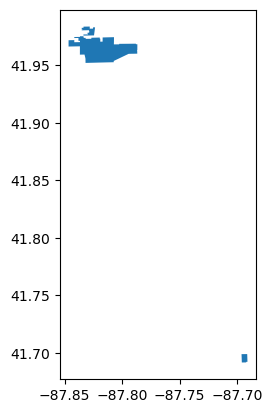

In [247]:
p1 = wkt.loads(df_police[df_police['BEAT_NUM'] == 3100]['the_geom'].iloc[0])
p2 = wkt.loads(df_police[df_police['BEAT_NUM'] == 3100]['the_geom'].iloc[1])
p3 = wkt.loads(df_police[df_police['BEAT_NUM'] == 3100]['the_geom'].iloc[2])

combined_geometry = gpd.GeoSeries([p1, p2, p3]).unary_union
combined_df = gpd.GeoDataFrame(geometry=[combined_geometry])
fig, ax = plt.subplots()
combined_df.plot(ax=ax)

plt.show()

In [248]:
df_police[df_police['BEAT_NUM'] == 3100]['the_geom'].index

Index([1, 55, 263], dtype='int64')

In [249]:
df_police = df_police.drop([55, 263])
df_police.loc[1, 'the_geom'] = combined_df.geometry.values[0]

In [250]:
df_police[df_police['BEAT_NUM'] == 3100].shape

(1, 3)

**21- PRIM_CONTRIBUTORY_CAUSE**

In [251]:
df_crashes['PRIM_CONTRIBUTORY_CAUSE'].value_counts()

PRIM_CONTRIBUTORY_CAUSE
UNABLE TO DETERMINE                                                                 320064
FAILING TO YIELD RIGHT-OF-WAY                                                        90193
FOLLOWING TOO CLOSELY                                                                79815
NOT APPLICABLE                                                                       43506
IMPROPER OVERTAKING/PASSING                                                          40466
FAILING TO REDUCE SPEED TO AVOID CRASH                                               34742
IMPROPER BACKING                                                                     32242
IMPROPER LANE USAGE                                                                  29293
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE                                                  27516
IMPROPER TURNING/NO SIGNAL                                                           27342
DISREGARDING TRAFFIC SIGNALS                                      

<div style="direction: rtl; text-align: right;">
    <b>نلاحظ أن UNABLE_TO_DETERMINE, NOT_APPLICABLE قيمتان فارغتان مقنعتان</b>

<div style="direction: rtl; text-align: right;">
سنقوم بتعبئة القيم الفارغة بالاستفادة من الأعمدة: SEC_CONTRIBUTORY_CAUSE, NOT_RIGHT_OF_WAY_I, HIT_AND_RUN_I, PHYSICAL_CONDITION, DRIVER_VISION, DRIVER_ACTION, VEHICLE_DEFECT

In [252]:
df_crashes['PRIM_CONTRIBUTORY_CAUSE'].replace(['UNABLE TO DETERMINE', 'NOT APPLICABLE'], np.nan, inplace=True)

In [253]:
df_crashes['SEC_CONTRIBUTORY_CAUSE'].value_counts()

SEC_CONTRIBUTORY_CAUSE
NOT APPLICABLE                                                                      337523
UNABLE TO DETERMINE                                                                 297180
FAILING TO REDUCE SPEED TO AVOID CRASH                                               30661
FAILING TO YIELD RIGHT-OF-WAY                                                        25834
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE                                                  25096
FOLLOWING TOO CLOSELY                                                                21658
IMPROPER OVERTAKING/PASSING                                                          12592
IMPROPER LANE USAGE                                                                  11508
WEATHER                                                                               9475
IMPROPER TURNING/NO SIGNAL                                                            8412
IMPROPER BACKING                                                   

<div style="direction: rtl; text-align: right;">
    سنقوم بتحويل القيم التي لا تعتبر من مسببات الحوادث إلى null وذلك لتسهيل الشروط والكود في التابع

In [254]:
df_crashes['SEC_CONTRIBUTORY_CAUSE'].replace(['UNABLE TO DETERMINE', 'NOT APPLICABLE'], np.nan, inplace=True)

In [255]:
df_crashes['DOORING_I'].value_counts()

DOORING_I
Y    1698
N     831
Name: count, dtype: int64

In [256]:
df_crashes['DOORING_I'].replace(['N'], np.nan, inplace=True)

In [257]:
df_crashes['HIT_AND_RUN_I'].value_counts()

HIT_AND_RUN_I
Y    246460
N     11051
Name: count, dtype: int64

In [258]:
df_crashes['HIT_AND_RUN_I'].replace(['N'], np.nan, inplace=True)

In [259]:
df_crashes['NOT_RIGHT_OF_WAY_I'].value_counts()

NOT_RIGHT_OF_WAY_I
Y    34447
N     3465
Name: count, dtype: int64

In [260]:
df_crashes['NOT_RIGHT_OF_WAY_I'].replace(['N'], np.nan, inplace=True)

In [261]:
df_people['DRIVER_ACTION'].value_counts()

DRIVER_ACTION
NONE                                 512928
UNKNOWN                              361730
FAILED TO YIELD                      130677
OTHER                                128372
FOLLOWED TOO CLOSELY                  85011
IMPROPER BACKING                      42605
IMPROPER TURN                         37704
IMPROPER LANE CHANGE                  36679
IMPROPER PASSING                      32045
DISREGARDED CONTROL DEVICES           25380
TOO FAST FOR CONDITIONS               21595
WRONG WAY/SIDE                         5756
IMPROPER PARKING                       5289
OVERCORRECTED                          2666
EVADING POLICE VEHICLE                 2295
CELL PHONE USE OTHER THAN TEXTING      2114
EMERGENCY VEHICLE ON CALL              1319
TEXTING                                 567
STOPPED SCHOOL BUS                      171
LICENSE RESTRICTIONS                     60
Name: count, dtype: int64

In [262]:
df_people['DRIVER_ACTION'].replace(['UNKNOWN', 'NONE'], np.nan, inplace=True)

In [263]:
df_people['DRIVER_VISION'].value_counts()

DRIVER_VISION
NOT OBSCURED              725017
UNKNOWN                   674982
OTHER                      14268
MOVING VEHICLES             7972
PARKED VEHICLES             5001
WINDSHIELD (WATER/ICE)      3930
BLINDED - SUNLIGHT          1695
TREES, PLANTS                575
BUILDINGS                    512
BLINDED - HEADLIGHTS         154
BLOWING MATERIALS            102
HILLCREST                     95
EMBANKMENT                    83
SIGNBOARD                     35
Name: count, dtype: int64

In [264]:
df_people['DRIVER_VISION'].replace(['UNKNOWN', 'NOT OBSCURED'], np.nan, inplace=True)

In [265]:
df_people['PHYSICAL_CONDITION'].value_counts()

PHYSICAL_CONDITION
NORMAL                          933783
UNKNOWN                         475602
IMPAIRED - ALCOHOL                6179
REMOVED BY EMS                    5269
OTHER                             4180
FATIGUED/ASLEEP                   3776
EMOTIONAL                         3545
ILLNESS/FAINTED                   1309
HAD BEEN DRINKING                 1049
IMPAIRED - DRUGS                   694
IMPAIRED - ALCOHOL AND DRUGS       383
MEDICATED                          178
Name: count, dtype: int64

In [266]:
df_people['PHYSICAL_CONDITION'].replace(['UNKNOWN', 'NORMAL'], np.nan, inplace=True)

In [267]:
df_vehicles['VEHICLE_DEFECT'].value_counts()

VEHICLE_DEFECT
NONE                885331
UNKNOWN             735094
OTHER                 9309
BRAKES                5147
TIRES                  829
STEERING               746
WHEELS                 417
SUSPENSION             267
FUEL SYSTEM            233
ENGINE/MOTOR           210
WINDOWS                108
LIGHTS                 100
CARGO                   57
SIGNALS                 42
RESTRAINT SYSTEM        25
TRAILER COUPLING        23
EXHAUST                 19
Name: count, dtype: int64

In [268]:
df_vehicles['VEHICLE_DEFECT'].replace(['UNKNOWN', 'NONE'], np.nan, inplace=True)

In [269]:
df_crashes['PRIM_CONTRIBUTORY_CAUSE'].isnull().sum()

363570

In [270]:
def check_group_not_null(group):
    if any(group.notnull()):
        return True
    else:
        return False

In [271]:
physical_condition = df_people.groupby('CRASH_RECORD_ID')['PHYSICAL_CONDITION'].apply(check_group_not_null)

In [272]:
def first_not_null(group):
    for value in group:
        if pd.notna(value):
            return value
    else:
        return False

In [273]:
driver_action = df_people.groupby('CRASH_RECORD_ID')['DRIVER_ACTION'].apply(first_not_null)

In [274]:
driver_vision = df_people.groupby('CRASH_RECORD_ID')['DRIVER_VISION'].apply(check_group_not_null)

In [275]:
vehicle_defect = df_vehicles.groupby('CRASH_RECORD_ID')['VEHICLE_DEFECT'].apply(check_group_not_null)

In [276]:
def fill_value(index):
    
    if pd.notna(df_crashes['SEC_CONTRIBUTORY_CAUSE'].loc[index]):
        return df_crashes['SEC_CONTRIBUTORY_CAUSE'].loc[index]
    
    elif pd.notna(df_crashes['DOORING_I'].loc[index]):
        return 'DOORING'
    
    elif pd.notna(df_crashes['HIT_AND_RUN_I'].loc[index]):
        return 'HIT_AND_RUN'
    
    elif pd.notna(df_crashes['NOT_RIGHT_OF_WAY_I'].loc[index]):
        return 'NOT_RIGHT_OF_WAY'
    
    return np.nan

In [277]:
df_crashes['PRIM_CONTRIBUTORY_CAUSE'] = df_crashes.apply(lambda row: fill_value(row.name) if pd.isnull(row['PRIM_CONTRIBUTORY_CAUSE']) else row['PRIM_CONTRIBUTORY_CAUSE'], axis=1)

In [278]:
df_crashes['PRIM_CONTRIBUTORY_CAUSE'].isnull().sum()

203923

In [279]:
df_crashes.loc[df_crashes['CRASH_RECORD_ID'].isin(df_people['CRASH_RECORD_ID']) & df_crashes['CRASH_RECORD_ID'].map(physical_condition), 'PRIM_CONTRIBUTORY_CAUSE'] = 'PHYSICAL CONDITION OF DRIVER'

In [280]:
df_crashes.loc[df_crashes['CRASH_RECORD_ID'].isin(df_people['CRASH_RECORD_ID']) & df_crashes['CRASH_RECORD_ID'].map(driver_vision), 'PRIM_CONTRIBUTORY_CAUSE'] = 'VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)'

In [281]:
df_crashes.loc[df_crashes['CRASH_RECORD_ID'].map(vehicle_defect), 'PRIM_CONTRIBUTORY_CAUSE'] = 'EQUIPMENT - VEHICLE CONDITION'

In [282]:
df_crashes.loc[df_crashes['CRASH_RECORD_ID'].isin(df_people['CRASH_RECORD_ID']) & df_crashes['CRASH_RECORD_ID'].map(driver_action), 'PRIM_CONTRIBUTORY_CAUSE'] = df_crashes['CRASH_RECORD_ID'].map(driver_action)

In [283]:
df_crashes['PRIM_CONTRIBUTORY_CAUSE'].isnull().sum()

123994

In [284]:
df_crashes['PRIM_CONTRIBUTORY_CAUSE'] = df_crashes['PRIM_CONTRIBUTORY_CAUSE'].fillna('UNKNOWN')

In [285]:
df_crashes['PRIM_CONTRIBUTORY_CAUSE'].isnull().sum()

0

**22- TRAFFICWAY_TYPE**

In [286]:
df_crashes['TRAFFICWAY_TYPE'].value_counts()

TRAFFICWAY_TYPE
NOT DIVIDED                        357166
DIVIDED - W/MEDIAN (NOT RAISED)    131398
ONE-WAY                            103847
PARKING LOT                         56001
FOUR WAY                            52450
DIVIDED - W/MEDIAN BARRIER          46994
OTHER                               22183
ALLEY                               13591
T-INTERSECTION                      10556
UNKNOWN                              9573
CENTER TURN LANE                     5945
DRIVEWAY                             2670
RAMP                                 2528
UNKNOWN INTERSECTION TYPE            2434
Y-INTERSECTION                       1151
FIVE POINT, OR MORE                  1148
TRAFFIC ROUTE                         940
NOT REPORTED                          584
ROUNDABOUT                            262
L-INTERSECTION                        168
Name: count, dtype: int64

<div style="direction: rtl; text-align: right;">
    سنقوم بتحويل قيمة UNKNOWN إلى null لأنها قيمة فارغة مقنعة

In [287]:
df_crashes['TRAFFICWAY_TYPE'].replace('UNKNOWN', np.nan, inplace=True)

<div style="direction: rtl; text-align: right;">
    سنقوم بتعبئة العمود بالقيمة الأكثر تكراراً حسب رقم الشارع

In [288]:
def custom_mode(series):
    modes = series.mode()
    if len(modes) == 0:  
        return np.nan
    if pd.isna(modes.iloc[0]):
        if len(modes) > 1:
            return modes.iloc[1]
        else:
            return np.nan  
    return modes.iloc[0]

ty = df_crashes.groupby('STREET_NO')['TRAFFICWAY_TYPE'].apply(custom_mode)
ty

STREET_NO
2                      NOT DIVIDED
6                      NOT DIVIDED
9                      NOT DIVIDED
10                         ONE-WAY
12                     NOT DIVIDED
                   ...            
2608                   NOT DIVIDED
2611                   PARKING LOT
4440                   PARKING LOT
4456    DIVIDED - W/MEDIAN BARRIER
4473                       ONE-WAY
Name: TRAFFICWAY_TYPE, Length: 1333, dtype: object

In [289]:
df_crashes['TRAFFICWAY_TYPE'] = df_crashes.apply(lambda row: ty.get(row['STREET_NO'], row['TRAFFICWAY_TYPE']) if pd.isna(row['TRAFFICWAY_TYPE']) else row['TRAFFICWAY_TYPE'], axis=1)

In [290]:
df_crashes['TRAFFICWAY_TYPE'].isnull().sum()

2

In [291]:
ids = list(df_crashes[df_crashes['TRAFFICWAY_TYPE'].isnull()]['CRASH_RECORD_ID'].unique())
df_crashes = df_crashes[~df_crashes['CRASH_RECORD_ID'].isin(ids)]
df_vehicles = df_vehicles[~df_vehicles['CRASH_RECORD_ID'].isin(ids)]
df_people = df_people[~df_people['CRASH_RECORD_ID'].isin(ids)]

In [292]:
df_crashes['TRAFFICWAY_TYPE'].isnull().sum()

0

**23- VEHICLE_YEAR**

In [293]:
print(df_vehicles['VEHICLE_YEAR'].max())
print(df_vehicles['VEHICLE_YEAR'].min())

9999.0
1900.0


In [294]:
pd.set_option('display.max_rows', None)
df_vehicles['VEHICLE_YEAR'].value_counts()

VEHICLE_YEAR
2015.0    102026
2016.0     95926
2017.0     95304
2014.0     90192
2013.0     83341
2018.0     74033
2012.0     72341
2007.0     64060
2008.0     63087
2011.0     61958
2019.0     58368
2006.0     55851
2010.0     53774
2005.0     49245
2009.0     45155
2020.0     42919
2004.0     42766
2003.0     36487
2002.0     31708
2021.0     28692
2001.0     23939
2000.0     20982
2022.0     18096
1999.0     15220
1998.0     10426
2023.0     10127
1997.0      7969
1996.0      4679
1995.0      3737
1994.0      2500
2024.0      1916
1993.0      1575
1992.0      1180
1991.0       760
1990.0       621
1989.0       463
9999.0       396
1988.0       394
1900.0       355
1987.0       301
1986.0       226
1985.0       212
1984.0       146
1983.0       103
1978.0        79
1982.0        72
1981.0        70
1979.0        66
1980.0        59
1970.0        47
1976.0        45
1977.0        42
1975.0        39
1972.0        37
1971.0        33
2103.0        33
2104.0        32
1973.0        29
1

In [295]:
df_vehicles['VEHICLE_YEAR'].fillna(0, inplace=True)
df_vehicles['VEHICLE_YEAR'] = df_vehicles['VEHICLE_YEAR'].astype(int)

In [296]:
d = {}

<div style="direction: rtl; text-align: right;">
    سنقوم بكتابة تابع تقديري لتصحيح حالات الأعوام المدخلة خطأً بافتراض أن الخطأ نابع من typos ومن ثم نستبدل القيم التي تقع خارج نطاق أعوام منطقي بالعام الأكثر تكراراً

In [297]:
def correct_year(year):
    
    year = str(year)
    y = list(year)
    
    if len(y) == 1:
        return 0
    
    if y[0] not in ['1', '2']: 
        if y[1] == '0': 
            y[0] = '2' # 3012 -> 2012
        else:
            y[0] = '1' # 9999 -> 1999
    
    
    if y[0] == '2' and y[2] == '9': # 2091 -> 2001
        y[2] = '0'
    
    if y[0] == '2' and y[1] == '1' and y[2] == '0': # 2103 -> 2013
        y[2], y[1] = y[1], y[2]
    
    if y[0] == '2' and y[1] != '0': # 2100 -> 2000
        y[1] = '0'
    
    if y[0] == '2' and y[1] == '2' and y[2] == '0' and not (0 <= int(y[3]) <= 4): # 2205 -> 2005
        y[1] = '0'
        
#     if y[0] == '2' and y[1] in ['2', '0'] and y[2] == '0' and (0 <= int(y[3]) <= 4): # 2202 -> 2022
#         y[2], y[1] = y[1], y[2]
    
    if y[0] == '2' and y[1] == '0' and y[2] not in ['0', '1', '2'] and y[3] in ['1', '2']: # 2032 -> 2023
        y[2], y[3] = y[3], y[2]
    
    if y[0] == '2' and y[2] not in ['1', '2']: # 2088 -> 2008
        y[2] = '0'
        
    if y[0] == '2' and y[2] == '2' and int(y[3]) > 4: # 2025 -> 2015
        y[2] = '1'
        
    

    d[int(''.join(y))] = year
    return int(''.join(y))

In [298]:
correct_year(2203)

2003

In [299]:
df_vehicles['VEHICLE_YEAR'] = df_vehicles['VEHICLE_YEAR'].apply(correct_year)

In [300]:
df_vehicles['VEHICLE_YEAR'] = df_vehicles['VEHICLE_YEAR'].apply(lambda x: 0 if (x < 1950) | (x > 2024) else x)

In [301]:
df_vehicles['VEHICLE_YEAR'].replace(0, 2015, inplace=True)

<div style="direction: rtl; text-align: right;">
    الآن سنقوم بالتحقق من وجود تناقض بين عمودي عام السيارة وعام الحادث حيث يجب أن يكون عام السيارة قبل عام وقوع الحادث

In [302]:
df_vehicles[df_vehicles['CRASH_DATE'].dt.year < (df_vehicles['VEHICLE_YEAR'])].shape[0]

5876

In [303]:
df_vehicles[df_vehicles['CRASH_DATE'].dt.year < (df_vehicles['VEHICLE_YEAR'])].head()

,CRASH_RECORD_ID,CRASH_DATE,UNIT_TYPE,VEHICLE_ID,VEHICLE_YEAR,MAKE,MODEL,VEHICLE_DEFECT,VEHICLE_TYPE,TRAVEL_DIRECTION,OCCUPANT_CNT,SEX
95,e7cde3141aff62506aa22760789908028581a0e79e3720cf361ba976087bbe9e0a4f8c2984c67762f395b5883a95d8dc6a8d679b46449b7638ac9c7849d784a3,2023-12-21 10:02:00,DRIVER,1644199.0,2024,HONDA,CR-V,NaN,SPORT UTILITY VEHICLE (SUV),E,1.0,F
139,df2f064b069b4508d15357111f9fc7b123933b038a5fb8f48059bb92e43c6b1cface476537eb10f64264982945f482d0ab4c2fc4fb9c6202084114b34674eda7,2020-11-25 19:15:00,DRIVER,947687.0,2021,KIA,FORTE,NaN,PASSENGER,S,2.0,F
449,05ae1932f70f2d58118c2e58e10bd04c8c9fc0123d33e3b391d15c330778ba6fba7f334b5c7130461b40267b731c4a1ee83b6a45e0127872d66782af745ba328,2020-11-26 14:31:00,DRIVER,947968.0,2021,NISSAN,ALTIMA,NaN,PASSENGER,W,1.0,M
464,34a17c37580ebcd64566ecd76899fae11cacbf9e923cd8200be47140ff2414e6e32d14541faf3e0c3fd4e7640e295e699e3c8a4c5591e4e8868839e03e466086,2016-11-22 16:45:00,DRIVER,96811.0,2017,CHEVROLET,TRAVERSE,NaN,PASSENGER,W,1.0,F
716,35d1c54cabf06eb082f652103dc25198cf67688d928f24645165c24c271dd092e930aab084344c68f1b0b36d5ca0a6b91e2fa85e82696252fdab71fdf3b19d21,2020-11-27 11:54:00,DRIVER,948233.0,2021,SUBARU,OUTBACK,NaN,PASSENGER,N,2.0,M


<div style="direction: rtl; text-align: right;">
    نلاحظ أن هناك الكثير من الحالات التي يكون فيها وقت الحادث هو آخر أشهر السنة ويكون عام السيارة هو العام التالي للحادث مثلاً يكون تاريخ الحادث: 2023-12-21 وعام السيارة 2024 فسنقوم باعتبار هذه الحالات صحيحة وذلك لأنه بعض السيارات يتم إصدارها في آخر العام السابق من العام الذي يفترض أن تصدر فيه

In [304]:
df_vehicles[(df_vehicles['VEHICLE_YEAR'] - df_vehicles['CRASH_DATE'].dt.year) > 1].shape[0]

37

In [305]:
df_vehicles[(df_vehicles['VEHICLE_YEAR'] - df_vehicles['CRASH_DATE'].dt.year) > 1].head()

,CRASH_RECORD_ID,CRASH_DATE,UNIT_TYPE,VEHICLE_ID,VEHICLE_YEAR,MAKE,MODEL,VEHICLE_DEFECT,VEHICLE_TYPE,TRAVEL_DIRECTION,OCCUPANT_CNT,SEX
77165,ce11ddfee192c3e21768e0ec47c0b53a621857dcf52c57122a18b45f5eff833de77694cc4d59ac97f89a9ad4bf89393f9bf1cd9aeb8376e68f19ee088cbfb7c6,2016-12-14 17:38:00,DRIVER,105477.0,2018,JEEP,PATRIOT,NaN,PASSENGER,S,1.0,M
192476,a50a384c5c6ffbd34279ef0fd4e78916d4abb8192058d9ae582c0d76bfeb6588ae2b3dccfbaa6d3e552116e6ff7a986a8e5d813944599326e491a650d2814c77,2021-09-16 20:15:00,DRIVER,1124612.0,2023,CHEVROLET,IMPALA,NaN,PASSENGER,N,1.0,M
336818,8a8dd4b4103a400222b3552b45e80c1ca6547e9421b2ac242d594084fc145cc149e73e0f0639ce119b0f7a1961ac27134118205914058fee06e404cc154b325c,2022-04-25 11:20:00,DRIVER,1257224.0,2024,FORD,VAN,NaN,BUS UP TO 15 PASS.,N,1.0,M
350300,89c742a6b04c908940791b4c5fd52be75d83ce285e449cc19175c4d2809dcee4c66fa63f7f37009fecfd42b6ec33b05efccb023d6ddc946dfdce1eeb663398a9,2017-03-08 13:00:00,DRIVER,133494.0,2022,CHRYSLER,200,NaN,UNKNOWN/NA,S,1.0,F
415593,19fb5af681f833c2af85734245f737fa6fbe62ac1ea379e14e22f71138add54f31f27960167f0ea70e7575704c5c7beb9a110fa7481f50b395c510814752a834,2013-06-01 20:29:00,PEDESTRIAN,NaN,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div style="direction: rtl; text-align: right;">
سنقوم بحذف الحوادث التي تحوي تناقض

In [306]:
ids = list(df_vehicles[(df_vehicles['VEHICLE_YEAR'] - df_vehicles['CRASH_DATE'].dt.year) > 1]['CRASH_RECORD_ID'].unique())

In [307]:
df_crashes = df_crashes[~df_crashes['CRASH_RECORD_ID'].isin(ids)]
df_vehicles = df_vehicles[~df_vehicles['CRASH_RECORD_ID'].isin(ids)]
df_people = df_people[~df_people['CRASH_RECORD_ID'].isin(ids)]

In [308]:
df_vehicles[(df_vehicles['VEHICLE_YEAR'] - df_vehicles['CRASH_DATE'].dt.year) > 1].shape[0]

0

**24- PERSON_TYPE**

In [309]:
df_people['PERSON_TYPE'].unique()

['DRIVER', 'NON-CONTACT VEHICLE', 'PASSENGER', 'PEDESTRIAN', 'BICYCLE', 'NON-MOTOR VEHICLE']
Categories (6, object): ['BICYCLE', 'DRIVER', 'NON-CONTACT VEHICLE', 'NON-MOTOR VEHICLE', 'PASSENGER', 'PEDESTRIAN']


**25- PERSON_ID**

In [310]:
df_people['PERSON_ID'].unique()

array(['O749947', 'O871921', 'O10018', ..., 'P382517', 'P382518',
       'P382519'], dtype=object)

In [311]:
df_crashes.drop(['the_geom2', 'location', 'HIT_AND_RUN_I', 'NOT_RIGHT_OF_WAY_I', 'DOORING_I', 'SEC_CONTRIBUTORY_CAUSE'], axis=1, inplace=True)

In [312]:
df_vehicles.drop(['TRAVEL_DIRECTION'], axis=1, inplace=True)

In [313]:
df_people.drop(['PHYSICAL_CONDITION', 'DRIVER_ACTION', 'DRIVER_VISION'], axis=1, inplace=True)

In [314]:
print("crashes shape: ", df_crashes.shape[0])
print("people shape: ", df_people.shape[0])
print("vehices shape", df_vehicles.shape[0])

crashes shape:  821551
people shape:  1802979
vehices shape 1673133


In [315]:
df_crashes_copy=df_crashes.copy()
df_crashes_copy = df_crashes.merge(df_crashes_org[['CRASH_RECORD_ID','ROADWAY_SURFACE_COND']], on=['CRASH_RECORD_ID'], how='left')

## filling null values PRIM_CONTRIBUTORY_CAUSE

In [316]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

X = pd.get_dummies(df_crashes_copy[df_crashes_copy['PRIM_CONTRIBUTORY_CAUSE'] != 'UNKNOWN'][['WEATHER_CONDITION', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'LIGHTING_CONDITION','ROADWAY_SURFACE_COND','ROAD_DEFECT','FIRST_CRASH_TYPE','TRAFFICWAY_TYPE','CRASH_TYPE','STREET_NO']], dtype=int).values
encoder = LabelEncoder()
y = encoder.fit_transform(df_crashes_copy[df_crashes_copy['PRIM_CONTRIBUTORY_CAUSE'] != 'UNKNOWN']['PRIM_CONTRIBUTORY_CAUSE'])

In [317]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [318]:
classifier_NB = MultinomialNB()
classifier_NB.fit(X_train, y_train)

MultinomialNB()

In [319]:
print(classifier_NB.score(X_train, y_train))
print(classifier_NB.score(X_test, y_test))

0.37872842269442275
0.38087537917232916


In [320]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(multi_class='multinomial', solver='lbfgs')
classifier.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial')

In [321]:
print(classifier.score(X_train, y_train))
print(classifier.score(X_test, y_test))

0.17937524011950068
0.18072399694941885


In [322]:
from sklearn.ensemble import RandomForestClassifier

classifier_random = RandomForestClassifier()
classifier_random.fit(X_train, y_train)

RandomForestClassifier()

In [323]:
print(classifier_random.score(X_train, y_train))
print(classifier_random.score(X_test, y_test))

0.6946253371230005
0.3393370146737541


In [324]:
classifier_NB.fit(X,y)

MultinomialNB()

In [325]:
rows_with_missing_prime = pd.get_dummies(df_crashes_copy[df_crashes_copy['PRIM_CONTRIBUTORY_CAUSE'] == 'UNKNOWN'][['WEATHER_CONDITION', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'LIGHTING_CONDITION','ROADWAY_SURFACE_COND','ROAD_DEFECT','FIRST_CRASH_TYPE','TRAFFICWAY_TYPE','CRASH_TYPE','STREET_NO']], dtype=int)
x = rows_with_missing_prime.values
predictions = classifier_NB.predict(x)

In [326]:
predicted_labels = encoder.inverse_transform(predictions)

for i, ind in enumerate(rows_with_missing_prime.index):
    df_crashes_copy.loc[ind, 'PRIM_CONTRIBUTORY_CAUSE'] = predicted_labels[i]

In [327]:
df_crashes_copy[df_crashes_copy['PRIM_CONTRIBUTORY_CAUSE'] == 'UNKNOWN']['PRIM_CONTRIBUTORY_CAUSE'].count()

0

In [328]:
df_crashes['PRIM_CONTRIBUTORY_CAUSE'] = df_crashes_copy['PRIM_CONTRIBUTORY_CAUSE']

In [329]:
df_crashes.to_csv('clean_crashes.csv', index=False)
df_vehicles.to_csv('clean_vehicles.csv', index=False)
df_people.to_csv('clean_people.csv', index=False)
df_final_str.to_csv('clean_streets.csv', index=False)
df_police.to_csv('clean_police.csv', index=False)

In [330]:
df_crashes = pd.read_csv('clean_crashes.csv')
df_crashes['CRASH_DATE'] = pd.to_datetime(df_crashes['CRASH_DATE'], format='%Y-%m-%d %H:%M:%S')
df_crashes = convert_type(df_crashes, 'object', 'category', ['CRASH_RECORD_ID'])

In [331]:
df_vehicles = pd.read_csv('clean_vehicles.csv')
df_vehicles['CRASH_DATE'] = pd.to_datetime(df_vehicles['CRASH_DATE'], format='%Y-%m-%d %H:%M:%S')
df_vehicles = convert_type(df_vehicles, 'object', 'category', ['CRASH_RECORD_ID'])

In [332]:
df_people = pd.read_csv('clean_people.csv')
df_people = convert_type(df_people, 'object', 'category', ['CRASH_RECORD_ID', 'PERSON_ID'])

In [333]:
df_streets = pd.read_csv('clean_streets.csv')
df_streets = convert_type(df_streets, 'object', 'category', ['the_geom2'])

In [334]:
df_police = pd.read_csv('clean_police.csv')

# [b] From Raw to Information

### [i]

In [335]:
df_crashes['CRASH_YEAR'] = df_crashes['CRASH_DATE'].dt.year
df_crashes[['CRASH_RECORD_ID', 'CRASH_DATE', 'CRASH_MONTH', 'CRASH_HOUR', 'CRASH_YEAR']].head()

,CRASH_RECORD_ID,CRASH_DATE,CRASH_MONTH,CRASH_HOUR,CRASH_YEAR
0,6c1659069e9c6285a650e70d6f9b574ed5f64c12888479093dfeef179c0344ec6d2057eae224b5c0d5dfc278c0a237f8c22543f07fdef2e4a95a3849871c9345,2023-08-18 12:50:00,8,12,2023
1,5f54a59fcb087b12ae5b1acff96a3caf4f2d37e79f8db4106558b34b8a6d2b81af02cf91b576ecd7ced08ffd10fcfd940a84f7613125b89d33636e6075064e22,2023-07-29 14:45:00,7,14,2023
2,61fcb8c1eb522a6469b460e2134df3d15f82e81fd93e9cafd3dc7e631b9e1ba8b450a63af12bd90d1d2d9b127ea287f88d32e138a4eeba17799f536c08048934,2023-08-18 17:58:00,8,17,2023
3,b236c77d59e32b7b469a6e2f17f438b7457e1bd8bc689b14cb4f5b1590cbe784f2b9e554b41925797251cbd3e93a3f4a131d1923b327673d441ae79c052f79c2,2023-07-29 13:00:00,7,13,2023
4,0e208d23344f0d1b3a9fcd4bb07676a750ddb73c397b5c398a33743fd0d49b8ce737c7740b1a77cdaebd61e8e79bddb284452d744b16668f9777f256eec28ff5,2023-08-13 13:30:00,8,13,2023


### [ii]

In [336]:
df_passenger_cnt = df_people[df_people['PERSON_TYPE'] == 'PASSENGER'].groupby(['CRASH_RECORD_ID', 'VEHICLE_ID'])['PERSON_TYPE'].size()

df_vehicles['Passenger_Count'] = df_vehicles.apply(lambda row: df_passenger_cnt.get((row['CRASH_RECORD_ID'],row['VEHICLE_ID']), 0), axis=1)

df_vehicles[df_vehicles['Passenger_Count'] != 0][['CRASH_RECORD_ID','VEHICLE_ID','Passenger_Count']].head()

,CRASH_RECORD_ID,VEHICLE_ID,Passenger_Count
8,e7b21f99e7f940699c7de99590891cb54ffe630e2f904e66e47bf9310d8f3c3e33bb98ec577ca4d6cab9fec2512279c166b98bc96af497fb494931d8dc900540,1637438.0,1
14,aa01108286e0df60061744b1c7749de93ba49062b046e5dcc5ed907ca008b12fd490bf5cfeb9805dbcf15976cb41aff672edae2deffefe52f7049cd17f68f189,1637829.0,1
20,7d63bd4bcbde74ed94fb56f603e93bc94569871ecefbbca2d959171883ff2ff7bed8bcc09fdd380f4d293a514db59b01f39b0a9652e09452312f351fbc32b224,1638172.0,1
22,507700b25031a75d5b3b6511fe44b9e68c086ec708907449ded0bc44398532612b45ee0180673bb6fa2136c4fd209ecb8b2677b6328899ffb65779cb428088dc,1638182.0,2
24,d4dca52c16aeb89750643dbf022eb01da25e6f9ba921bfdbb6837accaae808aaca20e0102282ece1ec0a69be7dac5635b47778eb1973d6282e5a852381d79277,1638264.0,3


In [337]:
# example
df_people[(df_people['CRASH_RECORD_ID']== 'd4dca52c16aeb89750643dbf022eb01da25e6f9ba921bfdbb6837accaae808aaca20e0102282ece1ec0a69be7dac5635b47778eb1973d6282e5a852381d79277')  &  (df_people['VEHICLE_ID']== 1638264.0)]

,PERSON_ID,PERSON_TYPE,CRASH_RECORD_ID,VEHICLE_ID,SEX,AGE,INJURY_CLASSIFICATION,MAKE
1396481,O1720928,DRIVER,d4dca52c16aeb89750643dbf022eb01da25e6f9ba921bfdbb6837accaae808aaca20e0102282ece1ec0a69be7dac5635b47778eb1973d6282e5a852381d79277,1638264.0,F,43.0,NONINCAPACITATING INJURY,KIA
1799089,P380567,PASSENGER,d4dca52c16aeb89750643dbf022eb01da25e6f9ba921bfdbb6837accaae808aaca20e0102282ece1ec0a69be7dac5635b47778eb1973d6282e5a852381d79277,1638264.0,M,11.0,NO INDICATION OF INJURY,NaN
1801101,P380565,PASSENGER,d4dca52c16aeb89750643dbf022eb01da25e6f9ba921bfdbb6837accaae808aaca20e0102282ece1ec0a69be7dac5635b47778eb1973d6282e5a852381d79277,1638264.0,F,20.0,NONINCAPACITATING INJURY,NaN
1801102,P380566,PASSENGER,d4dca52c16aeb89750643dbf022eb01da25e6f9ba921bfdbb6837accaae808aaca20e0102282ece1ec0a69be7dac5635b47778eb1973d6282e5a852381d79277,1638264.0,M,16.0,NO INDICATION OF INJURY,NaN


In [338]:
df_passenger_avg = df_vehicles.groupby('CRASH_RECORD_ID')['Passenger_Count'].mean().round().reset_index().rename({'Passenger_Count': 'Passenger_Avg'}, axis=1)

df_crashes = df_crashes.merge(df_passenger_avg, on=['CRASH_RECORD_ID'], how='left')

In [339]:
df_crashes.columns

Index(['CRASH_RECORD_ID', 'CRASH_DATE', 'LIGHTING_CONDITION',
       'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'CRASH_TYPE', 'DAMAGE',
       'PRIM_CONTRIBUTORY_CAUSE', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH',
       'CRASH_HOUR', 'LATITUDE', 'LONGITUDE', 'STREET_NO',
       'BEAT_OF_OCCURRENCE', 'POSTED_SPEED_LIMIT', 'TRAFFIC_CONTROL_DEVICE',
       'DEVICE_CONDITION', 'WEATHER_CONDITION', 'ALIGNMENT', 'ROAD_DEFECT',
       'MOST_SEVERE_INJURY', 'INJURIES_TOTAL', 'most_comon_lighting',
       'CRASH_YEAR', 'Passenger_Avg'],
      dtype='object')

In [340]:
df_crashes[df_crashes['Passenger_Avg'] > 2][['CRASH_RECORD_ID', 'Passenger_Avg']].head()

,CRASH_RECORD_ID,Passenger_Avg
31,abef801ced512af26d8865f3a6eb17a26166d268f75cfc0945be37108e71e45369956186a46a8e21ca2def36bb2056979ea56938dd8b86fc1395fb69c877bd9c,3.0
71,7f2bbbf0a7e0345852d0a9d841b16904e4bfa0149a8f7ecd41906d3ef0d20f947739073772ae6f52df891bab02be4f0a1be6699253b1e45c4f106129560a637d,3.0
107,af17b2e3e114471b75ceb49a300238ad897615d25510bbfe7b2220b0e03a202f991ed7de80332511198109af879954fa12b32766b9923fdce38c315254cfd312,3.0
270,b5380719a55f2f4511730944f282cf495dfaf07aa04d490efcb0762cfd39a8662a9947fb3660e22ef163edf5da376d9cab1b8caac33c1b502a0258f932e230d3,4.0
492,006bc88aa00209dba00e7f4e77939f4cac6d1918b26e0fdc14f9594dbde0aeb4c0de21e0b0ca0480bb36f68bee6ccc03f8e085d4502517eaf8dc89e832d2c6d0,3.0


In [341]:
df_passenger_age = df_people[df_people['PERSON_TYPE'] == 'PASSENGER'].groupby('CRASH_RECORD_ID')['AGE'].mean().round().reset_index().rename({'AGE': 'Passenger_Age_Avg'}, axis=1)

df_crashes = df_crashes.merge(df_passenger_age, on=['CRASH_RECORD_ID'], how='left')

df_crashes[df_crashes['Passenger_Age_Avg'].notna()][['CRASH_RECORD_ID', 'Passenger_Age_Avg']].head()

,CRASH_RECORD_ID,Passenger_Age_Avg
3,b236c77d59e32b7b469a6e2f17f438b7457e1bd8bc689b14cb4f5b1590cbe784f2b9e554b41925797251cbd3e93a3f4a131d1923b327673d441ae79c052f79c2,17.0
6,359bf9f5872d646bb63576e55b1e0b480dc93c2b935ab571dc26ddb48b7a328fbfe130ae70bbff9f03787041b6fb029ba02529da9a1f57494e385ec0e13ed834,26.0
17,1ee2180a89cc02c0b756f95b5b2755bb5cc9d93450f5caafaee5cb5c6aa75adafd251402ac205833ff78be9c9a0eb799f33d9c854975cf3a8e10c6a7d28116c7,22.0
18,4a1f7a24129e5e1d4a7a2fd44ab6f8822a20bcdb2f627f490af8975d8c14e9fadf2d7b533a09a7e8c2cc57a4b3563803d7d4eb4db3892337cf233f1f0f154013,17.0
21,3afcf76e1a3205a2b95e7f45a2eed16ec18aa5a91cb0f914e097eb0bfb020c898ef94c150d3a1b62f67f5ef9247e22c7f8c6422103302f7394cab2f0aadb025c,17.0


### [iii]

In [342]:
df_vehicle_no = df_vehicles[['CRASH_RECORD_ID', 'CRASH_DATE']].groupby('CRASH_RECORD_ID').count().reset_index().rename({'CRASH_DATE': 'Vehicles_NO'}, axis=1)

df_crashes = df_crashes.merge(df_vehicle_no, on=['CRASH_RECORD_ID'], how='left')

df_crashes[['CRASH_RECORD_ID', 'Vehicles_NO']].head()

,CRASH_RECORD_ID,Vehicles_NO
0,6c1659069e9c6285a650e70d6f9b574ed5f64c12888479093dfeef179c0344ec6d2057eae224b5c0d5dfc278c0a237f8c22543f07fdef2e4a95a3849871c9345,2
1,5f54a59fcb087b12ae5b1acff96a3caf4f2d37e79f8db4106558b34b8a6d2b81af02cf91b576ecd7ced08ffd10fcfd940a84f7613125b89d33636e6075064e22,4
2,61fcb8c1eb522a6469b460e2134df3d15f82e81fd93e9cafd3dc7e631b9e1ba8b450a63af12bd90d1d2d9b127ea287f88d32e138a4eeba17799f536c08048934,2
3,b236c77d59e32b7b469a6e2f17f438b7457e1bd8bc689b14cb4f5b1590cbe784f2b9e554b41925797251cbd3e93a3f4a131d1923b327673d441ae79c052f79c2,2
4,0e208d23344f0d1b3a9fcd4bb07676a750ddb73c397b5c398a33743fd0d49b8ce737c7740b1a77cdaebd61e8e79bddb284452d744b16668f9777f256eec28ff5,2


### [iv]

In [343]:
df_vehicles['Vehicle_Age'] = df_vehicles['CRASH_DATE'].dt.year - df_vehicles['VEHICLE_YEAR']
df_vehicles[['CRASH_RECORD_ID', 'CRASH_DATE', 'VEHICLE_YEAR', 'Vehicle_Age']].head()

,CRASH_RECORD_ID,CRASH_DATE,VEHICLE_YEAR,Vehicle_Age
0,7b1763088507f77e0e552c009a6bf89a4d6330c75277067fe4c9c8081d86be3db49c1f283c6bcf64b690e03175db497c49aaa3456b5e3c858b3e013dabc1228e,2023-12-06 15:24:00,2009,14
1,a52ef70e33d468b855b5be44e8638a564434dcf99c0edf8a4267a015d05251b38269f43350bec80f8d93976979da8014a0740978c57f781da70b104eabeee5b8,2023-12-06 16:30:00,2015,8
2,609055f4b1a72a44d6ec40ba9036cefd7c1287a755eb6c5198f3421f7aa929683278e14f2bcb64bd0f251c3aa3d89fad563f5a056f214e58e77fb931be551d48,2023-12-10 12:12:00,2018,5
3,609055f4b1a72a44d6ec40ba9036cefd7c1287a755eb6c5198f3421f7aa929683278e14f2bcb64bd0f251c3aa3d89fad563f5a056f214e58e77fb931be551d48,2023-12-10 12:12:00,2019,4
4,ffcd23c52046f9ef2c366fbd8a41721ecb9c7982af7866ebfe4ec18fa8f56d7bdd9f48b0975ae89e5df5067eb79cff0784624088ec3d4477661220d13baa96d9,2023-12-10 14:42:00,2015,8


In [344]:
bins = [-1, 5, 15, float('inf')]
labels = ['New', 'Old', 'Obsolete']

df_vehicles['Vehicle_Age_Category'] = pd.cut(df_vehicles['Vehicle_Age'], bins=bins, labels=labels, right=False)

df_vehicles[['CRASH_RECORD_ID', 'Vehicle_Age', 'Vehicle_Age_Category']].head()

,CRASH_RECORD_ID,Vehicle_Age,Vehicle_Age_Category
0,7b1763088507f77e0e552c009a6bf89a4d6330c75277067fe4c9c8081d86be3db49c1f283c6bcf64b690e03175db497c49aaa3456b5e3c858b3e013dabc1228e,14,Old
1,a52ef70e33d468b855b5be44e8638a564434dcf99c0edf8a4267a015d05251b38269f43350bec80f8d93976979da8014a0740978c57f781da70b104eabeee5b8,8,Old
2,609055f4b1a72a44d6ec40ba9036cefd7c1287a755eb6c5198f3421f7aa929683278e14f2bcb64bd0f251c3aa3d89fad563f5a056f214e58e77fb931be551d48,5,Old
3,609055f4b1a72a44d6ec40ba9036cefd7c1287a755eb6c5198f3421f7aa929683278e14f2bcb64bd0f251c3aa3d89fad563f5a056f214e58e77fb931be551d48,4,New
4,ffcd23c52046f9ef2c366fbd8a41721ecb9c7982af7866ebfe4ec18fa8f56d7bdd9f48b0975ae89e5df5067eb79cff0784624088ec3d4477661220d13baa96d9,8,Old


In [345]:
unique_cats = df_vehicles.groupby('CRASH_RECORD_ID')['Vehicle_Age_Category'].apply(set).reset_index().rename({'Vehicle_Age_Category': 'Vehicles_Age_Categories'})

df_crashes = df_crashes.merge(unique_cats, on=['CRASH_RECORD_ID'], how='left')
df_crashes[['CRASH_RECORD_ID', 'Vehicle_Age_Category']].head()

,CRASH_RECORD_ID,Vehicle_Age_Category
0,6c1659069e9c6285a650e70d6f9b574ed5f64c12888479093dfeef179c0344ec6d2057eae224b5c0d5dfc278c0a237f8c22543f07fdef2e4a95a3849871c9345,"{Old, Obsolete}"
1,5f54a59fcb087b12ae5b1acff96a3caf4f2d37e79f8db4106558b34b8a6d2b81af02cf91b576ecd7ced08ffd10fcfd940a84f7613125b89d33636e6075064e22,"{New, Old}"
2,61fcb8c1eb522a6469b460e2134df3d15f82e81fd93e9cafd3dc7e631b9e1ba8b450a63af12bd90d1d2d9b127ea287f88d32e138a4eeba17799f536c08048934,"{Old, Obsolete}"
3,b236c77d59e32b7b469a6e2f17f438b7457e1bd8bc689b14cb4f5b1590cbe784f2b9e554b41925797251cbd3e93a3f4a131d1923b327673d441ae79c052f79c2,"{Old, New}"
4,0e208d23344f0d1b3a9fcd4bb07676a750ddb73c397b5c398a33743fd0d49b8ce737c7740b1a77cdaebd61e8e79bddb284452d744b16668f9777f256eec28ff5,"{New, Old}"


### [v]

In [346]:
def categorize(categories):
        if len(categories) == 1:
            if 'New' in categories:
                return 'new'
            return 'old'
        if len(categories) == 2 and 'Obselete' in categories and 'Old' in categories:
            return 'old'
        return 'mixed'

In [347]:
df_crashes['V_Nominal_Category'] = df_crashes['Vehicle_Age_Category'].apply(categorize)
df_crashes[['CRASH_RECORD_ID', 'V_Nominal_Category']].head()

,CRASH_RECORD_ID,V_Nominal_Category
0,6c1659069e9c6285a650e70d6f9b574ed5f64c12888479093dfeef179c0344ec6d2057eae224b5c0d5dfc278c0a237f8c22543f07fdef2e4a95a3849871c9345,mixed
1,5f54a59fcb087b12ae5b1acff96a3caf4f2d37e79f8db4106558b34b8a6d2b81af02cf91b576ecd7ced08ffd10fcfd940a84f7613125b89d33636e6075064e22,mixed
2,61fcb8c1eb522a6469b460e2134df3d15f82e81fd93e9cafd3dc7e631b9e1ba8b450a63af12bd90d1d2d9b127ea287f88d32e138a4eeba17799f536c08048934,mixed
3,b236c77d59e32b7b469a6e2f17f438b7457e1bd8bc689b14cb4f5b1590cbe784f2b9e554b41925797251cbd3e93a3f4a131d1923b327673d441ae79c052f79c2,mixed
4,0e208d23344f0d1b3a9fcd4bb07676a750ddb73c397b5c398a33743fd0d49b8ce737c7740b1a77cdaebd61e8e79bddb284452d744b16668f9777f256eec28ff5,mixed


### [vi]

![GEOHASH Image](geohash.jpg)

In [348]:
def apply_geohash(x, y, precision):
    return ghh.encode(x, y, precision)

df_crashes['Geohash'] = df_crashes.apply(lambda row: apply_geohash(row['LONGITUDE'], row['LATITUDE'], 5), axis=1)

In [349]:
df_crashes['Geohash'].nunique()

1135

### [vii]

In [350]:
grouped = df_crashes[['CRASH_RECORD_ID', 'Geohash']].groupby('Geohash').count().rename({'CRASH_RECORD_ID': 'Accidents_NO'}, axis=1)
grouped.head()

,Accidents_NO
Geohash,
SLFPw,94
SLFPx,11
SLFPy,44
SLFPz,257
SLFQ3,103


In [351]:
grouped['Accidents_NO'].describe()

count    1135.00000
mean      723.83348
std       705.41372
min         1.00000
25%       222.00000
50%       596.00000
75%      1036.50000
max      7266.00000
Name: Accidents_NO, dtype: float64

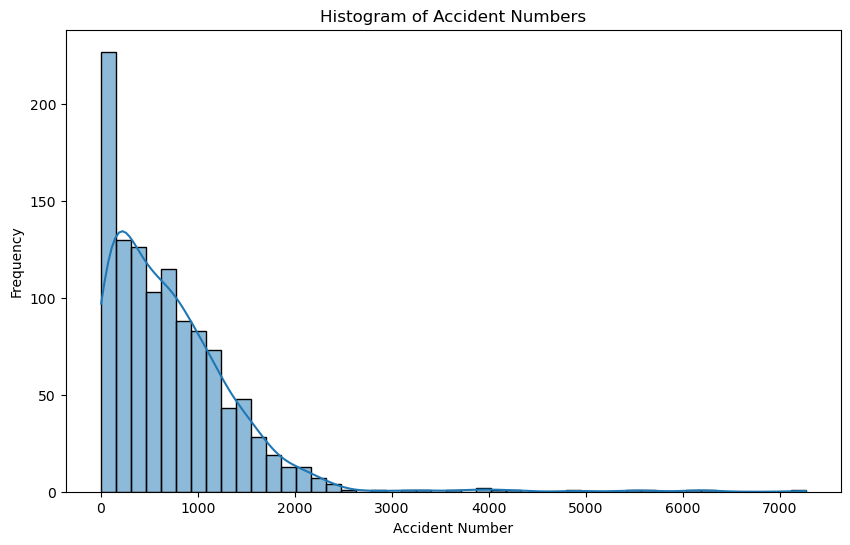

In [352]:
plt.figure(figsize=(10, 6))
sns.histplot(grouped['Accidents_NO'], kde=True)
plt.title('Histogram of Accident Numbers')
plt.xlabel('Accident Number')
plt.ylabel('Frequency')
plt.show()

In [353]:
def map_to_color(value):
    if value > 1000:
        return 'red'
    elif value < 200:
        return 'gray'
    return 'yellow'

In [354]:
grouped['Color'] = grouped['Accidents_NO'].apply(map_to_color)
grouped.head()

,Accidents_NO,Color
Geohash,,
SLFPw,94,gray
SLFPx,11,gray
SLFPy,44,gray
SLFPz,257,yellow
SLFQ3,103,gray


<div style="direction: rtl; text-align: right;">
    عند التصنيف حسب عدد الحوادث يمكن أن يكون هذا التصنيف منحازاً مثال: <br>
    geohash: 1, يكون خلال 5 سنوات حدث فيه 70 حادثاً <br>
    geohash: 2, يكون خلال سنتين حدث فيه 30 حادثاً <br>
     يبدو أن المنطقة الأولى هي الأكثر خطورة من المنطقة الثانية على الرغم من أن معدل الحوادث في السنة في المنطقة الأولى هو 14 والثانية هو 15 لذا سنطبق التصنيف حسب معدل الحوادث في السنة

In [355]:
year_range = df_crashes.groupby('Geohash')['CRASH_YEAR'].agg(year_range=lambda x: x.max() - x.min())

grouped = grouped.merge(year_range, on='Geohash', how='left').reset_index()

grouped['accident_rate'] = np.where(grouped['year_range'] != 0, grouped['Accidents_NO'] / grouped['year_range'], grouped['Accidents_NO'])

scaler = MinMaxScaler()
grouped['accident_rate'] = scaler.fit_transform(grouped[['accident_rate']])


grouped.head()

,Geohash,Accidents_NO,Color,year_range,accident_rate
0,SLFPw,94,gray,9,0.012448
1,SLFPx,11,gray,6,0.001776
2,SLFPy,44,gray,8,0.006320
3,SLFPz,257,yellow,9,0.034892
4,SLFQ3,103,gray,8,0.015460


In [356]:
grouped['accident_rate'].describe()

count    1135.000000
mean        0.099424
std         0.096783
min         0.000000
25%         0.031312
50%         0.081571
75%         0.142226
max         1.000000
Name: accident_rate, dtype: float64

In [357]:
def map_to_color(value):
    if value > 0.14:
        return 'red'
    elif value < 0.03:
        return 'gray'
    return 'yellow'

In [358]:
grouped['Rate_Color'] = grouped['accident_rate'].apply(map_to_color)
grouped.head()

,Geohash,Accidents_NO,Color,year_range,accident_rate,Rate_Color
0,SLFPw,94,gray,9,0.012448,gray
1,SLFPx,11,gray,6,0.001776,gray
2,SLFPy,44,gray,8,0.006320,gray
3,SLFPz,257,yellow,9,0.034892,yellow
4,SLFQ3,103,gray,8,0.015460,gray


In [359]:
grouped[grouped['Color'] != grouped['Rate_Color']].head(10)

,Geohash,Accidents_NO,Color,year_range,accident_rate,Rate_Color
91,SLFYA,208,yellow,9,0.028145,gray
126,SLFYw,202,yellow,9,0.027319,gray
150,SLFZR,214,yellow,9,0.028971,gray
186,SLF_1,202,yellow,9,0.027319,gray
190,SLF_5,200,yellow,9,0.027043,gray
223,SLFa8,204,yellow,9,0.027594,gray
234,SLFap,201,yellow,9,0.027181,gray
289,SLFbi,1012,red,9,0.138852,yellow
372,SLFfY,207,yellow,9,0.028007,gray
460,SLFgz,1009,red,9,0.138439,yellow


### [viii]

In [360]:
# from feet to KM
df_streets['LENGTH_KM'] = df_streets['LENGTH'] * 0.0003048
df_streets['LENGTH_KM'].describe()

count    2556.000000
mean        0.540004
std         1.048825
min         0.003050
25%         0.111967
50%         0.205856
75%         0.441738
max        10.674776
Name: LENGTH_KM, dtype: float64

In [361]:
def street_length_category(value):
    if value > 2:
        return 'long'
    elif  value < 0.2:
        return 'short'
    return 'medium'

In [362]:
df_streets['Street_Length_Category'] = df_streets['LENGTH_KM'].apply(street_length_category)
df_streets[['STREET_NO', 'LENGTH', 'LENGTH_KM', 'Street_Length_Category']].head()

,STREET_NO,LENGTH,LENGTH_KM,Street_Length_Category
0,2,2903.108225,0.884867,medium
1,3,6372.803548,1.942431,medium
2,4,1593.288461,0.485634,medium
3,5,332.012787,0.101197,short
4,6,1404.170528,0.427991,medium


In [363]:
df_crashes = df_crashes.merge(df_streets[['Street_Length_Category', 'STREET_NO']], on='STREET_NO', how='left').reset_index()
df_crashes[['CRASH_RECORD_ID', 'STREET_NO', 'Street_Length_Category']].head()

,CRASH_RECORD_ID,STREET_NO,Street_Length_Category
0,6c1659069e9c6285a650e70d6f9b574ed5f64c12888479093dfeef179c0344ec6d2057eae224b5c0d5dfc278c0a237f8c22543f07fdef2e4a95a3849871c9345,2449,medium
1,5f54a59fcb087b12ae5b1acff96a3caf4f2d37e79f8db4106558b34b8a6d2b81af02cf91b576ecd7ced08ffd10fcfd940a84f7613125b89d33636e6075064e22,376,medium
2,61fcb8c1eb522a6469b460e2134df3d15f82e81fd93e9cafd3dc7e631b9e1ba8b450a63af12bd90d1d2d9b127ea287f88d32e138a4eeba17799f536c08048934,1538,short
3,b236c77d59e32b7b469a6e2f17f438b7457e1bd8bc689b14cb4f5b1590cbe784f2b9e554b41925797251cbd3e93a3f4a131d1923b327673d441ae79c052f79c2,286,short
4,0e208d23344f0d1b3a9fcd4bb07676a750ddb73c397b5c398a33743fd0d49b8ce737c7740b1a77cdaebd61e8e79bddb284452d744b16668f9777f256eec28ff5,1671,short


### [ix]

In [364]:
center_area_wkt = df_CBD['the_geom'].loc[0]
center_area = gpd.GeoSeries.from_wkt([center_area_wkt])

center_area_gdf = gpd.GeoDataFrame(geometry=center_area)
center_area_gdf.set_crs(epsg=4326, inplace=True) 

center_area_gdf = center_area_gdf.to_crs(epsg=6933)
selected_columns_df = df_crashes[['CRASH_RECORD_ID', 'LONGITUDE', 'LATITUDE']]
accidents_df = pd.DataFrame(selected_columns_df)

accidents_gdf = gpd.GeoDataFrame(accidents_df, geometry=gpd.points_from_xy(accidents_df.LONGITUDE, accidents_df.LATITUDE))

accidents_gdf.set_crs(epsg=4326, inplace=True) 

accidents_gdf = accidents_gdf.to_crs(epsg=6933)

#  the distance method computes the minimum distance (in meters) from a point to any part of the geometry 
distances = accidents_gdf.geometry.apply(lambda x: center_area_gdf.geometry.distance(x))

accidents_df['distance_to_center_area'] = distances
accidents_df['distance_to_center_area'] = accidents_df['distance_to_center_area'] / 1000

accidents_df.head(10)

,CRASH_RECORD_ID,LONGITUDE,LATITUDE,distance_to_center_area
0,6c1659069e9c6285a650e70d6f9b574ed5f64c12888479093dfeef179c0344ec6d2057eae224b5c0d5dfc278c0a237f8c22543f07fdef2e4a95a3849871c9345,-87.905309,41.976201,25.977386
1,5f54a59fcb087b12ae5b1acff96a3caf4f2d37e79f8db4106558b34b8a6d2b81af02cf91b576ecd7ced08ffd10fcfd940a84f7613125b89d33636e6075064e22,-87.665902,41.854120,2.200455
2,61fcb8c1eb522a6469b460e2134df3d15f82e81fd93e9cafd3dc7e631b9e1ba8b450a63af12bd90d1d2d9b127ea287f88d32e138a4eeba17799f536c08048934,-87.761883,41.942976,11.861699
3,b236c77d59e32b7b469a6e2f17f438b7457e1bd8bc689b14cb4f5b1590cbe784f2b9e554b41925797251cbd3e93a3f4a131d1923b327673d441ae79c052f79c2,-87.633300,41.911250,0.693248
4,0e208d23344f0d1b3a9fcd4bb07676a750ddb73c397b5c398a33743fd0d49b8ce737c7740b1a77cdaebd61e8e79bddb284452d744b16668f9777f256eec28ff5,-87.663454,41.713878,14.740843
5,14386daec6219c6032b71612b28f0e4cd38e2898f39aae84deeb4efaf165253548cb27cb90088b2d4f9d3e484aa1e7f5076969da4d3b8137a43a3dc94536ac19,-87.630100,41.772615,9.050174
6,359bf9f5872d646bb63576e55b1e0b480dc93c2b935ab571dc26ddb48b7a328fbfe130ae70bbff9f03787041b6fb029ba02529da9a1f57494e385ec0e13ed834,-87.735443,41.876164,8.495285
7,36360857c079418cba1b1d70cf653595bbfb4566de8fcb4fff284d6ec2ef9eee82b949759fd83f4ba3df857fed548f769780b036df6ada65aa935b6c669cec53,-87.619459,41.890219,0.000000
8,9e405b05680e0cb67ca12f910d982fcba7937ee61c83631be36aa957d8ec704314634492213decd6989adb7c5e8a4a5d27d33dee0a5c3ac6882fbc9412825989,-87.659863,41.979863,7.693074
9,fd05285e9d273fe20cbbebf84794045828a2ba589073b6c92a05f7656d6a31172e5e79847caf4c04f3bebf91ed7f2cab1a871cf53690f71f3d940f839a1c8fc4,-87.594213,41.809781,5.988110


In [365]:
df_crashes['distance_to_center_area'] = accidents_df['distance_to_center_area']
df_crashes[['CRASH_RECORD_ID', 'LONGITUDE', 'LATITUDE', 'distance_to_center_area']].head()

,CRASH_RECORD_ID,LONGITUDE,LATITUDE,distance_to_center_area
0,6c1659069e9c6285a650e70d6f9b574ed5f64c12888479093dfeef179c0344ec6d2057eae224b5c0d5dfc278c0a237f8c22543f07fdef2e4a95a3849871c9345,-87.905309,41.976201,25.977386
1,5f54a59fcb087b12ae5b1acff96a3caf4f2d37e79f8db4106558b34b8a6d2b81af02cf91b576ecd7ced08ffd10fcfd940a84f7613125b89d33636e6075064e22,-87.665902,41.854120,2.200455
2,61fcb8c1eb522a6469b460e2134df3d15f82e81fd93e9cafd3dc7e631b9e1ba8b450a63af12bd90d1d2d9b127ea287f88d32e138a4eeba17799f536c08048934,-87.761883,41.942976,11.861699
3,b236c77d59e32b7b469a6e2f17f438b7457e1bd8bc689b14cb4f5b1590cbe784f2b9e554b41925797251cbd3e93a3f4a131d1923b327673d441ae79c052f79c2,-87.633300,41.911250,0.693248
4,0e208d23344f0d1b3a9fcd4bb07676a750ddb73c397b5c398a33743fd0d49b8ce737c7740b1a77cdaebd61e8e79bddb284452d744b16668f9777f256eec28ff5,-87.663454,41.713878,14.740843


In [366]:
def distance_to_cbd(value):
    if value < 5:
        return 'Near'
    elif value > 16:
        return 'Far'
    return 'Medium'

In [367]:
df_crashes['disatence_category'] = df_crashes['distance_to_center_area'].apply(distance_to_cbd)
df_crashes[['CRASH_RECORD_ID', 'distance_to_center_area', 'disatence_category']].head()

,CRASH_RECORD_ID,distance_to_center_area,disatence_category
0,6c1659069e9c6285a650e70d6f9b574ed5f64c12888479093dfeef179c0344ec6d2057eae224b5c0d5dfc278c0a237f8c22543f07fdef2e4a95a3849871c9345,25.977386,Far
1,5f54a59fcb087b12ae5b1acff96a3caf4f2d37e79f8db4106558b34b8a6d2b81af02cf91b576ecd7ced08ffd10fcfd940a84f7613125b89d33636e6075064e22,2.200455,Near
2,61fcb8c1eb522a6469b460e2134df3d15f82e81fd93e9cafd3dc7e631b9e1ba8b450a63af12bd90d1d2d9b127ea287f88d32e138a4eeba17799f536c08048934,11.861699,Medium
3,b236c77d59e32b7b469a6e2f17f438b7457e1bd8bc689b14cb4f5b1590cbe784f2b9e554b41925797251cbd3e93a3f4a131d1923b327673d441ae79c052f79c2,0.693248,Near
4,0e208d23344f0d1b3a9fcd4bb07676a750ddb73c397b5c398a33743fd0d49b8ce737c7740b1a77cdaebd61e8e79bddb284452d744b16668f9777f256eec28ff5,14.740843,Medium


### [x]

In [368]:
def is_inside_cbd(value):
    if value == 0:
        return True
    else:
        return False

In [369]:
df_crashes['is_inside_cbd'] = df_crashes['distance_to_center_area'].apply(is_inside_cbd)
df_crashes[['CRASH_RECORD_ID', 'distance_to_center_area', 'is_inside_cbd']].head()

,CRASH_RECORD_ID,distance_to_center_area,is_inside_cbd
0,6c1659069e9c6285a650e70d6f9b574ed5f64c12888479093dfeef179c0344ec6d2057eae224b5c0d5dfc278c0a237f8c22543f07fdef2e4a95a3849871c9345,25.977386,False
1,5f54a59fcb087b12ae5b1acff96a3caf4f2d37e79f8db4106558b34b8a6d2b81af02cf91b576ecd7ced08ffd10fcfd940a84f7613125b89d33636e6075064e22,2.200455,False
2,61fcb8c1eb522a6469b460e2134df3d15f82e81fd93e9cafd3dc7e631b9e1ba8b450a63af12bd90d1d2d9b127ea287f88d32e138a4eeba17799f536c08048934,11.861699,False
3,b236c77d59e32b7b469a6e2f17f438b7457e1bd8bc689b14cb4f5b1590cbe784f2b9e554b41925797251cbd3e93a3f4a131d1923b327673d441ae79c052f79c2,0.693248,False
4,0e208d23344f0d1b3a9fcd4bb07676a750ddb73c397b5c398a33743fd0d49b8ce737c7740b1a77cdaebd61e8e79bddb284452d744b16668f9777f256eec28ff5,14.740843,False


### [xi]

In [370]:
df_crashes.rename(columns={'BEAT_OF_OCCURRENCE': 'BEAT_NUM'}, inplace=True)

df_crashes = df_crashes.merge(df_police[['BEAT_NUM', 'DISTRICT']], on=['BEAT_NUM'], how='left')
df_crashes[['CRASH_RECORD_ID', 'BEAT_NUM', 'DISTRICT']].head()

,CRASH_RECORD_ID,BEAT_NUM,DISTRICT
0,6c1659069e9c6285a650e70d6f9b574ed5f64c12888479093dfeef179c0344ec6d2057eae224b5c0d5dfc278c0a237f8c22543f07fdef2e4a95a3849871c9345,1654.0,16
1,5f54a59fcb087b12ae5b1acff96a3caf4f2d37e79f8db4106558b34b8a6d2b81af02cf91b576ecd7ced08ffd10fcfd940a84f7613125b89d33636e6075064e22,1235.0,12
2,61fcb8c1eb522a6469b460e2134df3d15f82e81fd93e9cafd3dc7e631b9e1ba8b450a63af12bd90d1d2d9b127ea287f88d32e138a4eeba17799f536c08048934,1633.0,16
3,b236c77d59e32b7b469a6e2f17f438b7457e1bd8bc689b14cb4f5b1590cbe784f2b9e554b41925797251cbd3e93a3f4a131d1923b327673d441ae79c052f79c2,1814.0,18
4,0e208d23344f0d1b3a9fcd4bb07676a750ddb73c397b5c398a33743fd0d49b8ce737c7740b1a77cdaebd61e8e79bddb284452d744b16668f9777f256eec28ff5,2221.0,22


### [xii]

**Gender of people involves in the crashe**

In [371]:
# unique_sex = df_people[df_people['PERSON_TYPE'].isin(['DRIVER', 'BICYCLE', 'NON-MOTOR VEHICLE', 'NON-CONTACT VEHICLE'])].groupby('CRASH_RECORD_ID')['SEX'].apply(set).reset_index()
unique_sex = df_people.groupby('CRASH_RECORD_ID')['SEX'].apply(set).reset_index()
unique_sex.head(10)

,CRASH_RECORD_ID,SEX
0,000013b0123279411e0ec856dae95ab9f0851764350b7feaeb982c7707c6722066910e9391e60f45cec4b7a7a6643eeedb5de39e7245b03447a44c793680dc4b,{F}
1,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1343228a53acd61a83b0e2b003ace79defc01b0f829fc47b9462027509b5e0ec1eaf3a5f2248121f379,"{F, X}"
2,000043c6564ec4d54bc4efd957d97ca97f38a965dd64b46b4ea46338c63fa875f71181d3e7056d22be66221a51ec6eca0b050ed5be812e331733616faae49fea,{X}
3,00005696946846c8b8a1d378dba4e2a5ed84a9b2876fe00a2d4ebe3f917e0e8420cdd1c957d5ccc803ccc88fcb29b6bcbe2525686220818d6fe7f79e7b2b378e,{M}
4,000070ed7a6357c3298f5edc6fb7d5ce925a10f46660f37f6c9b02e2a430d38ec739d2a5f45432979a01920c84f4700f6d4d63103a7878169bc1946367e8ee0a,{M}
5,0000b70a00c8809f76b5234f81753264d9160c314cc5e676cb229c2c15fa21188b243a53321fc6629b78da7bac5c20816c16fa0675a7284c0eed1d8751e1a371,{M}
6,0000c280b9c15e9ec96aa2eed34bf0f3ef1d604c6ea4609ee73f9186b12c3f219fad4863a1ee4a81145460bf72d3c4d3480f22bb6b795f86a5d00fe03b86f4f3,{F}
7,0001301de281cb6fc82102d9f9decef9c0a40f5481c903336a6d3a07e2ee7c0d38c20a1f602c57d4b33cb03585fc2c0646125694567529c18d97cdf1e28b5488,"{F, M}"
8,000147996f20cbda9acdf79117aeb7652b0c1024ce069916025b09633e46ef73d64bf989658a4aef676a6dbf8b71ada534e0128ccba4279380279d2101dc004f,"{F, M}"
9,000179b336bde73b863dc447f21d58ff88216fc4835c97e889241113f3cf229906b06594e180f3c688474663c316043ef67004599532411bdc6acab62f9f187d,"{F, M}"


In [372]:
def categorize(categories):
        if len(categories) == 1:
            return next(iter(categories))
        else:
            return 'mixed'

In [373]:
unique_sex['Sex_Category'] = unique_sex['SEX'].apply(categorize)
unique_sex.head()

,CRASH_RECORD_ID,SEX,Sex_Category
0,000013b0123279411e0ec856dae95ab9f0851764350b7feaeb982c7707c6722066910e9391e60f45cec4b7a7a6643eeedb5de39e7245b03447a44c793680dc4b,{F},F
1,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1343228a53acd61a83b0e2b003ace79defc01b0f829fc47b9462027509b5e0ec1eaf3a5f2248121f379,"{F, X}",mixed
2,000043c6564ec4d54bc4efd957d97ca97f38a965dd64b46b4ea46338c63fa875f71181d3e7056d22be66221a51ec6eca0b050ed5be812e331733616faae49fea,{X},X
3,00005696946846c8b8a1d378dba4e2a5ed84a9b2876fe00a2d4ebe3f917e0e8420cdd1c957d5ccc803ccc88fcb29b6bcbe2525686220818d6fe7f79e7b2b378e,{M},M
4,000070ed7a6357c3298f5edc6fb7d5ce925a10f46660f37f6c9b02e2a430d38ec739d2a5f45432979a01920c84f4700f6d4d63103a7878169bc1946367e8ee0a,{M},M


In [374]:
df_crashes = df_crashes.merge(unique_sex[['CRASH_RECORD_ID', 'Sex_Category']], on=['CRASH_RECORD_ID'], how='left')
df_crashes[['CRASH_RECORD_ID', 'Sex_Category']].head()

,CRASH_RECORD_ID,Sex_Category
0,6c1659069e9c6285a650e70d6f9b574ed5f64c12888479093dfeef179c0344ec6d2057eae224b5c0d5dfc278c0a237f8c22543f07fdef2e4a95a3849871c9345,M
1,5f54a59fcb087b12ae5b1acff96a3caf4f2d37e79f8db4106558b34b8a6d2b81af02cf91b576ecd7ced08ffd10fcfd940a84f7613125b89d33636e6075064e22,X
2,61fcb8c1eb522a6469b460e2134df3d15f82e81fd93e9cafd3dc7e631b9e1ba8b450a63af12bd90d1d2d9b127ea287f88d32e138a4eeba17799f536c08048934,M
3,b236c77d59e32b7b469a6e2f17f438b7457e1bd8bc689b14cb4f5b1590cbe784f2b9e554b41925797251cbd3e93a3f4a131d1923b327673d441ae79c052f79c2,mixed
4,0e208d23344f0d1b3a9fcd4bb07676a750ddb73c397b5c398a33743fd0d49b8ce737c7740b1a77cdaebd61e8e79bddb284452d744b16668f9777f256eec28ff5,mixed


In [375]:
df_crashes[df_crashes['Sex_Category'] == 'mixed']['Sex_Category'].count()

379441

In [376]:
df_crashes[df_crashes['Sex_Category'] == 'M']['Sex_Category'].count()

240408

In [377]:
df_crashes[df_crashes['Sex_Category'] == 'F']['Sex_Category'].count()

107646

In [378]:
df_crashes[df_crashes['Sex_Category'] == 'X']['Sex_Category'].count()

92241

# Question [2]: Data Analysis and Information Discovery

## [a] Traffic Accidents Causes

### [i]

In [379]:
plot_data = df_crashes.groupby('PRIM_CONTRIBUTORY_CAUSE', as_index=False).count()[['PRIM_CONTRIBUTORY_CAUSE', 'CRASH_RECORD_ID']].rename({'CRASH_RECORD_ID': 'count'}, axis=1)
plot_data['PRIM_CONTRIBUTORY_CAUSE'] = plot_data['PRIM_CONTRIBUTORY_CAUSE'].str.slice(0,25)

plot_data

,PRIM_CONTRIBUTORY_CAUSE,count
0,ANIMAL,472
1,BICYCLE ADVANCING LEGALLY,89
2,CELL PHONE USE OTHER THAN,2094
3,DISREGARDED CONTROL DEVIC,30313
4,DISREGARDING OTHER TRAFFI,187
5,DISREGARDING ROAD MARKING,117
6,DISREGARDING STOP SIGN,773
7,DISREGARDING TRAFFIC SIGN,1225
8,DISREGARDING YIELD SIGN,62
9,DISTRACTION - FROM INSIDE,820


In [380]:
layout_options = {
    'paper_bgcolor':"#383838",
    'plot_bgcolor':'#383838',
    'title_font': dict(color='white'),
    'legend_font': dict(color='white'),
    'yaxis':dict(color="white"),
    'xaxis':dict(color="white"),
    'width': 2000, 
    'height': 600 
    }

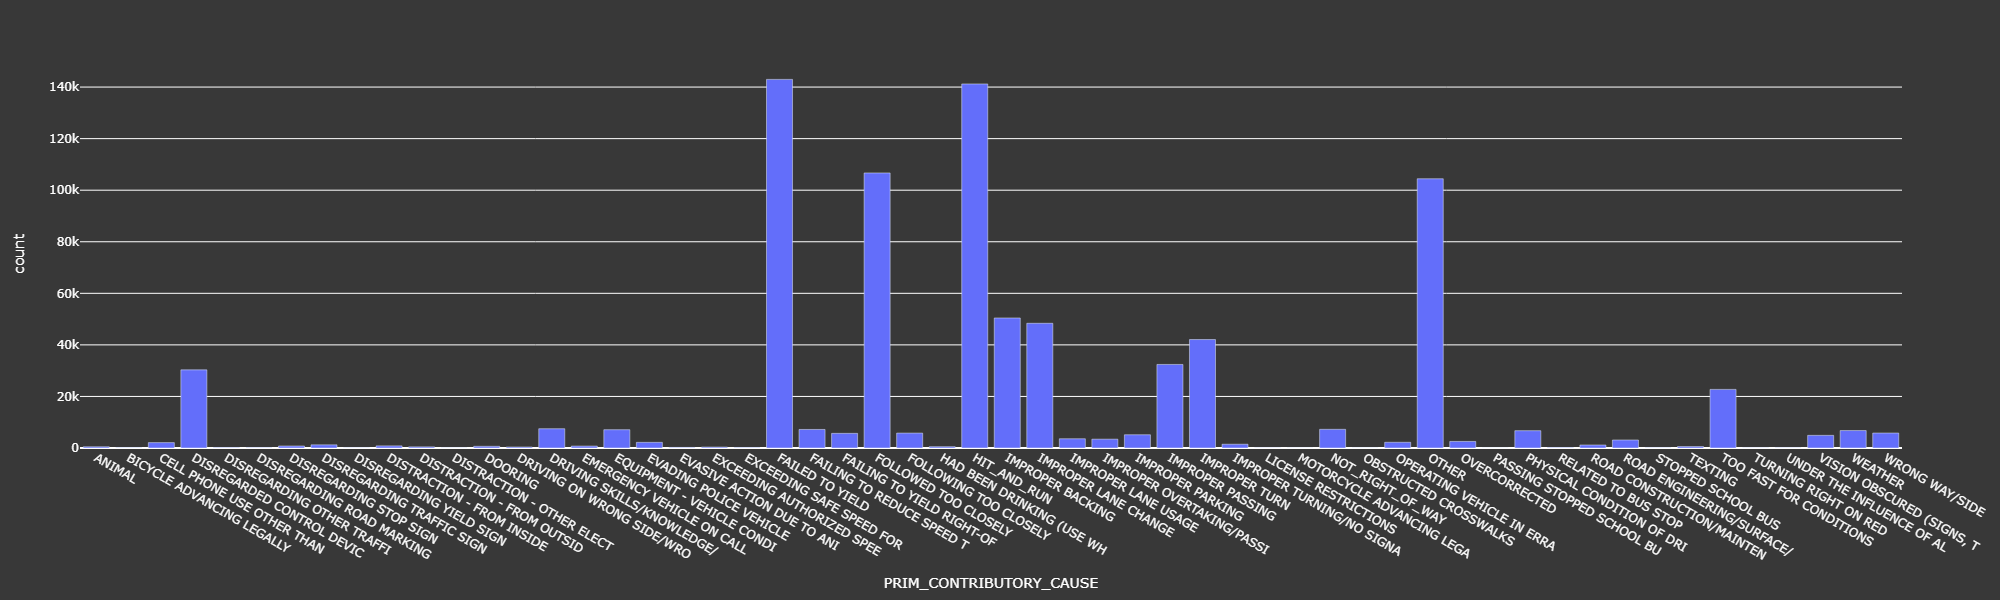

In [381]:
fig = px.bar(plot_data, x='PRIM_CONTRIBUTORY_CAUSE', y='count', barmode='group')
fig.update_layout(**layout_options)
img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
    <b> نستنتج أن أغلب الحوادث هي من الأسباب التالية: <br>
        1- FAILED TO YIELD : أي أن أكثر ما يسبب حوادث هو عدم التزام السائقين بقواعد إعطاء حق المرور.<br>
        2- HIT_AND_RUN: الهروب بعد الحادث.<br>
        3- FOLLOWED TOO CLOSELY: عدم ترك مسافة أمان كافية.<br>
        وبالتالي نستنتج أن أسباب الحوادث هي من قلة كفاءة السائقين في القيادة وليس نقص في قواعد السلامة.
     </b>

### [ii]

In [382]:
plot_data = df_crashes.groupby(['LIGHTING_CONDITION', 'DAMAGE'], as_index=False).count()[['LIGHTING_CONDITION', 'DAMAGE', 'CRASH_RECORD_ID']].rename({'CRASH_RECORD_ID': 'count'}, axis=1)

plot_data

,LIGHTING_CONDITION,DAMAGE,count
0,DARKNESS,$500 OR LESS,2368
1,DARKNESS,"$501 - $1,500",5750
2,DARKNESS,"OVER $1,500",14671
3,"DARKNESS, LIGHTED ROAD",$500 OR LESS,19963
4,"DARKNESS, LIGHTED ROAD","$501 - $1,500",45314
5,"DARKNESS, LIGHTED ROAD","OVER $1,500",142019
6,DAWN,$500 OR LESS,863
7,DAWN,"$501 - $1,500",1795
8,DAWN,"OVER $1,500",5603
9,DAYLIGHT,$500 OR LESS,68255


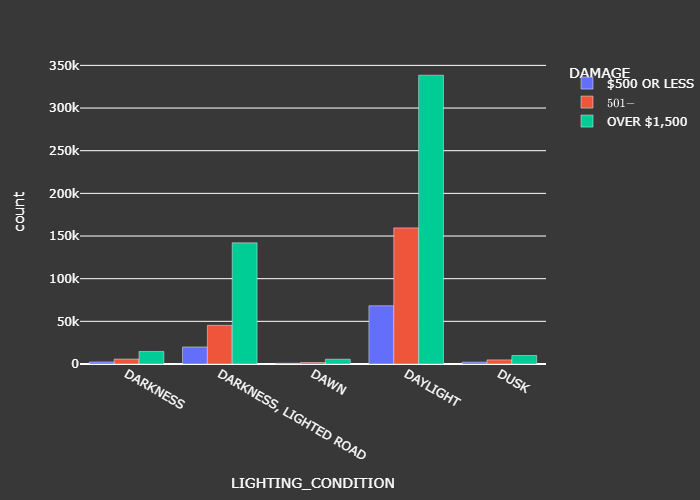

In [383]:
layout_options = {
    'paper_bgcolor':"#383838",
    'plot_bgcolor':'#383838',
    'title_font': dict(color='white'),
    'legend_font': dict(color='white'),
    'yaxis':dict(color="white"),
    'xaxis':dict(color="white") 
    }
fig = px.bar(plot_data, x='LIGHTING_CONDITION', y='count', color='DAMAGE', barmode='group')
fig.update_layout(**layout_options)
img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
     <b>نلاحظ كثرة الحوادث في النهار التي قد تكون بسبب الازدحام المروري الكبير.<br>
    وثاني أكثر وقت هو في ظروف الإضاءة العاتمة لكن يبدو أن السبب ليس من الإنارة بل قد يكون إما لأن وقت الحادث في الليل وبالتالي غالباً مايميل الناس ليكونوا أكثر تهوراً بالإضافة لقلة الشهود أو أن يكون مكان الحادث في نفق مثلاً فتكون السرعة كبيرة </b>

### [iii]

In [384]:
plot_data = df_crashes.groupby(['CRASH_TYPE', 'FIRST_CRASH_TYPE'], as_index=False).count()[['CRASH_TYPE', 'FIRST_CRASH_TYPE', 'CRASH_RECORD_ID']].rename({'CRASH_RECORD_ID': 'count'}, axis=1)
plot_data

,CRASH_TYPE,FIRST_CRASH_TYPE,count
0,INJURY AND / OR TOW DUE TO CRASH,ANGLE,37696
1,INJURY AND / OR TOW DUE TO CRASH,ANIMAL,75
2,INJURY AND / OR TOW DUE TO CRASH,FIXED OBJECT,20557
3,INJURY AND / OR TOW DUE TO CRASH,HEAD ON,3628
4,INJURY AND / OR TOW DUE TO CRASH,OTHER NONCOLLISION,908
5,INJURY AND / OR TOW DUE TO CRASH,OTHER OBJECT,2826
6,INJURY AND / OR TOW DUE TO CRASH,OVERTURNED,469
7,INJURY AND / OR TOW DUE TO CRASH,PARKED MOTOR VEHICLE,33642
8,INJURY AND / OR TOW DUE TO CRASH,PEDALCYCLIST,8665
9,INJURY AND / OR TOW DUE TO CRASH,PEDESTRIAN,16740


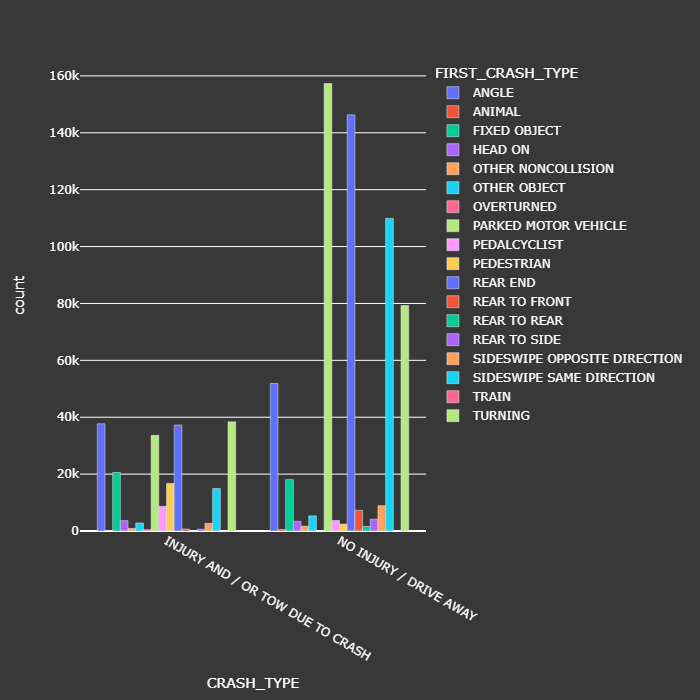

In [385]:
layout_options = {
    'paper_bgcolor':"#383838",
    'plot_bgcolor':'#383838',
    'title_font': dict(color='white'),
    'legend_font': dict(color='white'),
    'yaxis':dict(color="white"),
    'xaxis':dict(color="white"), 
    'height': 700 
    }

fig = px.bar(plot_data, x='CRASH_TYPE', y='count', color='FIRST_CRASH_TYPE', barmode='group')
fig.update_layout(**layout_options)
img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
    <b> أكثر أنواع الاصطدام الأولى المسببة للإصابة أو تؤدي لانجراف السيارة هي اصطدام السيارة أثناء انعطافها أو صدمها من زاويتها والذي غالباً ما يحدث في التقاطعات ونلاحظ أن هذان السببان ناتجان عن عدم اتباع قواعد حق المرور أو تجاوز الإشارة الحمراء.<br>
        ونلاحظ أن أكثر أنواع الاصطدام الأولى التي لا تسبب ضرراً هي الاصطدام بمركبة مركونة ويحدث هذا غالباً عندما يكون سائق آخر يقوم بركن سيارته فيصطدم بهذه المركبة الذي من الممكن أن يكون بسبب خطأ من السائق أو ضيق مساحة الركن والنوع الثاني هو الاصطدام  بالجزء الخلفي من السيارة والذي يحدث غالباً في الازدحام المروري لعدم ترك مسافة أمان.
    </b>   

### [iv]

In [386]:
plot_data = df_crashes.groupby(['TRAFFICWAY_TYPE', 'LIGHTING_CONDITION'], as_index=False).count()[['TRAFFICWAY_TYPE', 'LIGHTING_CONDITION', 'CRASH_RECORD_ID']].rename({'CRASH_RECORD_ID': 'count'}, axis=1)
plot_data

,TRAFFICWAY_TYPE,LIGHTING_CONDITION,count
0,ALLEY,DARKNESS,598
1,ALLEY,"DARKNESS, LIGHTED ROAD",2774
2,ALLEY,DAWN,142
3,ALLEY,DAYLIGHT,9814
4,ALLEY,DUSK,264
5,CENTER TURN LANE,DARKNESS,153
6,CENTER TURN LANE,"DARKNESS, LIGHTED ROAD",1889
7,CENTER TURN LANE,DAWN,74
8,CENTER TURN LANE,DAYLIGHT,3655
9,CENTER TURN LANE,DUSK,174


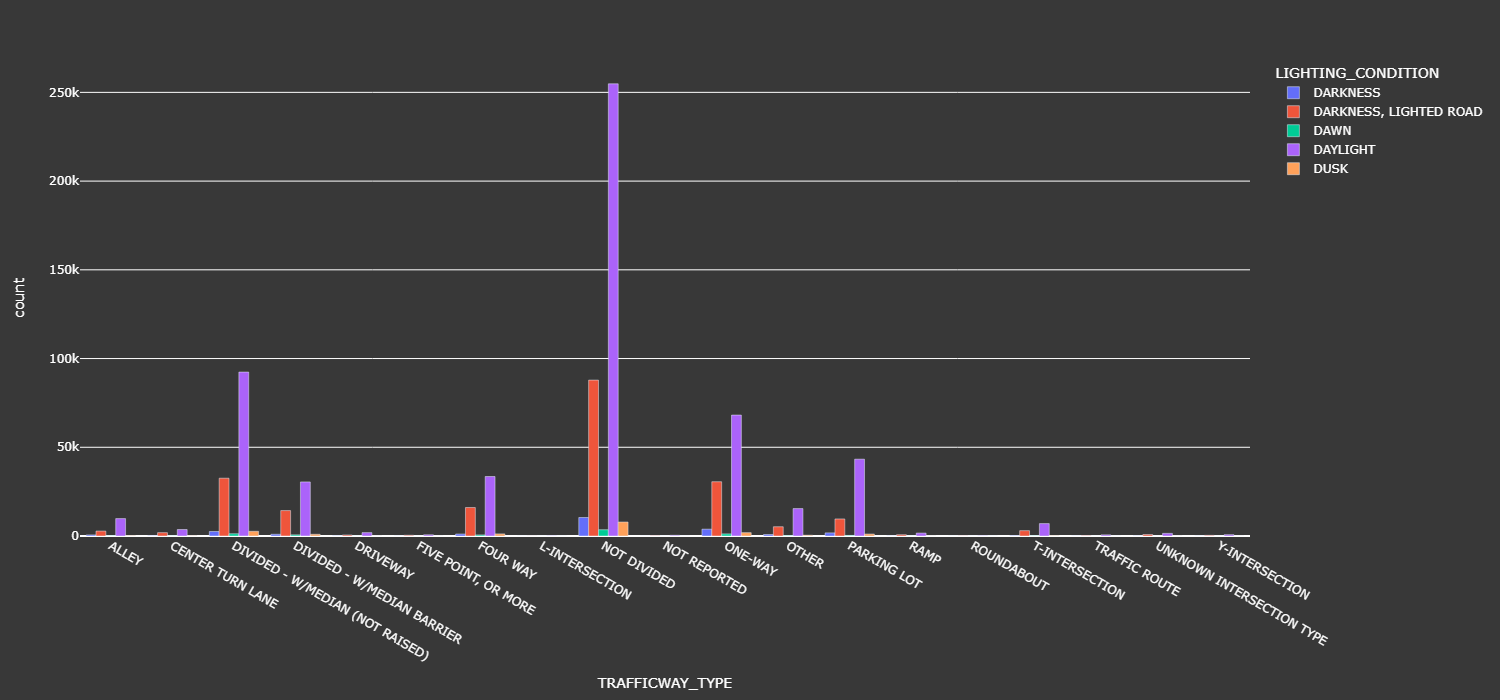

In [387]:
layout_options['width'] = 1500
fig = px.bar(plot_data, x='TRAFFICWAY_TYPE', y='count', color='LIGHTING_CONDITION', barmode='group')
fig.update_layout(**layout_options)
img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
    <b>  نلاحظ أن أكثر الحوادث تحدث في الليل في الطرق غير المقسمة وذلك لأن هذا النوع من الطرق غالباً ما يمكن للسيارات أن تقود بالاتجاهين فإن كانت سيارتان متعاكستان في الاتجاه على هذا الطريق في الليل ستكون الأضواء الأمامية لهما مضاءة مما يحجب الرؤية لدى السائقين أما في حالة النهار فيمكن أن يسبب ضيق الشارع وعدم وجود تنظيم كافي لهذا الطريق إلى كثرة الحوادث.<br>
        كما نلاحظ أنه في الشوارع  التي لديها منصف غير مرتفع غالباً ما تكون السرعة المسموحة فيها كبيرة مما يؤدي لتضييق مجال الرؤية للسائقين ويزداد الوضع سوءاً في الليل خصوصاً للذين يعانون من مشاكل في الرؤية.
    </b> 

## [b] Traffic Accidents History

### [i]

In [388]:
plot_data = df_crashes.groupby(['CRASH_HOUR', 'DAMAGE'], as_index=False).count()[['CRASH_HOUR', 'DAMAGE', 'CRASH_RECORD_ID']].rename({'CRASH_RECORD_ID': 'count'}, axis=1)
plot_data

,CRASH_HOUR,DAMAGE,count
0,0,$500 OR LESS,1490
1,0,"$501 - $1,500",3493
2,0,"OVER $1,500",12860
3,1,$500 OR LESS,1204
4,1,"$501 - $1,500",2829
5,1,"OVER $1,500",11294
6,2,$500 OR LESS,902
7,2,"$501 - $1,500",2261
8,2,"OVER $1,500",9980
9,3,$500 OR LESS,686


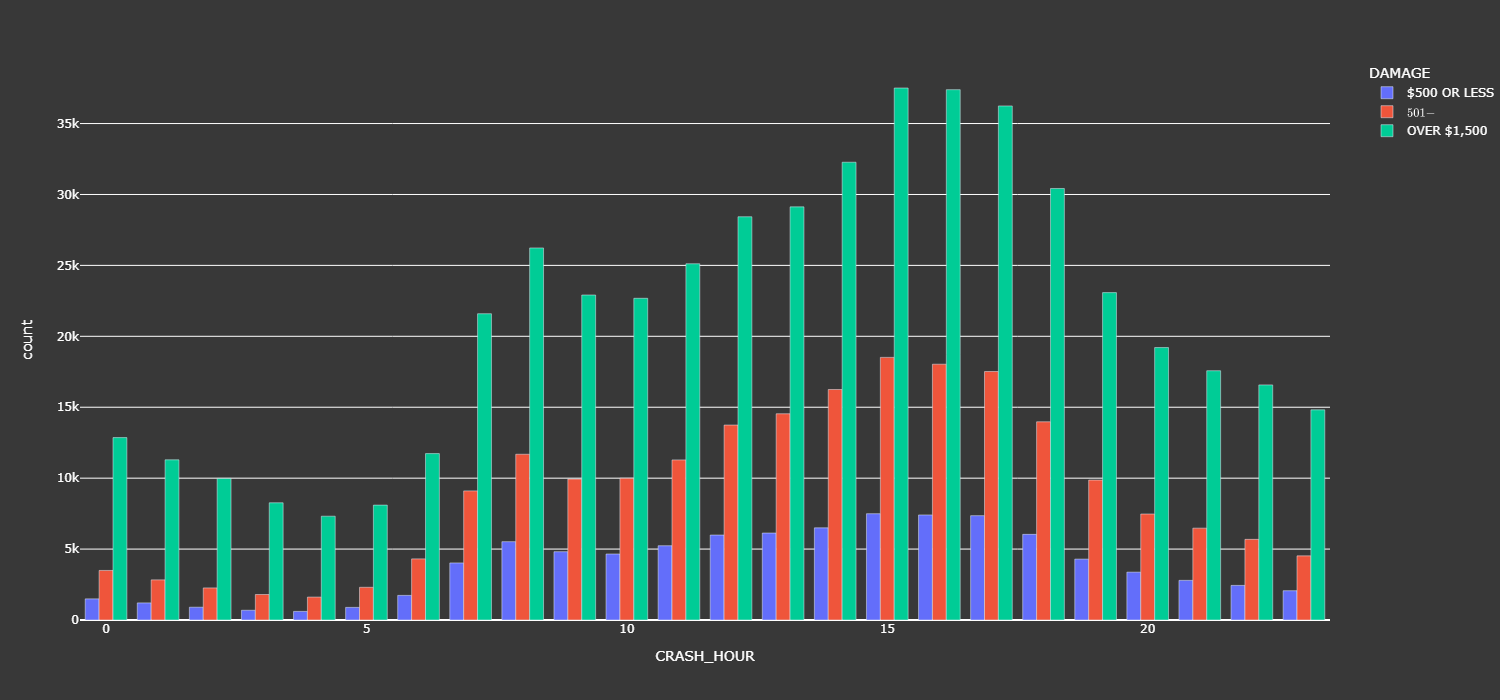

In [389]:
#  ماعم يطلعو الارقام كلهن كليبل
fig = px.bar(plot_data, x='CRASH_HOUR', y='count', color='DAMAGE', barmode='group')
fig.update_layout(**layout_options)
img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
    <b> نلاحظ أن ذروة الحوادث تكون في الساعة الثالثة والرابعة والخامسة ظهراً وغالباً يعود ذلك بسبب الازدحام الكثيف ومن تعب السائقين بعد وقت طويل في العمل كما يمكن لوهج الشمس أن يحجب الرؤية ونلاحظ أن أغلب الأضرار تكلف أكثر من 1500$ وذلك لغلاء إصلاح وتبديل قطع السيارات 

### [ii]

In [390]:
df = df_crashes.groupby(['CRASH_YEAR', 'CRASH_MONTH'], as_index=False).count()[['CRASH_YEAR','CRASH_MONTH', 'CRASH_RECORD_ID']].rename({'CRASH_RECORD_ID': 'count'}, axis=1)
df

,CRASH_YEAR,CRASH_MONTH,count
0,2013,3,1
1,2014,1,1
2,2014,8,1
3,2014,11,1
4,2015,1,2
5,2015,2,2
6,2015,4,3
7,2015,5,3
8,2015,6,3
9,2015,7,15


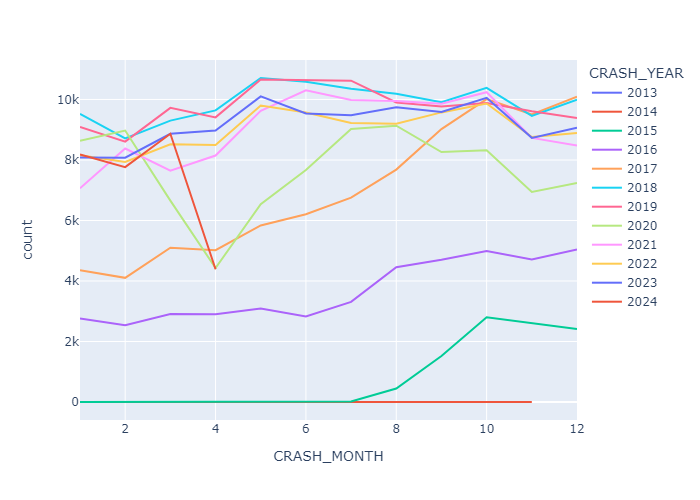

In [391]:
fig = px.line(df, x = "CRASH_MONTH", y = "count" , color = "CRASH_YEAR")
img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
    <b>  نلاحظ أنه في الشهر العاشر من كل سنة تكثر الحوادث بشكل ملحوظ ويعود ذلك غالباً بسبب العودة إلى المدارس وأيضاً بسبب احتفال الهالوين الذي يكون في آخر الشهر العاشر مما يؤدي لزيادة الازدحام.<br>
        نلاحظ أنه في سنة 2020 في الشهر الرابع انخفاضاً كبيراً في الحوادث وقد يعود ذلك بسبب جائحة كورونا.
    </b>

### [iii]

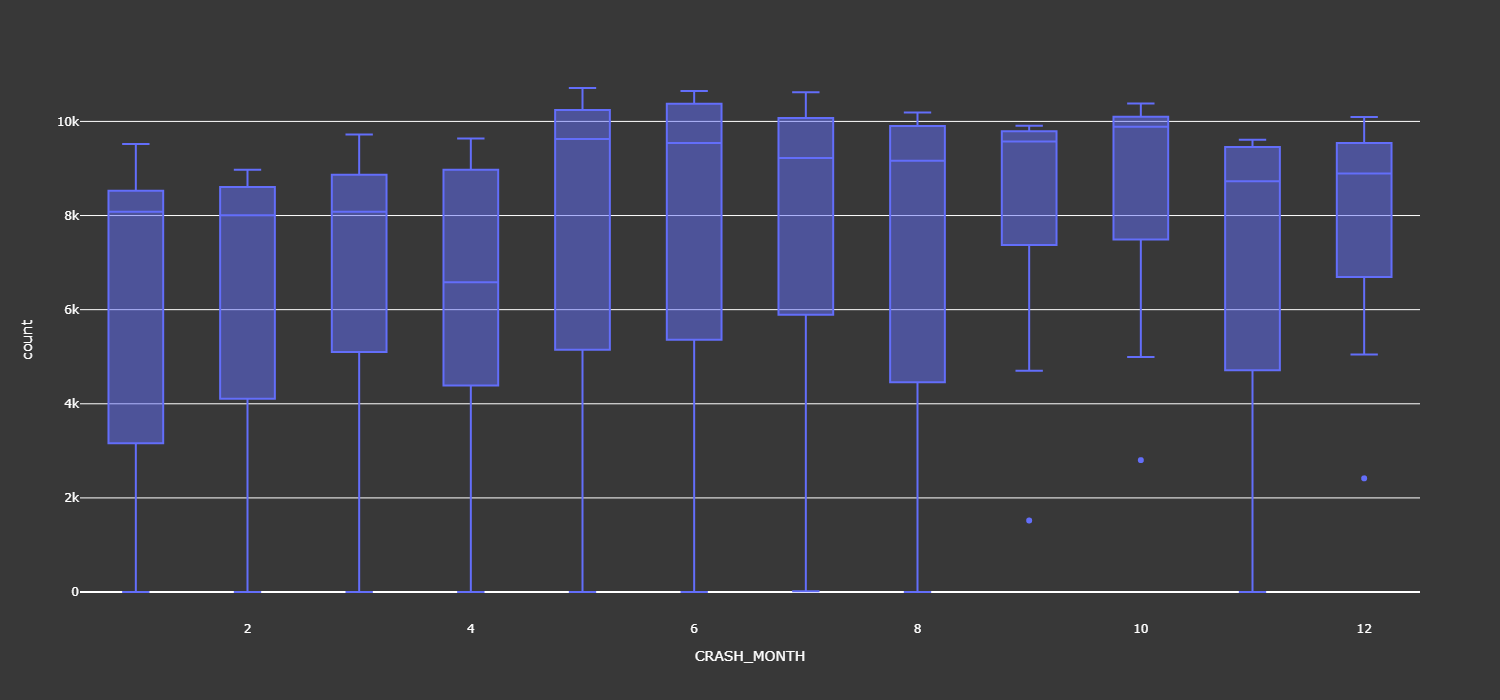

In [392]:
fig = px.box(df, x="CRASH_MONTH", y="count")

fig.update_layout(**layout_options)

img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
    <b> نلاحظ أنه في الشهر التاسع لا يختلف عدد الحوادث كثيراً بين السنوات فيمكن أن يدل ذلك على عدم اختلاف نمط القيادة ويمكن أن يكون بسبب عدم تغير الظروف (الطقس - ساعات النهار) على مدار السنين خلال هذا الشهر.<br>
        بينما نلاحظ أنه في الشهر 1و 8و 5 اختلاف كبير في عدد الحوادث على مدار السنين ويمكن أن يكون ذلك بسبب اختلاف الظروف.<br>
        نلاحظ أن متوسط عدد الحوادث في كل شهر على مدار السنة يكون تقريباً 9000 حادث لكن نلاحظ في الشهر الثاني انخفاض هذه النسبة وزيادتها في شهر 10.
    </b>

### [iv]

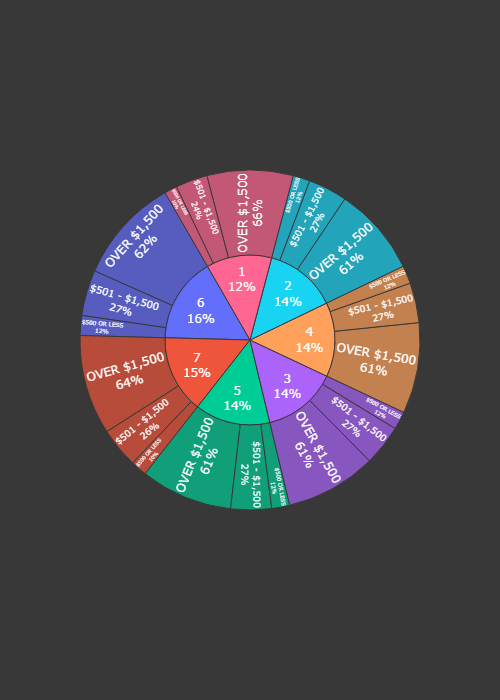

In [393]:
layout_options['width'] = 500
fig = px.sunburst(df_crashes, path=['CRASH_DAY_OF_WEEK', 'DAMAGE'])

fig.update_traces(textinfo='label+percent parent', textfont=dict(color='white'), rotation=120)

fig.update_layout(**layout_options)

img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
    <b> نلاحظ زيادة طفيفة في عدد الحوادث في يومي السبت والأحد ويعود ذلك لزيادة استهلاك الكحول في أيام العطل بينما في يوم الاثنين يحوي النسبة الأقل ويمكن أن يكون ذلك بسبب الراحة بعد أيام العطل فتكون أكثر تركيزاً، لكن بشكل عام لا نلاحظ هذا الفرق الكبير وأيضاً فئة الضرر هي تقريباُ نفسها في كل الأيام.</b>

## [c] Spatial Analysis

### [i]

In [394]:
plot_data = df_crashes.groupby('Geohash', as_index=False).count()[['Geohash', 'CRASH_RECORD_ID']].rename({'CRASH_RECORD_ID': 'count'}, axis=1)
plot_data.sort_values(by='count')

,Geohash,count
822,SLGrf,1
688,SLGpU,1
579,SLGV8,1
578,SLGV6,1
700,SLGph,1
228,SLFaC,1
231,SLFaK,1
568,SLGUl,1
566,SLG@a,1
551,SLG9Z,1


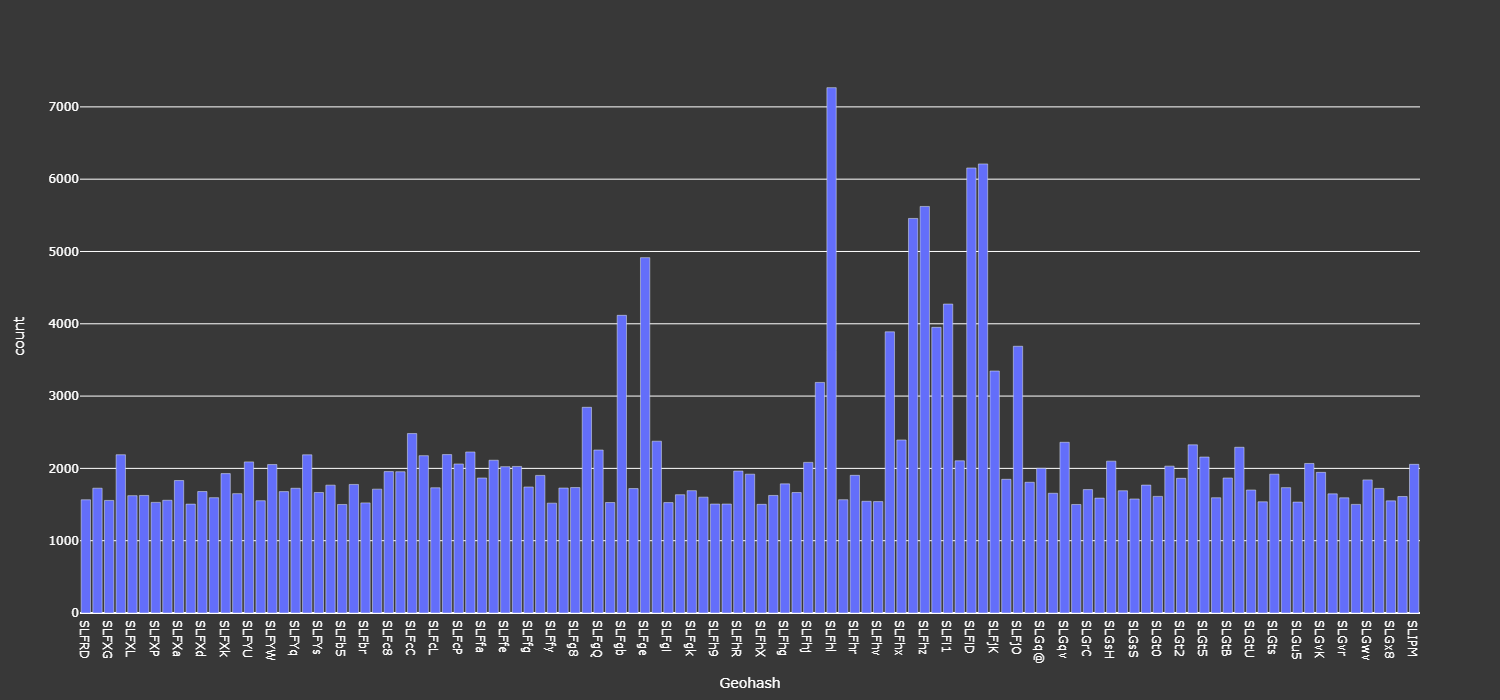

In [395]:
layout_options['width'] = 1500
samples = plot_data[plot_data['count'] > 1500]
fig = px.bar(samples, x='Geohash', y='count', barmode='group')

fig.update_layout(**layout_options)

img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
    <b> نلاحظ أنه في القطاعات SLFhl, SLFiE, SLFiD هي أكثر القطاعات التي تكثر فيها الحوادث وبالتالي يجب تحسين إجراءات الأمان والسلامة في هذه القطاعات.</b> 

### [ii]

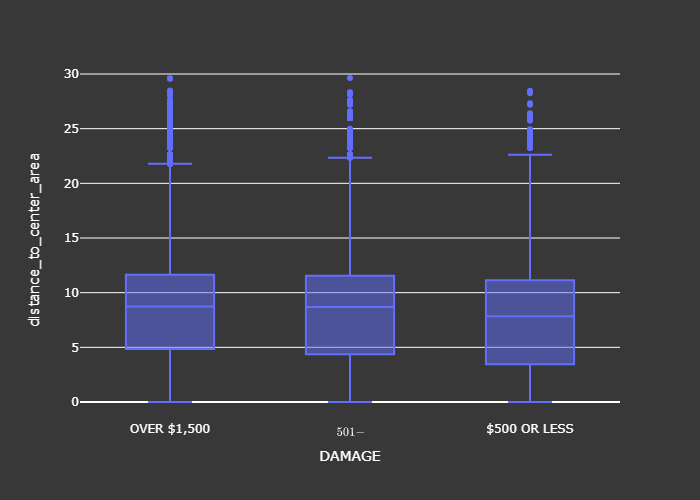

In [396]:
layout_options = {
    'paper_bgcolor':"#383838",
    'plot_bgcolor':'#383838',
    'title_font': dict(color='white'),
    'legend_font': dict(color='white'),
    'yaxis':dict(color="white"),
    'xaxis':dict(color="white") 
    }
fig = px.box(df_crashes[df_crashes['distance_to_center_area'] < 1000], x="DAMAGE", y="distance_to_center_area")

fig.update_layout(**layout_options)

img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
    <b>  نلاحظ أن المسافة عن المنطقة التجارية لا تؤثر كثيراً على فئة الضرر.</b>

### [iii]

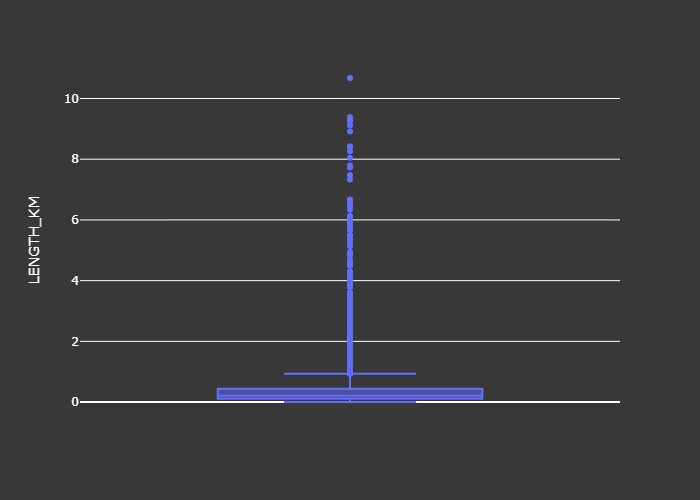

In [397]:
fig = px.box(df_streets, y="LENGTH_KM")

fig.update_layout(**layout_options)

img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
    <b>  نلاحظ أن أغلب أطوال الشوارع هي أقل من 1 كم </b>

In [398]:
l = list(df_crashes['STREET_NO'].unique())

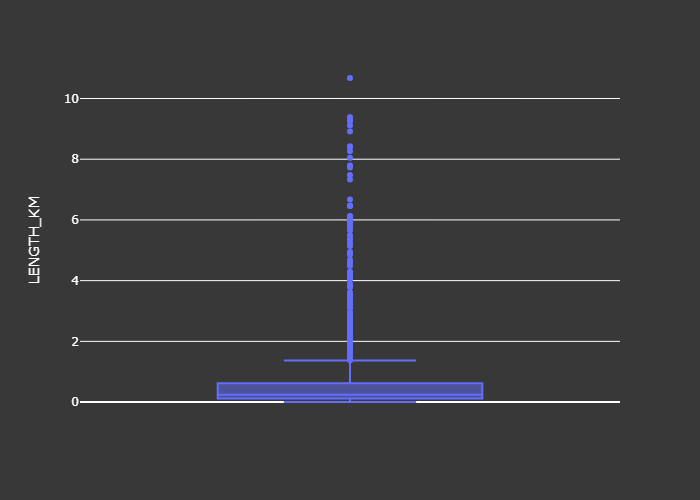

In [399]:
fig = px.box(df_streets[df_streets['STREET_NO'].isin(l)], y="LENGTH_KM")

fig.update_layout(**layout_options)

img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

### [iv]

In [400]:
plot_data = df_crashes.groupby('Street_Length_Category', as_index=False).count()[['Street_Length_Category', 'CRASH_RECORD_ID']].rename({'CRASH_RECORD_ID': 'count'}, axis=1)
plot_data

,Street_Length_Category,count
0,long,112945
1,medium,393964
2,short,314642


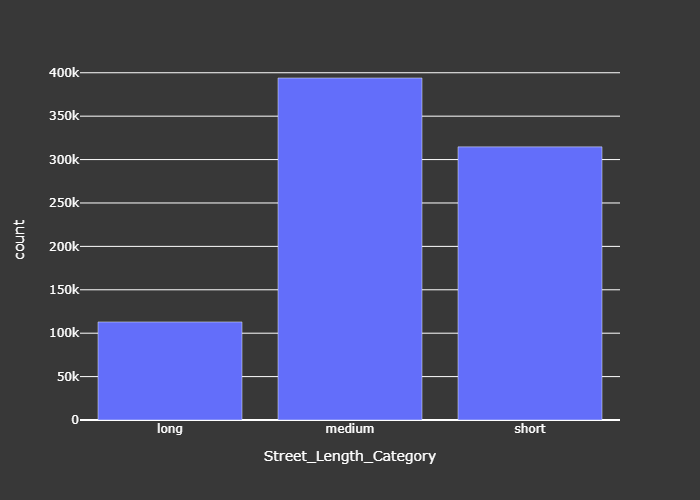

In [401]:
fig = px.bar(plot_data, x='Street_Length_Category', y='count', barmode='group')

fig.update_layout(**layout_options)

img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
    <b> نلاحظ أن أغلب الحوادث تحدث في الشوارع التي يتراوح طولها بين 0.2 - 2كم ويمكن أن يكون السبب هو الكثافة السكانية وأيضاً بسبب كثرة التقاطعات والانعطافات في هذه الشوارع مثل أماكن المدارس. </b>

### [v]

In [402]:
plot_data = df_crashes.groupby('disatence_category', as_index=False).count()[['disatence_category', 'CRASH_RECORD_ID']].rename({'CRASH_RECORD_ID': 'count'}, axis=1)
plot_data

,disatence_category,count
0,Far,54159
1,Medium,546243
2,Near,221149


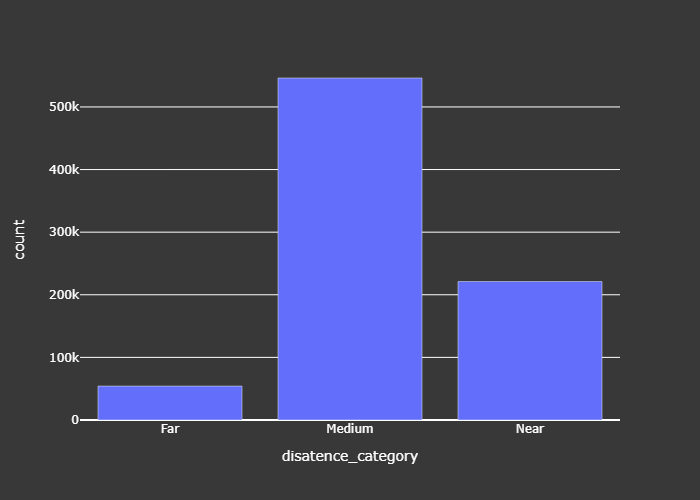

In [403]:
fig = px.bar(plot_data, x='disatence_category', y='count', barmode='group')

fig.update_layout(**layout_options)

img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
    <b>  نلاحظ أن أكثر الحوادث تحدث على بعد قريب ومتوسط من المنطقة التجارية ويكون السبب غالباً أن شبكة الطرق فيها تكون معقدة أكثر ويكون الازدحام أكبر.</b>

### [vi]

In [404]:
# contingency table
table = pd.crosstab(df_crashes['disatence_category'], df_crashes['Street_Length_Category'])
table.head()

Street_Length_Category,long,medium,short
disatence_category,,,
Far,6464,29980,17715
Medium,83997,257438,204808
Near,22484,106546,92119


In [405]:
stat, p, dof, expected = chi2_contingency(table)
print('stat=%.3f, p=%.3f, dof=%d' % (stat, p, dof))
if p > 0.05:
    print('Probably independent')
else:
    print('Probably dependent')

stat=5130.183, p=0.000, dof=4
Probably dependent


In [406]:
# cramer's V
k = min(table.shape[0], table.shape[1])
math.sqrt(stat / (df_crashes.shape[0] * (k - 1)))

0.05587713932376048

<div style="direction: rtl; text-align: right;">
    <b> نجد أن العلاقة ضعيفة جداً بين المتحولين وذلك لوجود شوارع مختلفة الطول في جميع المناطق. </b>

## [d] Passengers Cases Analysis

### [i]

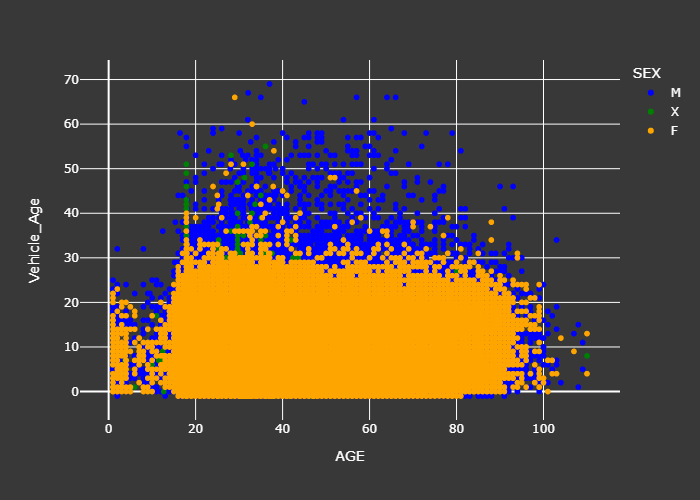

In [407]:
df_drivers = df_people[df_people['PERSON_TYPE']== 'DRIVER'][['CRASH_RECORD_ID','AGE','SEX','VEHICLE_ID']]
df_drivers_cars = df_drivers.merge(df_vehicles[['CRASH_RECORD_ID', 'Vehicle_Age','VEHICLE_ID']], 
                          on=['CRASH_RECORD_ID','VEHICLE_ID'], 
                          how='left')

custom_color_sequence = [ 'blue', 'green', 'orange', 'purple']

fig = px.scatter(df_drivers_cars, x="AGE", y="Vehicle_Age", color='SEX', color_discrete_sequence=custom_color_sequence)

fig.update_layout(**layout_options)

img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
    <b> نلاحظ أن الإناث يقومون بحوادث بشكل أقرب لسنة صنع السيارة من الذكور ولا نلاحظ أي اختلاف بعمر السائقين من ناحية جنسهم.</b>

### [ii]

In [408]:
def age_cat(age):
    if age < 13:
        return 'child'
    elif age < 19:
        return 'teen'
    elif age < 50:
        return 'adult'
    else:
        return 'elderly'

In [409]:
df_drivers['AGE_cat'] =  df_drivers['AGE'].apply(age_cat)
df_drivers_age_cat = df_drivers.merge(df_vehicles[['CRASH_RECORD_ID', 'Vehicle_Age_Category','VEHICLE_ID']], 
                          on=['CRASH_RECORD_ID','VEHICLE_ID'], 
                          how='left')

In [410]:
# contingency table
table = pd.crosstab(df_drivers_age_cat['AGE_cat'], df_drivers_age_cat['Vehicle_Age_Category'])
table.head()

stat, p, dof, expected = chi2_contingency(table)
print('stat=%.3f, p=%.3f, dof=%d' % (stat, p, dof))
if p > 0.05:
    print('Probably independent')
else:
    print('Probably dependent')

stat=10259.751, p=0.000, dof=6
Probably dependent


In [411]:
# cramer's V
k = min(table.shape[0], table.shape[1])
math.sqrt(stat / (df_drivers_age_cat.shape[0] * (k - 1)))

0.060474796499203724

<div style="direction: rtl; text-align: right;">
    <b>  الارتباط ضعيف لكن من الممكن أن نفسر الارتباط أن الشباب المراهقين غالباً ما يمتلكون سيارات قديمة غالباً لأنهم قد ورثوها عن أهاليهم أو لضعف قدرتهم المادية كما يمكن أن يفضل كبار السن السيارات الحديثة لأنها أكثر أماناً. </b>

### [iii]

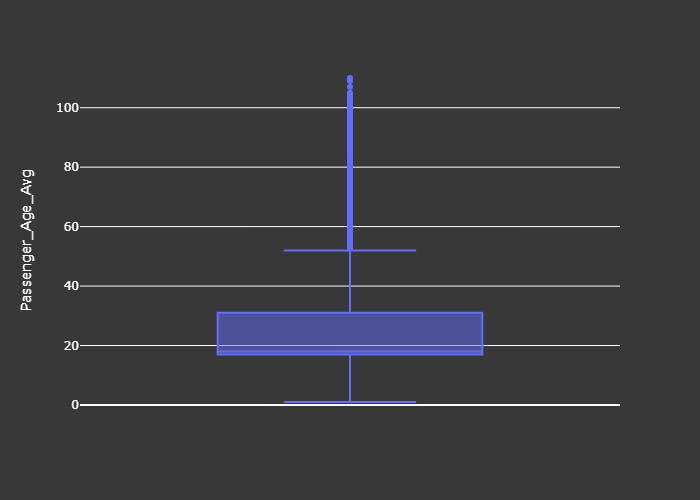

In [412]:
fig = px.box(df_crashes, y="Passenger_Age_Avg")

fig.update_layout(**layout_options)

img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
    <b> نلاحظ أن متوسط أعمار الركاب في الحوادث يكون بين 18 - 31 ويمكن أن يعود ذلك لأن هذه الفئة العمرية هي أكثر تهوراً وبالتالي تؤثر على تركيز السائقين وخاصة إذا كان السائق من نفس هذه الفئة العمرية.</b>

### [iv]

In [413]:
# df_passenger_sum = df_vehicles.groupby(['CRASH_RECORD_ID', 'VEHICLE_ID'], as_index=False)['Passenger_Count'].sum().round()

# df_crashes = df_crashes.merge(df_passenger_sum[['CRASH_RECORD_ID', 'Passenger_Count']], 
#                           on=['CRASH_RECORD_ID'], 
#                           how='left')

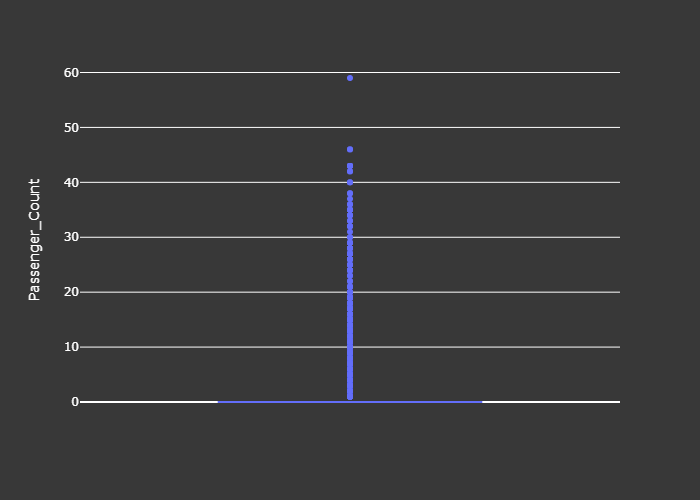

In [414]:
fig = px.box(df_vehicles, y="Passenger_Count")

fig.update_layout(**layout_options)

img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
<b>    نلاحظ أن أغلب الحوادث يكون فيها عدد الركاب هو صفر باستثناء بعض الحالات القليلة والتي يتراوح عدد الركاب من 1 إلى 60 ويمكن أن يكون السبب في ذلك هو أنه عندما يكون السائق لوحده يكون أكثر عرضة للملل ويصيبه قلة تركيز أو قد يستعمل الهاتف المحمول مما يزيد تشتته كما أنه قد يشعر بقلة أمان وتوتر من وجوده بمفرده</b>

### [v]

In [415]:
plot_data = df_vehicles.groupby('Vehicle_Age_Category', as_index=False).count()[['Vehicle_Age_Category', 'CRASH_RECORD_ID']].rename({'CRASH_RECORD_ID': 'count'}, axis=1)
plot_data

,Vehicle_Age_Category,count
0,New,583375
1,Old,844794
2,Obsolete,244964


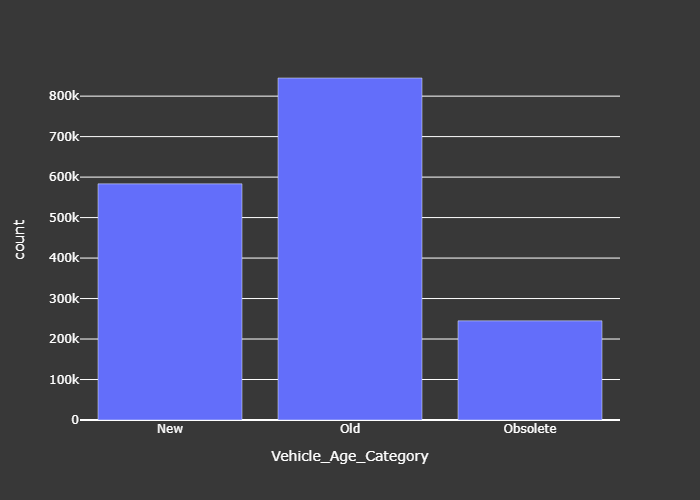

In [416]:
fig = px.bar(plot_data, x='Vehicle_Age_Category', y='count', barmode='group')

fig.update_layout(**layout_options)
img_bytes = pio.to_image(fig, format="png")

display(Image(img_bytes))

<div style="direction: rtl; text-align: right;">
    <b> نلاحظ أن معظم الحوادث هي من السيارات التي عمرها بين 5 -  15 سنة وغالباً لأنها تملك أنظمة سلامة أقل تطوراً وغالباً new  أكثر من obselete لأن الأخيرة قليلة التواجد. </b>

## [e] Outlier Detection

### [i]

In [417]:
from pyod.models.iforest import IForest

multvariate_df = pd.get_dummies(df_crashes[['LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'CRASH_TYPE', 'DAMAGE', 'CRASH_MONTH', 'CRASH_HOUR', 'STREET_NO', 'BEAT_NUM', 'POSTED_SPEED_LIMIT', 'CRASH_YEAR', 'Passenger_Avg', 'V_Nominal_Category', 'Street_Length_Category', 'disatence_category']], dtype=int)
model = IForest(n_estimators=100, max_samples='auto')
pred_y = model.fit_predict(multvariate_df.values)
pred_y

array([0, 0, 0, ..., 0, 0, 0])

In [418]:
indices = np.where(pred_y == 1)[0]

In [419]:
indices.shape

(82155,)

In [420]:
outliers = df_crashes.iloc[indices]

In [421]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [422]:
outliers.head()

,index,CRASH_RECORD_ID,CRASH_DATE,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,CRASH_TYPE,DAMAGE,PRIM_CONTRIBUTORY_CAUSE,CRASH_DAY_OF_WEEK,CRASH_MONTH,CRASH_HOUR,LATITUDE,LONGITUDE,STREET_NO,BEAT_NUM,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,ALIGNMENT,ROAD_DEFECT,MOST_SEVERE_INJURY,INJURIES_TOTAL,most_comon_lighting,CRASH_YEAR,Passenger_Avg,Passenger_Age_Avg,Vehicles_NO,Vehicle_Age_Category,V_Nominal_Category,Geohash,Street_Length_Category,distance_to_center_area,disatence_category,is_inside_cbd,DISTRICT,Sex_Category
5,5,14386daec6219c6032b71612b28f0e4cd38e2898f39aae84deeb4efaf165253548cb27cb90088b2d4f9d3e484aa1e7f5076969da4d3b8137a43a3dc94536ac19,2023-08-13 00:11:00,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,NO INJURY / DRIVE AWAY,"OVER $1,500",IMPROPER TURN,1,8,0,41.772615,-87.630100,1769,232.0,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,STRAIGHT AND LEVEL,NO DEFECTS,NO INDICATION OF INJURY,0.0,"DARKNESS, LIGHTED ROAD",2023,0.0,NaN,2,{New},new,SLGsj,long,9.050174,Medium,False,2,mixed
7,7,36360857c079418cba1b1d70cf653595bbfb4566de8fcb4fff284d6ec2ef9eee82b949759fd83f4ba3df857fed548f769780b036df6ada65aa935b6c669cec53,2022-01-01 16:32:00,"DARKNESS, LIGHTED ROAD",ANGLE,PARKING LOT,NO INJURY / DRIVE AWAY,"$501 - $1,500",FAILED TO YIELD,7,1,16,41.890219,-87.619459,942,1654.0,10,NO CONTROLS,NO CONTROLS,SNOW,STRAIGHT AND LEVEL,NO DEFECTS,NO INDICATION OF INJURY,0.0,DAYLIGHT,2022,0.0,NaN,2,"{Old, New}",mixed,SLFi1,short,0.000000,Near,True,16,F
10,10,fda2491d33ac819033f4aaa7ed901120f2f6785b7e5bbbbf99eb6d56847d5de207d7697261a182f12a2a47fbeb3fbaa5c3c767d3ac099675e65e09f345b7e7f4,2023-07-29 00:50:00,DARKNESS,SIDESWIPE OPPOSITE DIRECTION,NOT DIVIDED,NO INJURY / DRIVE AWAY,"OVER $1,500",OTHER,7,7,0,41.899225,-87.696642,1171,1211.0,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,STRAIGHT AND LEVEL,UNKNOWN,NO INDICATION OF INJURY,0.0,"DARKNESS, LIGHTED ROAD",2023,0.0,NaN,2,{New},new,SLFhB,medium,4.709722,Near,False,12,mixed
16,16,c1d7fc960fb09d4a725da4a931e551a71df5e352cb491d0d8254570046cb7f37f4b72c97920031f279488199fdffd836165c23fc810097269c0001551b26f746,2023-09-13 16:40:00,DAYLIGHT,REAR END,DIVIDED - W/MEDIAN BARRIER,NO INJURY / DRIVE AWAY,$500 OR LESS,EQUIPMENT - VEHICLE CONDITION,4,9,16,41.895785,-87.677931,252,322.0,40,NO CONTROLS,NO CONTROLS,CLEAR,STRAIGHT AND LEVEL,UNKNOWN,NO INDICATION OF INJURY,0.0,DAYLIGHT,2023,0.0,NaN,2,{New},new,SLFh9,medium,2.897181,Near,False,3,mixed
26,26,888daacc1e40bb00d59ceb2a966047f99d067459fe6c908ca9491b41ad630358262c9db07be0284610abc9a5a53e8dbb394dbae1560af76f78e9ddb038190c45,2023-09-06 00:59:00,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,NOT DIVIDED,INJURY AND / OR TOW DUE TO CRASH,"$501 - $1,500",NOT_RIGHT_OF_WAY,4,9,0,41.910530,-87.667051,307,1433.0,30,NO CONTROLS,NO CONTROLS,RAIN,STRAIGHT AND LEVEL,UNKNOWN,NONINCAPACITATING INJURY,2.0,"DARKNESS, LIGHTED ROAD",2023,1.0,26.0,1,{New},new,SLFhY,short,2.285712,Near,False,14,M
